# **Dynamic**

In [662]:
# -------- Load libraries --------
# Data manipulation libraries
import pandas as pd
import numpy as np
import yfinance as yf
from collections import defaultdict

# Visualization libraries
import matplotlib.pyplot as plt
from matplotlib.legend import Legend
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
from adjustText import adjust_text

# ML libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Portfolio optimisation libraries
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

import os
import warnings

# Set working directory
os.chdir("/Users/stephanieyao/Desktop/ADS2001/Stock-portfolio-opt")


In [663]:
# FILE PATHS
PRICE_PATH = "~/Desktop/ADS2001/Stock-portfolio-opt/MyDataset/price_cleaned.csv"
RETURNS_PATH = "~/Desktop/ADS2001/Stock-portfolio-opt/MyDataset/returns_cleaned.csv"
SECTOR_MAP_PATH = "~/Desktop/ADS2001/Stock-portfolio-opt/MyDataset/sector_map.csv"

# DATA AND WALK-FORWARD BACKTEST PERIOD
DATA_START = "2010-01-01"
DATA_END = "2019-07-31"

# Initial history used before the first model-based portfolio decision
INITIAL_TRAIN_END = "2014-12-31"

# Out-of-sample walk-forward backtest period
BACKTEST_START = "2015-01-01"
BACKTEST_END = "2019-07-31"

### **1. Data Loading & Preparation**

In [664]:
# SET PARAMETERS
# Lookback window
LOOKBACK_DAYS = 252
SHORT_LOOKBACK_DAYS = 63
TRADING_DAYS = 252
MIN_HOLDING_DAYS = 40   

# Rebalancing
REBALANCE_FREQ = "Q"

# Stock selection
K_STOCKS = 12
CANDIDATE_POOL_SIZE = 75       # top N stocks kept before stock-level ML ranking
MIN_VALID_RATIO = 0.80         # at least 80% valid data in lookback window
MIN_AVG_PRICE = 1.0

# Diversification constraints
CORR_THRESHOLD = 0.65          # correlation for stock selection
SECTOR_CAP_RATIO = 0.30   

# Portfolio optimisation
MAX_WEIGHT = 0.2              # maximum weight for any single stock
RF_DAILY = 0.0                 # risk-free rate (daily)

# Transaction cost
TRANSACTION_COST_RATE = 0.001

# Regime model
MIN_TRAINING_QUARTERS = 12
RANDOM_STATE = 42

# Stock-level outperform model
MIN_STOCK_MODEL_TRAINING_ROWS = 300


# ============================================================
# STOCK-LEVEL OUTPERFORM MODEL CANDIDATES
# ============================================================

STOCK_MODEL_CANDIDATES = {
    "logistic_regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000,
            class_weight="balanced"
        )
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),

    "gradient_boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=2,
        random_state=RANDOM_STATE
    ),

    "xgboost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=2,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )
}

# Define candidate models for regime prediction
REGIME_MODEL_CANDIDATES = {
    "logistic_regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000
        )
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=3,
        random_state=RANDOM_STATE
    ),

    "gradient_boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=2,
        random_state=RANDOM_STATE
    ),
    
    "xgboost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=2,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )
}


In [665]:
# LOAD CLEANED PRICE, RETURN AND SECTOR DATA

# Load cleaned adjusted price data -------------------------
df_price_full = pd.read_csv(PRICE_PATH, index_col=0, parse_dates=True)

# Load cleaned daily return data
df_return_full = pd.read_csv(RETURNS_PATH, index_col=0, parse_dates=True)

# Load stock-sector mapping ----------------------------------
sector_map = pd.read_csv(SECTOR_MAP_PATH, index_col=0)


# Sort date index
df_price_full = df_price_full.sort_index()
df_return_full = df_return_full.sort_index()

print("Cleaned price data loaded.")
print(f"Price data shape : {df_price_full.shape}")
print(f"Price date range : {df_price_full.index.min().date()} to {df_price_full.index.max().date()}")

print("\nCleaned return data loaded.")
print(f"Return data shape: {df_return_full.shape}")
print(f"Return date range: {df_return_full.index.min().date()} to {df_return_full.index.max().date()}")

print("\nSector map loaded.")
print(f"Sector map shape : {sector_map.shape}")
print("\nSector map sample:")
display(sector_map.sample(5, random_state=RANDOM_STATE))

Cleaned price data loaded.
Price data shape : (2499, 1199)
Price date range : 2010-01-01 to 2019-07-31

Cleaned return data loaded.
Return data shape: (2499, 1199)
Return date range: 2010-01-01 to 2019-07-31

Sector map loaded.
Sector map shape : (1199, 5)

Sector map sample:


,Ticker,Company,Sector,Industry,Ticker_Merge
Stock_Code,,,,,
WYND US Equity,WYND,Unknown,Unclassified,Unclassified,WYND
NKE US Equity,NKE,"NIKE, Inc.",Consumer Cyclical,Footwear & Accessories,NKE
222435Q US Equity,222435Q,Unknown,Unclassified,Unclassified,222435Q
COF US Equity,COF,Capital One Financial Corporation,Financial Services,Credit Services,COF
1513Q US Equity,1513Q,Unknown,Unclassified,Unclassified,1513Q


In [666]:
# ============================================================
# STANDARDISE SECTOR MAP
# ============================================================

sector_map = sector_map.reset_index()

sector_map = sector_map.rename(columns={
    "Stock_Code": "Stock"
})

sector_map = sector_map[[
    "Stock",
    "Ticker",
    "Ticker_Merge",
    "Company",
    "Sector",
    "Industry"
]].copy()

sector_map = sector_map.dropna(subset=["Stock", "Sector"])
sector_map = sector_map.drop_duplicates(subset=["Stock"])

print("\nSector map standardised.")
print(f"Number of stocks with sector info: {sector_map['Stock'].nunique()}")
print(f"Number of sectors: {sector_map['Sector'].nunique()}")
display(sector_map.head())


Sector map standardised.
Number of stocks with sector info: 1199
Number of sectors: 12


,Stock,Ticker,Ticker_Merge,Company,Sector,Industry
0,0111145D US Equity,0111145D,0111145D,Unknown,Unclassified,Unclassified
1,0202445Q US Equity,0202445Q,0202445Q,Unknown,Unclassified,Unclassified
2,0203524D US Equity,0203524D,0203524D,Unknown,Unclassified,Unclassified
3,0226226D US Equity,0226226D,0226226D,Unknown,Unclassified,Unclassified
4,0376152D US Equity,0376152D,0376152D,Unknown,Unclassified,Unclassified


Exclude Unclassified for main strategy

In [667]:
# ============================================================
# HANDLE UNCLASSIFIED SECTOR
# ============================================================

EXCLUDE_UNCLASSIFIED = True

sector_map_full = sector_map.copy()

if EXCLUDE_UNCLASSIFIED:
    sector_map = sector_map[sector_map["Sector"] != "Unclassified"].copy()
    print("Unclassified stocks excluded from the main strategy.")
else:
    print("Unclassified stocks retained in the main strategy.")

print(f"Number of stocks after sector filter: {sector_map['Stock'].nunique()}")

display(
    sector_map["Sector"]
    .value_counts()
    .rename_axis("Sector")
    .reset_index(name="Number_of_Stocks")
)

Unclassified stocks excluded from the main strategy.
Number of stocks after sector filter: 544


,Sector,Number_of_Stocks
0,Industrials,83
1,Consumer Cyclical,82
2,Financial Services,76
3,Technology,68
4,Healthcare,59
5,Consumer Defensive,36
6,Real Estate,32
7,Utilities,30
8,Energy,30
9,Basic Materials,28


In [668]:
# ============================================================
# ALIGN PRICE, RETURN AND SECTOR DATA AFTER SECTOR FILTER
# ============================================================

common_stocks = sorted(
    list(
        set(df_price_full.columns)
        & set(df_return_full.columns)
        & set(sector_map["Stock"])
    )
)

df_price_full = df_price_full[common_stocks].copy()
df_return_full = df_return_full[common_stocks].copy()

sector_map = (
    sector_map[sector_map["Stock"].isin(common_stocks)]
    .copy()
    .sort_values("Stock")
    .reset_index(drop=True)
)

print("Data realigned after sector filtering.")
print(f"Common stocks kept         : {len(common_stocks)}")
print(f"Aligned price data shape   : {df_price_full.shape}")
print(f"Aligned return data shape  : {df_return_full.shape}")
print(f"Aligned sector map shape   : {sector_map.shape}")

Data realigned after sector filtering.
Common stocks kept         : 544
Aligned price data shape   : (2499, 544)
Aligned return data shape  : (2499, 544)
Aligned sector map shape   : (544, 6)


### **2. Build Quarterly Rebalance Schedule**

#### 2.1 Build quarterly rebalance dates

In [669]:
def get_quarterly_rebalance_dates(trading_dates, start_date, end_date):
    """
    Generate quarterly rebalance dates based on actual trading dates.

    The function creates calendar quarter-start dates, then maps each
    quarter-start date to the first available trading day on or after it.

    Parameters
    ----------
    trading_dates : pd.DatetimeIndex
        Available trading dates from the return data.
    start_date : str
        Start date of the walk-forward backtest period.
    end_date : str
        End date of the walk-forward backtest period.

    Returns
    -------
    rebalance_dates : list
        List of actual trading dates used as rebalance dates.
    """

    trading_dates = pd.DatetimeIndex(trading_dates).sort_values()

    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    # Calendar quarter starts
    quarter_starts = pd.date_range(
        start=start_date,
        end=end_date,
        freq="QS"
    )

    rebalance_dates = []

    for q_date in quarter_starts:
        # Find first trading day on or after the calendar quarter start
        valid_dates = trading_dates[trading_dates >= q_date]

        if len(valid_dates) > 0:
            rebalance_date = valid_dates[0]

            if rebalance_date <= end_date:
                rebalance_dates.append(rebalance_date)

    # Remove duplicates and keep datetime format
    rebalance_dates = sorted(pd.DatetimeIndex(rebalance_dates).unique())

    return rebalance_dates

#### 2.2 Build holding periods

In [670]:
# Build holding periods
def build_rebalance_schedule(rebalance_dates, trading_dates, backtest_end):
    """
    Build rebalance schedule with holding start and holding end dates.

    Holding_Start_Date is set as the first trading day after the rebalance date,
    so the portfolio does not include the close-to-close return of the
    rebalance date itself.
    """

    trading_dates = pd.DatetimeIndex(trading_dates).sort_values()
    rebalance_dates = pd.DatetimeIndex(rebalance_dates).sort_values()
    backtest_end = pd.to_datetime(backtest_end)

    schedule_records = []

    for i, rebalance_date in enumerate(rebalance_dates):

        rebalance_date = pd.to_datetime(rebalance_date)

        # First actual trading day after the rebalance date
        possible_start_dates = trading_dates[trading_dates > rebalance_date]

        if len(possible_start_dates) == 0:
            continue

        holding_start = possible_start_dates[0]

        if i < len(rebalance_dates) - 1:
            next_rebalance_date = pd.to_datetime(rebalance_dates[i + 1])

            # Holding period ends on the trading day before the next rebalance date
            possible_end_dates = trading_dates[
                (trading_dates >= holding_start) &
                (trading_dates < next_rebalance_date)
            ]

            if len(possible_end_dates) == 0:
                continue

            holding_end = possible_end_dates[-1]

        else:
            # Last holding period ends at the last available trading day before BACKTEST_END
            possible_end_dates = trading_dates[
                (trading_dates >= holding_start) &
                (trading_dates <= backtest_end)
            ]

            if len(possible_end_dates) == 0:
                continue

            holding_end = possible_end_dates[-1]

        schedule_records.append({
            "Rebalance_Date": rebalance_date,
            "Holding_Start_Date": holding_start,
            "Holding_End_Date": holding_end
        })

    rebalance_schedule = pd.DataFrame(schedule_records)

    return rebalance_schedule

#### 2.3 Build model schedule

In [671]:
# ============================================================
# MODEL SCHEDULE FOR REGIME TRAINING HISTORY
# ============================================================

# Since regime features require a 252-day lookback, the first usable
# model feature date starts after DATA_START.
MODEL_FEATURE_START = "2011-01-01"

model_rebalance_dates = get_quarterly_rebalance_dates(
    trading_dates=df_return_full.index,
    start_date=MODEL_FEATURE_START,
    end_date=BACKTEST_END
)

model_schedule = build_rebalance_schedule(
    rebalance_dates=model_rebalance_dates,
    trading_dates=df_return_full.index,
    backtest_end=BACKTEST_END
)

model_schedule["Holding_Days"] = (
    model_schedule["Holding_End_Date"]
    - model_schedule["Holding_Start_Date"]
).dt.days

# Same rule as backtest schedule: remove incomplete short holding period
model_schedule = model_schedule[
    model_schedule["Holding_Days"] >= MIN_HOLDING_DAYS
].copy()

model_schedule = model_schedule.reset_index(drop=True)

print("Model schedule created.")
print(f"Model schedule periods: {len(model_schedule)}")
print(f"Model schedule range  : {model_schedule['Rebalance_Date'].min().date()} to {model_schedule['Rebalance_Date'].max().date()}")

display(model_schedule.head())
display(model_schedule.tail())

Model schedule created.
Model schedule periods: 34
Model schedule range  : 2011-01-03 to 2019-04-01


,Rebalance_Date,Holding_Start_Date,Holding_End_Date,Holding_Days
0,2011-01-03,2011-01-04,2011-03-31,86
1,2011-04-01,2011-04-04,2011-06-30,87
2,2011-07-01,2011-07-04,2011-09-30,88
3,2011-10-03,2011-10-04,2011-12-30,87
4,2012-01-02,2012-01-03,2012-03-30,87


,Rebalance_Date,Holding_Start_Date,Holding_End_Date,Holding_Days
29,2018-04-02,2018-04-03,2018-06-29,87
30,2018-07-02,2018-07-03,2018-09-28,87
31,2018-10-01,2018-10-02,2018-12-31,90
32,2019-01-01,2019-01-02,2019-03-29,86
33,2019-04-01,2019-04-02,2019-06-28,87


#### Run Part 2

In [672]:
rebalance_dates = get_quarterly_rebalance_dates(
    trading_dates=df_return_full.index,
    start_date=BACKTEST_START,
    end_date=BACKTEST_END
)

rebalance_schedule = build_rebalance_schedule(
    rebalance_dates=rebalance_dates,
    trading_dates=df_return_full.index,
    backtest_end=BACKTEST_END
)

print("Quarterly rebalance schedule created.")
print(f"Number of rebalance periods: {len(rebalance_schedule)}")

display(rebalance_schedule.head())
display(rebalance_schedule.tail())


Quarterly rebalance schedule created.
Number of rebalance periods: 19


,Rebalance_Date,Holding_Start_Date,Holding_End_Date
0,2015-01-01,2015-01-02,2015-03-31
1,2015-04-01,2015-04-02,2015-06-30
2,2015-07-01,2015-07-02,2015-09-30
3,2015-10-01,2015-10-02,2015-12-31
4,2016-01-01,2016-01-04,2016-03-31


,Rebalance_Date,Holding_Start_Date,Holding_End_Date
14,2018-07-02,2018-07-03,2018-09-28
15,2018-10-01,2018-10-02,2018-12-31
16,2019-01-01,2019-01-02,2019-03-29
17,2019-04-01,2019-04-02,2019-06-28
18,2019-07-01,2019-07-02,2019-07-31


In [673]:
# ============================================================
# CHECK REBALANCE SCHEDULE
# ============================================================

print("Rebalance schedule summary")
print("-" * 50)

print(f"First rebalance date : {rebalance_schedule['Rebalance_Date'].min().date()}")
print(f"Last rebalance date  : {rebalance_schedule['Rebalance_Date'].max().date()}")
print(f"First holding start  : {rebalance_schedule['Holding_Start_Date'].min().date()}")
print(f"Last holding end     : {rebalance_schedule['Holding_End_Date'].max().date()}")

rebalance_schedule["Holding_Days"] = (
    rebalance_schedule["Holding_End_Date"] 
    - rebalance_schedule["Holding_Start_Date"]
).dt.days

print("\nHolding period length summary:")
display(rebalance_schedule["Holding_Days"].describe())

Rebalance schedule summary
--------------------------------------------------
First rebalance date : 2015-01-01
Last rebalance date  : 2019-07-01
First holding start  : 2015-01-02
Last holding end     : 2019-07-31

Holding period length summary:


count    19.000000
mean     84.578947
std      13.512611
min      29.000000
25%      87.000000
50%      87.000000
75%      88.000000
max      90.000000
Name: Holding_Days, dtype: float64

In [674]:
# Remove incomplete final holding period
rebalance_schedule = rebalance_schedule[
    rebalance_schedule["Holding_Days"] >= MIN_HOLDING_DAYS
].copy()

rebalance_schedule = rebalance_schedule.reset_index(drop=True)

print("Incomplete short holding periods removed.")
print(f"Final number of rebalance periods: {len(rebalance_schedule)}")

display(rebalance_schedule.tail())

Incomplete short holding periods removed.
Final number of rebalance periods: 18


,Rebalance_Date,Holding_Start_Date,Holding_End_Date,Holding_Days
13,2018-04-02,2018-04-03,2018-06-29,87
14,2018-07-02,2018-07-03,2018-09-28,87
15,2018-10-01,2018-10-02,2018-12-31,90
16,2019-01-01,2019-01-02,2019-03-29,86
17,2019-04-01,2019-04-02,2019-06-28,87


### **3. Eligibility Universe Construction**

1. Get the lookback window for the past 12 months;  
2. Check the valid data ratio for each stock;  
3. Check the average price;  
4. Filter out stocks with poor data quality;  
5. Return the eligible universe.  

#### 3.1 Get lookback window

In [675]:
# Function to extract lookback window data
def get_lookback_window(data_df, rebalance_date, lookback_days=LOOKBACK_DAYS):
    """
    Extract the lookback window ending before the rebalance date.

    Parameters
    ----------
    data_df : pd.DataFrame
        Price or return data with date index.
    rebalance_date : datetime-like
        Current rebalance date.
    lookback_days : int
        Number of trading days used for lookback.

    Returns
    -------
    window_df : pd.DataFrame
        Lookback window data.
    """

    rebalance_date = pd.to_datetime(rebalance_date)

    # Use data strictly before rebalance date to avoid look-ahead bias
    historical_data = data_df.loc[data_df.index < rebalance_date]

    if len(historical_data) < lookback_days:
        return pd.DataFrame()

    window_df = historical_data.tail(lookback_days).copy()

    return window_df

#### 3.2 Filter by valid data ratio

In [676]:
def filter_by_valid_data(data_window, min_valid_ratio=MIN_VALID_RATIO):
    """
    Keep stocks with enough valid observations in the lookback window.

    Parameters
    ----------
    data_window : pd.DataFrame
        Lookback price or return data.
    min_valid_ratio : float
        Minimum proportion of non-missing observations.

    Returns
    -------
    valid_stocks : list
        Stocks passing the valid data filter.
    valid_ratio : pd.Series
        Valid observation ratio for all stocks.
    """

    valid_ratio = data_window.notna().mean()

    valid_stocks = valid_ratio[
        valid_ratio >= min_valid_ratio
    ].index.tolist()

    return valid_stocks, valid_ratio

#### 3.3 Filter by average price

In [677]:
def filter_by_average_price(price_window, min_avg_price=MIN_AVG_PRICE):
    """
    Remove very low-price stocks based on average price in the lookback window.

    Parameters
    ----------
    price_window : pd.DataFrame
        Lookback adjusted price data.
    min_avg_price : float
        Minimum average price threshold.

    Returns
    -------
    valid_stocks : list
        Stocks passing the average price filter.
    avg_price : pd.Series
        Average price for all stocks.
    """

    avg_price = price_window.mean(skipna=True)

    valid_stocks = avg_price[
        avg_price >= min_avg_price
    ].index.tolist()

    return valid_stocks, avg_price

#### 3.4 Combine eligibility filters

In [678]:
def get_eligible_universe(
    price_df,
    return_df,
    rebalance_date,
    lookback_days=LOOKBACK_DAYS,
    min_valid_ratio=MIN_VALID_RATIO,
    min_avg_price=MIN_AVG_PRICE
):
    """
    Construct eligible stock universe at one rebalance date.

    A stock is eligible if:
    1. it has enough valid price observations in the lookback window,
    2. it has enough valid return observations in the lookback window,
    3. its average price is above the minimum price threshold.

    Parameters
    ----------
    price_df : pd.DataFrame
        Full adjusted price data.
    return_df : pd.DataFrame
        Full daily return data.
    rebalance_date : datetime-like
        Current rebalance date.
    lookback_days : int
        Number of trading days in lookback window.
    min_valid_ratio : float
        Minimum valid data ratio.
    min_avg_price : float
        Minimum average price.

    Returns
    -------
    eligible_stocks : list
        Stocks passing all filters.
    price_window : pd.DataFrame
        Lookback price data for eligible stocks.
    return_window : pd.DataFrame
        Lookback return data for eligible stocks.
    eligibility_info : dict
        Summary information about the filtering process.
    """

    price_window = get_lookback_window(
        data_df=price_df,
        rebalance_date=rebalance_date,
        lookback_days=lookback_days
    )

    return_window = get_lookback_window(
        data_df=return_df,
        rebalance_date=rebalance_date,
        lookback_days=lookback_days
    )

    if price_window.empty or return_window.empty:
        eligibility_info = {
            "Rebalance_Date": rebalance_date,
            "Total_Stocks": price_df.shape[1],
            "Valid_Price_Stocks": 0,
            "Valid_Return_Stocks": 0,
            "Valid_Avg_Price_Stocks": 0,
            "Eligible_Stocks": 0,
            "Status": "Insufficient lookback data"
        }

        return [], pd.DataFrame(), pd.DataFrame(), eligibility_info

    # Filter 1: valid price data
    valid_price_stocks, price_valid_ratio = filter_by_valid_data(
        data_window=price_window,
        min_valid_ratio=min_valid_ratio
    )

    # Filter 2: valid return data
    valid_return_stocks, return_valid_ratio = filter_by_valid_data(
        data_window=return_window,
        min_valid_ratio=min_valid_ratio
    )

    # Filter 3: average price
    valid_avg_price_stocks, avg_price = filter_by_average_price(
        price_window=price_window,
        min_avg_price=min_avg_price
    )

    eligible_stocks = sorted(
        list(
            set(valid_price_stocks)
            & set(valid_return_stocks)
            & set(valid_avg_price_stocks)
        )
    )

    price_window_eligible = price_window[eligible_stocks].copy()
    return_window_eligible = return_window[eligible_stocks].copy()

    eligibility_info = {
        "Rebalance_Date": pd.to_datetime(rebalance_date),
        "Total_Stocks": price_df.shape[1],
        "Valid_Price_Stocks": len(valid_price_stocks),
        "Valid_Return_Stocks": len(valid_return_stocks),
        "Valid_Avg_Price_Stocks": len(valid_avg_price_stocks),
        "Eligible_Stocks": len(eligible_stocks),
        "Status": "OK"
    }

    return eligible_stocks, price_window_eligible, return_window_eligible, eligibility_info

#### 3.5 Test eligibility on one rebalance date

In [679]:
# ============================================================
# TEST PART 3 ON ONE REBALANCE DATE
# ============================================================

test_rebalance_date = rebalance_schedule.loc[0, "Rebalance_Date"]

eligible_stocks, price_window, return_window, eligibility_info = get_eligible_universe(
    price_df=df_price_full,
    return_df=df_return_full,
    rebalance_date=test_rebalance_date,
    lookback_days=LOOKBACK_DAYS,
    min_valid_ratio=MIN_VALID_RATIO,
    min_avg_price=MIN_AVG_PRICE
)

print("Test rebalance date:", test_rebalance_date.date())
print("Number of eligible stocks:", len(eligible_stocks))
print("\nEligibility info:")
display(pd.DataFrame([eligibility_info]))

print("\nPrice window shape:")
print(price_window.shape)

print("\nReturn window shape:")
print(return_window.shape)

Test rebalance date: 2015-01-01
Number of eligible stocks: 478

Eligibility info:


,Rebalance_Date,Total_Stocks,Valid_Price_Stocks,Valid_Return_Stocks,Valid_Avg_Price_Stocks,Eligible_Stocks,Status
0,2015-01-01,544,478,478,485,478,OK



Price window shape:
(252, 478)

Return window shape:
(252, 478)


#### 3.6 Build eligibility log for all rebalance dates

In [680]:
# ============================================================
# BUILD ELIGIBILITY LOG FOR ALL REBALANCE DATES
# ============================================================

eligibility_logs = []

for rebalance_date in rebalance_schedule["Rebalance_Date"]:

    eligible_stocks, price_window, return_window, eligibility_info = get_eligible_universe(
        price_df=df_price_full,
        return_df=df_return_full,
        rebalance_date=rebalance_date,
        lookback_days=LOOKBACK_DAYS,
        min_valid_ratio=MIN_VALID_RATIO,
        min_avg_price=MIN_AVG_PRICE
    )

    eligibility_logs.append(eligibility_info)

eligibility_log = pd.DataFrame(eligibility_logs)

display(eligibility_log.head())
display(eligibility_log.tail())

,Rebalance_Date,Total_Stocks,Valid_Price_Stocks,Valid_Return_Stocks,Valid_Avg_Price_Stocks,Eligible_Stocks,Status
0,2015-01-01,544,478,478,485,478,OK
1,2015-04-01,544,481,481,486,481,OK
2,2015-07-01,544,482,482,486,482,OK
3,2015-10-01,544,483,483,486,483,OK
4,2016-01-01,544,484,484,488,484,OK


,Rebalance_Date,Total_Stocks,Valid_Price_Stocks,Valid_Return_Stocks,Valid_Avg_Price_Stocks,Eligible_Stocks,Status
13,2018-04-02,544,497,497,499,497,OK
14,2018-07-02,544,499,499,500,499,OK
15,2018-10-01,544,499,499,514,499,OK
16,2019-01-01,544,495,495,516,495,OK
17,2019-04-01,544,496,496,516,496,OK


#### 3.7 Plot eligible universe over time

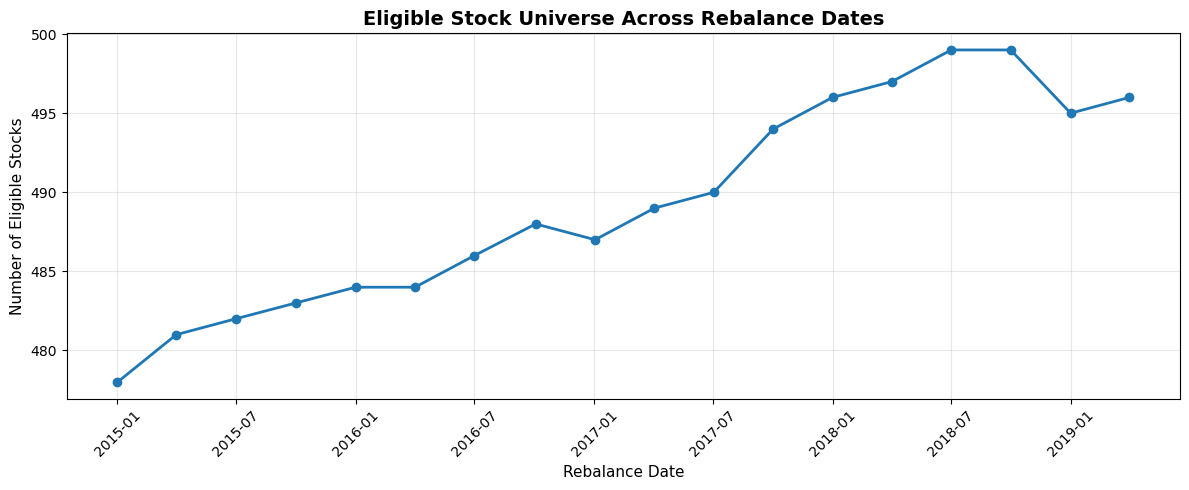

In [681]:
# ============================================================
# PLOT ELIGIBLE UNIVERSE SIZE OVER TIME
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    eligibility_log["Rebalance_Date"],
    eligibility_log["Eligible_Stocks"],
    marker="o",
    linewidth=2
)

plt.title(
    "Eligible Stock Universe Across Rebalance Dates",
    fontsize=14,
    weight="bold",
    color="black"
)

plt.xlabel("Rebalance Date", fontsize=11, color="black")
plt.ylabel("Number of Eligible Stocks", fontsize=11, color="black")

plt.grid(True, alpha=0.3)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, color="black")
plt.yticks(color="black")

plt.tight_layout()
plt.show()

In [682]:
# Check distribution of eligible universe size
display(eligibility_log["Eligible_Stocks"].describe())

count     18.000000
mean     489.333333
std        6.668627
min      478.000000
25%      484.000000
50%      488.500000
75%      495.750000
max      499.000000
Name: Eligible_Stocks, dtype: float64

### **4. Market Proxy & Regime Feature Engineering**

Construct a market proxy using each eligible universe, then extract the features of the regime model.
- Construct an equal-weighted market proxy using eligible stocks; 
- 3-month return; 
- 12-month return; 
- 3-month / 12-month volatility; 
- 12-month maximum drawdown; 
- market breadth; 
- average stock correlation

#### 4.1 Construct equal-weight market proxy

In [683]:
def construct_market_proxy(return_window):
    """
    Construct an equal-weight market proxy using eligible stocks.

    Parameters
    ----------
    return_window : pd.DataFrame
        Lookback daily returns of eligible stocks.

    Returns
    -------
    market_returns : pd.Series
        Equal-weighted daily market return series.
    """

    market_returns = return_window.mean(axis=1, skipna=True)

    return market_returns

#### 4.2 Cumulative return

In [684]:
def calculate_cumulative_return(return_series):
    """
    Calculate cumulative return from a daily return series.

    Parameters
    ----------
    return_series : pd.Series
        Daily return series.

    Returns
    -------
    cumulative_return : float
        Total cumulative return over the period.
    """

    return_series = return_series.dropna()

    if len(return_series) == 0:
        return np.nan

    cumulative_return = (1 + return_series).prod() - 1

    return cumulative_return

#### 4.3 Annualised volatility

In [685]:
def calculate_annualised_volatility(return_series, trading_days=TRADING_DAYS):
    """
    Calculate annualised volatility from daily returns.

    Parameters
    ----------
    return_series : pd.Series
        Daily return series.
    trading_days : int
        Number of trading days per year.

    Returns
    -------
    annualised_volatility : float
        Annualised volatility.
    """

    return_series = return_series.dropna()

    if len(return_series) == 0:
        return np.nan

    annualised_volatility = return_series.std() * np.sqrt(trading_days)

    return annualised_volatility

#### 4.4 Maximum drawdown

In [686]:
def calculate_max_drawdown(return_series):
    """
    Calculate maximum drawdown from a daily return series.

    Parameters
    ----------
    return_series : pd.Series
        Daily return series.

    Returns
    -------
    max_drawdown : float
        Maximum drawdown over the period.
    """

    return_series = return_series.dropna()

    if len(return_series) == 0:
        return np.nan

    cumulative_wealth = (1 + return_series).cumprod()
    running_max = cumulative_wealth.cummax()
    drawdown = cumulative_wealth / running_max - 1

    max_drawdown = drawdown.min()

    return max_drawdown

#### 4.5 Market breadth

The percentage of eligible stocks with positive returns in the past quarter

In [687]:
def calculate_market_breadth(return_window, lookback_days=LOOKBACK_DAYS):
    """
    Calculate market breadth.

    Market breadth is defined as the proportion of eligible stocks
    with positive cumulative return over the recent lookback window.

    Parameters
    ----------
    return_window : pd.DataFrame
        Lookback daily returns of eligible stocks.
    lookback_days : int
        Recent window length, usually 63 trading days.

    Returns
    -------
    breadth : float
        Proportion of stocks with positive recent cumulative return.
    """

    recent_returns = return_window.tail(lookback_days)

    stock_cum_returns = (1 + recent_returns).prod(axis=0, skipna=True) - 1

    breadth = (stock_cum_returns > 0).mean()

    return breadth

#### 4.6 Average correlation

In [688]:
def calculate_average_correlation(return_window):
    """
    Calculate average pairwise correlation among eligible stocks.

    Parameters
    ----------
    return_window : pd.DataFrame
        Lookback daily returns of eligible stocks.

    Returns
    -------
    avg_corr : float
        Average pairwise stock correlation.
    """

    corr_matrix = return_window.corr()

    if corr_matrix.empty:
        return np.nan

    # Take the upper triangle excluding diagonal
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    avg_corr = upper_triangle.stack().mean()

    return avg_corr

#### 4.7 Generate regime features for one rebalance date

In [689]:
def generate_regime_features(
    return_window,
    rebalance_date,
    short_lookback_days=SHORT_LOOKBACK_DAYS,
    trading_days=TRADING_DAYS
):
    """
    Generate market-level regime features for one rebalance date.

    Parameters
    ----------
    return_window : pd.DataFrame
        Lookback returns of eligible stocks.
    rebalance_date : datetime-like
        Current rebalance date.
    short_lookback_days : int
        Short-term lookback window, usually 63 trading days.
    trading_days : int
        Number of trading days per year.

    Returns
    -------
    feature_row : dict
        Market-level regime features.
    """

    market_returns = construct_market_proxy(return_window)

    market_returns_3m = market_returns.tail(short_lookback_days)
    market_returns_12m = market_returns

    feature_row = {
        "Rebalance_Date": pd.to_datetime(rebalance_date),

        # Return features
        "Market_Return_3M": calculate_cumulative_return(market_returns_3m),
        "Market_Return_12M": calculate_cumulative_return(market_returns_12m),

        # Volatility features
        "Market_Vol_3M": calculate_annualised_volatility(
            market_returns_3m,
            trading_days=trading_days
        ),
        "Market_Vol_12M": calculate_annualised_volatility(
            market_returns_12m,
            trading_days=trading_days
        ),

        # Downside risk
        "Market_Max_Drawdown_12M": calculate_max_drawdown(market_returns_12m),

        # Breadth
        "Market_Breadth_3M": calculate_market_breadth(
            return_window,
            lookback_days=short_lookback_days
        ),

        # Correlation
        "Avg_Stock_Correlation_12M": calculate_average_correlation(return_window),

        # Universe size
        "Eligible_Stocks": return_window.shape[1]
    }

    return feature_row

#### 4.8 Test Part 4 on one rebalance date

In [690]:
# ============================================================
# TEST PART 4 ON ONE REBALANCE DATE
# ============================================================

test_rebalance_date = rebalance_schedule.loc[0, "Rebalance_Date"]

eligible_stocks, price_window, return_window, eligibility_info = get_eligible_universe(
    price_df=df_price_full,
    return_df=df_return_full,
    rebalance_date=test_rebalance_date,
    lookback_days=LOOKBACK_DAYS,
    min_valid_ratio=MIN_VALID_RATIO,
    min_avg_price=MIN_AVG_PRICE
)

test_regime_features = generate_regime_features(
    return_window=return_window,
    rebalance_date=test_rebalance_date,
    short_lookback_days=SHORT_LOOKBACK_DAYS,
    trading_days=TRADING_DAYS
)

display(pd.DataFrame([test_regime_features]))

,Rebalance_Date,Market_Return_3M,Market_Return_12M,Market_Vol_3M,Market_Vol_12M,Market_Max_Drawdown_12M,Market_Breadth_3M,Avg_Stock_Correlation_12M,Eligible_Stocks
0,2015-01-01,0.078679,0.173667,0.147391,0.120123,-0.088018,0.817992,0.300221,478


#### 4.9 Build regime feature dataframe for all rebalance dates

In [691]:
# ============================================================
# BUILD REGIME FEATURE DATAFRAME USING MODEL SCHEDULE
# ============================================================

regime_feature_records = []

for rebalance_date in model_schedule["Rebalance_Date"]:

    eligible_stocks, price_window, return_window, eligibility_info = get_eligible_universe(
        price_df=df_price_full,
        return_df=df_return_full,
        rebalance_date=rebalance_date,
        lookback_days=LOOKBACK_DAYS,
        min_valid_ratio=MIN_VALID_RATIO,
        min_avg_price=MIN_AVG_PRICE
    )

    if len(eligible_stocks) == 0:
        continue

    feature_row = generate_regime_features(
        return_window=return_window,
        rebalance_date=rebalance_date,
        short_lookback_days=SHORT_LOOKBACK_DAYS,
        trading_days=TRADING_DAYS
    )

    regime_feature_records.append(feature_row)

regime_feature_df = pd.DataFrame(regime_feature_records)

print("Regime feature dataframe built using model_schedule.")
print(f"Shape: {regime_feature_df.shape}")

display(regime_feature_df.head())
display(regime_feature_df.tail())

Regime feature dataframe built using model_schedule.
Shape: (34, 9)


,Rebalance_Date,Market_Return_3M,Market_Return_12M,Market_Vol_3M,Market_Vol_12M,Market_Max_Drawdown_12M,Market_Breadth_3M,Avg_Stock_Correlation_12M,Eligible_Stocks
0,2011-01-03,0.110326,0.239834,0.120653,0.210156,-0.164212,0.833693,0.466392,463
1,2011-04-01,0.071545,0.226049,0.143798,0.208044,-0.164326,0.737634,0.457691,465
2,2011-07-01,0.001953,0.323545,0.137406,0.155975,-0.076015,0.520430,0.352505,465
3,2011-10-03,-0.193091,-0.021796,0.384676,0.226025,-0.211585,0.096567,0.506127,466
4,2012-01-02,0.156842,0.002905,0.300053,0.270376,-0.236946,0.916129,0.567211,465


,Rebalance_Date,Market_Return_3M,Market_Return_12M,Market_Vol_3M,Market_Vol_12M,Market_Max_Drawdown_12M,Market_Breadth_3M,Avg_Stock_Correlation_12M,Eligible_Stocks
29,2018-04-02,-0.012754,0.162156,0.177036,0.109407,-0.097776,0.414487,0.225181,497
30,2018-07-02,0.041143,0.145949,0.106920,0.116135,-0.097845,0.627255,0.232929,499
31,2018-10-01,0.032950,0.120086,0.086329,0.118423,-0.097845,0.599198,0.232719,499
32,2019-01-01,-0.145734,-0.126828,0.223147,0.159909,-0.222143,0.155556,0.316369,495
33,2019-04-01,0.157001,0.048909,0.136153,0.146483,-0.222330,0.911290,0.274647,496


In [692]:
# ============================================================
# CHECK REGIME FEATURES
# ============================================================

print("Missing values in regime features:")
display(regime_feature_df.isna().sum())

print("\nSummary statistics:")
display(regime_feature_df.describe())

Missing values in regime features:


Rebalance_Date               0
Market_Return_3M             0
Market_Return_12M            0
Market_Vol_3M                0
Market_Vol_12M               0
Market_Max_Drawdown_12M      0
Market_Breadth_3M            0
Avg_Stock_Correlation_12M    0
Eligible_Stocks              0
dtype: int64


Summary statistics:


,Rebalance_Date,Market_Return_3M,Market_Return_12M,Market_Vol_3M,Market_Vol_12M,Market_Max_Drawdown_12M,Market_Breadth_3M,Avg_Stock_Correlation_12M,Eligible_Stocks
count,34,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000
mean,2015-02-15 12:00:00,0.036941,0.161081,0.142307,0.152259,-0.116649,0.626743,0.332468,479.735294
min,2011-01-03 00:00:00,-0.193091,-0.126828,0.060612,0.076333,-0.236946,0.096567,0.127697,463.000000
25%,2013-01-23 12:00:00,0.016106,0.076394,0.103572,0.119214,-0.161833,0.594706,0.272065,468.000000
50%,2015-02-15 00:00:00,0.041579,0.176115,0.127185,0.143795,-0.097845,0.661536,0.316558,480.500000
75%,2017-03-11 06:00:00,0.067920,0.242005,0.159352,0.169945,-0.066027,0.737128,0.371559,488.750000
max,2019-04-01 00:00:00,0.157001,0.361687,0.384676,0.274871,-0.030261,0.916129,0.569635,499.000000
std,NaN,0.074305,0.117208,0.064833,0.050943,0.062589,0.199511,0.111071,11.894253


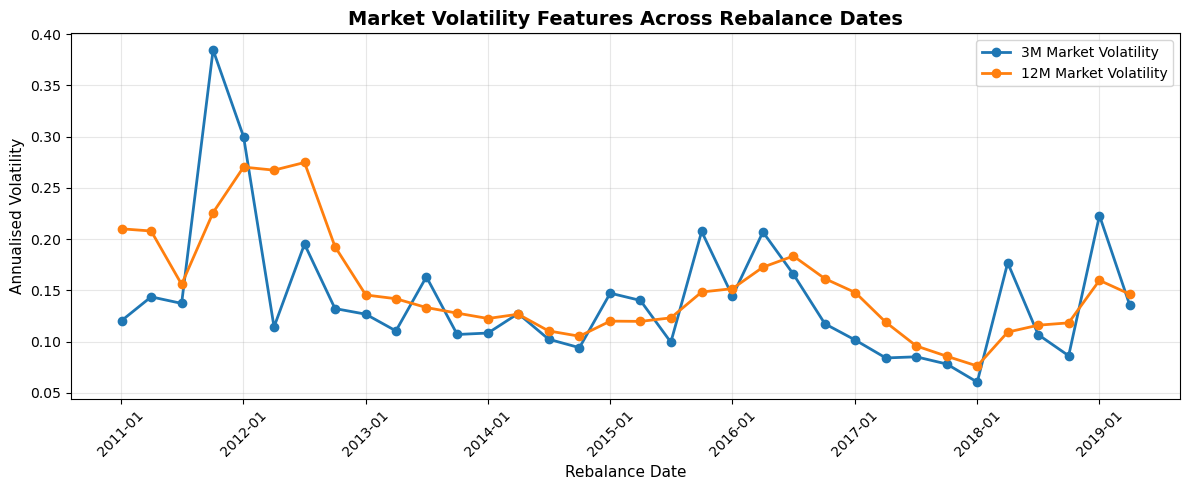

In [693]:
# ============================================================
# QUICK VISUAL CHECK OF REGIME FEATURES
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    regime_feature_df["Rebalance_Date"],
    regime_feature_df["Market_Vol_3M"],
    marker="o",
    linewidth=2,
    label="3M Market Volatility"
)

plt.plot(
    regime_feature_df["Rebalance_Date"],
    regime_feature_df["Market_Vol_12M"],
    marker="o",
    linewidth=2,
    label="12M Market Volatility"
)

plt.title(
    "Market Volatility Features Across Rebalance Dates",
    fontsize=14,
    weight="bold",
    color="black"
)

plt.xlabel("Rebalance Date", fontsize=11, color="black")
plt.ylabel("Annualised Volatility", fontsize=11, color="black")

plt.legend()
plt.grid(True, alpha=0.3)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, color="black")
plt.yticks(color="black")

plt.tight_layout()
plt.show()

### **5. Regime Label Construction**

For each rebalance date, take the next quarter returns; \
construct the next-quarter market return using the current eligible universe; \
calculate the next-quarter realized volatility; \
define the high-risk label using past median during walk-forward training

#### 5.1 Get holding-period returns

In [694]:
def get_holding_period_returns(return_df, start_date, end_date, stocks):
    """
    Extract holding-period returns for a given stock universe.

    Parameters
    ----------
    return_df : pd.DataFrame
        Full daily return data.
    start_date : datetime-like
        Holding period start date.
    end_date : datetime-like
        Holding period end date.
    stocks : list
        Stocks used to construct the market proxy.

    Returns
    -------
    holding_returns : pd.DataFrame
        Holding-period returns for selected stocks.
    """

    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    available_stocks = [stock for stock in stocks if stock in return_df.columns]

    holding_returns = return_df.loc[
        (return_df.index >= start_date) &
        (return_df.index <= end_date),
        available_stocks
    ].copy()

    return holding_returns

#### 5.2 Calculate next-quarter realised market volatility

In [695]:
def calculate_next_period_market_vol(
    return_df,
    start_date,
    end_date,
    eligible_stocks,
    trading_days=TRADING_DAYS
):
    """
    Calculate realised market volatility during the next holding period.

    The realised market return is calculated as the equal-weighted return
    of stocks that were eligible at the rebalance date.

    Parameters
    ----------
    return_df : pd.DataFrame
        Full daily return data.
    start_date : datetime-like
        Holding period start date.
    end_date : datetime-like
        Holding period end date.
    eligible_stocks : list
        Eligible stocks at the rebalance date.
    trading_days : int
        Number of trading days per year.

    Returns
    -------
    realised_vol : float
        Annualised realised volatility during the holding period.
    realised_return : float
        Cumulative market return during the holding period.
    """

    holding_returns = get_holding_period_returns(
        return_df=return_df,
        start_date=start_date,
        end_date=end_date,
        stocks=eligible_stocks
    )

    if holding_returns.empty:
        return np.nan, np.nan

    market_returns = construct_market_proxy(holding_returns)

    realised_vol = calculate_annualised_volatility(
        market_returns,
        trading_days=trading_days
    )

    realised_return = calculate_cumulative_return(market_returns)

    return realised_vol, realised_return

#### 5.3 Build regime label dataframe

In [696]:
def build_regime_label_df(
    return_df,
    price_df,
    rebalance_schedule,
    lookback_days=LOOKBACK_DAYS,
    min_valid_ratio=MIN_VALID_RATIO,
    min_avg_price=MIN_AVG_PRICE,
    trading_days=TRADING_DAYS
):
    """
    Build realised next-period market volatility for each rebalance date.

    Labels are not created here to avoid look-ahead bias.
    Instead, realised volatility is later converted into High/Low risk labels
    inside each walk-forward training window.

    Returns
    -------
    regime_label_df : pd.DataFrame
        DataFrame containing realised next-period volatility and return.
    """

    label_records = []

    for _, row in rebalance_schedule.iterrows():

        rebalance_date = row["Rebalance_Date"]
        holding_start = row["Holding_Start_Date"]
        holding_end = row["Holding_End_Date"]

        eligible_stocks, price_window, return_window, eligibility_info = get_eligible_universe(
            price_df=price_df,
            return_df=return_df,
            rebalance_date=rebalance_date,
            lookback_days=lookback_days,
            min_valid_ratio=min_valid_ratio,
            min_avg_price=min_avg_price
        )

        if len(eligible_stocks) == 0:
            continue

        realised_vol, realised_return = calculate_next_period_market_vol(
            return_df=return_df,
            start_date=holding_start,
            end_date=holding_end,
            eligible_stocks=eligible_stocks,
            trading_days=trading_days
        )

        label_records.append({
            "Rebalance_Date": pd.to_datetime(rebalance_date),
            "Holding_Start_Date": pd.to_datetime(holding_start),
            "Holding_End_Date": pd.to_datetime(holding_end),
            "Next_Period_Market_Vol": realised_vol,
            "Next_Period_Market_Return": realised_return,
            "Eligible_Stocks_For_Label": len(eligible_stocks)
        })

    regime_label_df = pd.DataFrame(label_records)

    return regime_label_df

#### 5.4 Run Part 5

In [697]:
# RUN PART 5
regime_label_df = build_regime_label_df(
    return_df=df_return_full,
    price_df=df_price_full,
    rebalance_schedule=model_schedule,
    lookback_days=LOOKBACK_DAYS,
    min_valid_ratio=MIN_VALID_RATIO,
    min_avg_price=MIN_AVG_PRICE,
    trading_days=TRADING_DAYS
)

print("Regime label dataframe rebuilt using model_schedule.")
print(f"Shape: {regime_label_df.shape}")

display(regime_label_df.head())
display(regime_label_df.tail())

Regime label dataframe rebuilt using model_schedule.
Shape: (34, 6)


,Rebalance_Date,Holding_Start_Date,Holding_End_Date,Next_Period_Market_Vol,Next_Period_Market_Return,Eligible_Stocks_For_Label
0,2011-01-03,2011-01-04,2011-03-31,0.143637,0.071039,463
1,2011-04-01,2011-04-04,2011-06-30,0.136311,0.001942,465
2,2011-07-01,2011-07-04,2011-09-30,0.378611,-0.194373,465
3,2011-10-03,2011-10-04,2011-12-30,0.305267,0.195784,466
4,2012-01-02,2012-01-03,2012-03-30,0.115817,0.151519,465


,Rebalance_Date,Holding_Start_Date,Holding_End_Date,Next_Period_Market_Vol,Next_Period_Market_Return,Eligible_Stocks_For_Label
29,2018-04-02,2018-04-03,2018-06-29,0.108621,0.054497,497
30,2018-07-02,2018-07-03,2018-09-28,0.085722,0.031552,499
31,2018-10-01,2018-10-02,2018-12-31,0.219704,-0.147051,499
32,2019-01-01,2019-01-02,2019-03-29,0.136106,0.156890,495
33,2019-04-01,2019-04-02,2019-06-28,0.125172,0.016196,496


#### 5.5 Combine features and realised future risk

In [698]:
regime_dataset = regime_feature_df.merge(
    regime_label_df,
    on="Rebalance_Date",
    how="inner"
)

print("Regime dataset rebuilt.")
print(f"Shape: {regime_dataset.shape}")
print(f"Date range: {regime_dataset['Rebalance_Date'].min().date()} to {regime_dataset['Rebalance_Date'].max().date()}")

display(regime_dataset.head())
display(regime_dataset.tail())

Regime dataset rebuilt.
Shape: (34, 14)
Date range: 2011-01-03 to 2019-04-01


,Rebalance_Date,Market_Return_3M,Market_Return_12M,Market_Vol_3M,Market_Vol_12M,Market_Max_Drawdown_12M,Market_Breadth_3M,Avg_Stock_Correlation_12M,Eligible_Stocks,Holding_Start_Date,Holding_End_Date,Next_Period_Market_Vol,Next_Period_Market_Return,Eligible_Stocks_For_Label
0,2011-01-03,0.110326,0.239834,0.120653,0.210156,-0.164212,0.833693,0.466392,463,2011-01-04,2011-03-31,0.143637,0.071039,463
1,2011-04-01,0.071545,0.226049,0.143798,0.208044,-0.164326,0.737634,0.457691,465,2011-04-04,2011-06-30,0.136311,0.001942,465
2,2011-07-01,0.001953,0.323545,0.137406,0.155975,-0.076015,0.520430,0.352505,465,2011-07-04,2011-09-30,0.378611,-0.194373,465
3,2011-10-03,-0.193091,-0.021796,0.384676,0.226025,-0.211585,0.096567,0.506127,466,2011-10-04,2011-12-30,0.305267,0.195784,466
4,2012-01-02,0.156842,0.002905,0.300053,0.270376,-0.236946,0.916129,0.567211,465,2012-01-03,2012-03-30,0.115817,0.151519,465


,Rebalance_Date,Market_Return_3M,Market_Return_12M,Market_Vol_3M,Market_Vol_12M,Market_Max_Drawdown_12M,Market_Breadth_3M,Avg_Stock_Correlation_12M,Eligible_Stocks,Holding_Start_Date,Holding_End_Date,Next_Period_Market_Vol,Next_Period_Market_Return,Eligible_Stocks_For_Label
29,2018-04-02,-0.012754,0.162156,0.177036,0.109407,-0.097776,0.414487,0.225181,497,2018-04-03,2018-06-29,0.108621,0.054497,497
30,2018-07-02,0.041143,0.145949,0.106920,0.116135,-0.097845,0.627255,0.232929,499,2018-07-03,2018-09-28,0.085722,0.031552,499
31,2018-10-01,0.032950,0.120086,0.086329,0.118423,-0.097845,0.599198,0.232719,499,2018-10-02,2018-12-31,0.219704,-0.147051,499
32,2019-01-01,-0.145734,-0.126828,0.223147,0.159909,-0.222143,0.155556,0.316369,495,2019-01-02,2019-03-29,0.136106,0.156890,495
33,2019-04-01,0.157001,0.048909,0.136153,0.146483,-0.222330,0.911290,0.274647,496,2019-04-02,2019-06-28,0.125172,0.016196,496


#### 5.6 Check target variable

In [699]:
# CHECK REALISED FUTURE RISK

print("Next-period realised volatility summary:")
display(regime_dataset["Next_Period_Market_Vol"].describe())

print("\nMissing values:")
display(regime_dataset.isna().sum())

Next-period realised volatility summary:


count    34.000000
mean      0.142227
std       0.064282
min       0.060133
25%       0.102813
50%       0.126309
75%       0.159365
max       0.378611
Name: Next_Period_Market_Vol, dtype: float64


Missing values:


Rebalance_Date               0
Market_Return_3M             0
Market_Return_12M            0
Market_Vol_3M                0
Market_Vol_12M               0
Market_Max_Drawdown_12M      0
Market_Breadth_3M            0
Avg_Stock_Correlation_12M    0
Eligible_Stocks              0
Holding_Start_Date           0
Holding_End_Date             0
Next_Period_Market_Vol       0
Next_Period_Market_Return    0
Eligible_Stocks_For_Label    0
dtype: int64

### **6. Stock-Level Feature Calculation**

Calculate:
- annualized return; 
- annualized volatility;
- Calculate annualized Sharpe;
- Calculate max drawdown;
- average correlation between each stock and other stocks \
Join sector; 

#### 6.1 Annualised return

In [700]:
def calculate_annualised_return(return_series, trading_days=TRADING_DAYS):
    """
    Calculate annualised return from daily simple returns.

    Parameters
    ----------
    return_series : pd.Series
        Daily return series for one stock.
    trading_days : int
        Number of trading days per year.

    Returns
    -------
    annualised_return : float
        Annualised return.
    """

    return_series = return_series.dropna()

    if len(return_series) == 0:
        return np.nan

    cumulative_return = (1 + return_series).prod() - 1
    annualised_return = (1 + cumulative_return) ** (trading_days / len(return_series)) - 1

    return annualised_return

#### 6.2 Stock Sharpe ratio

In [701]:
def calculate_stock_sharpe(return_series, rf_daily=RF_DAILY, trading_days=TRADING_DAYS):
    """
    Calculate annualised Sharpe ratio for one stock.

    Parameters
    ----------
    return_series : pd.Series
        Daily return series for one stock.
    rf_daily : float
        Daily risk-free rate.
    trading_days : int
        Number of trading days per year.

    Returns
    -------
    sharpe_ratio : float
        Annualised Sharpe ratio.
    """

    return_series = return_series.dropna()

    if len(return_series) == 0:
        return np.nan

    excess_returns = return_series - rf_daily

    annualised_excess_return = calculate_annualised_return(
        excess_returns,
        trading_days=trading_days
    )

    annualised_volatility = calculate_annualised_volatility(
        return_series,
        trading_days=trading_days
    )

    if annualised_volatility == 0 or np.isnan(annualised_volatility):
        return np.nan

    sharpe_ratio = annualised_excess_return / annualised_volatility

    return sharpe_ratio

#### 6.3 Stock average correlation

In [702]:
def calculate_stock_average_correlation(return_window):
    """
    Calculate each stock's average correlation with other stocks.

    Parameters
    ----------
    return_window : pd.DataFrame
        Lookback returns of eligible stocks.

    Returns
    -------
    avg_corr_series : pd.Series
        Average correlation for each stock.
    """

    corr_matrix = return_window.corr()

    if corr_matrix.empty:
        return pd.Series(dtype=float)

    # Remove self-correlation by replacing diagonal with NaN
    corr_matrix_no_diag = corr_matrix.copy()
    np.fill_diagonal(corr_matrix_no_diag.values, np.nan)

    avg_corr_series = corr_matrix_no_diag.mean(axis=1, skipna=True)

    return avg_corr_series

In [703]:
def calculate_period_return(return_series):
    """
    Calculate cumulative return over a period.
    """
    return (1 + return_series.dropna()).prod() - 1


def calculate_downside_volatility(return_series, trading_days=TRADING_DAYS):
    """
    Calculate annualised downside volatility using only negative daily returns.
    """
    downside_returns = return_series.dropna()
    downside_returns = downside_returns[downside_returns < 0]

    if len(downside_returns) < 2:
        return np.nan

    return downside_returns.std() * np.sqrt(trading_days)


def calculate_market_beta(stock_returns, market_returns):
    """
    Calculate stock beta relative to market return.
    beta = Cov(stock, market) / Var(market)
    """
    aligned = pd.concat([stock_returns, market_returns], axis=1).dropna()

    if aligned.shape[0] < 20:
        return np.nan

    stock_col = aligned.columns[0]
    market_col = aligned.columns[1]

    market_var = aligned[market_col].var()

    if market_var == 0 or np.isnan(market_var):
        return np.nan

    beta = aligned[stock_col].cov(aligned[market_col]) / market_var

    return beta

#### 6.4 Main stock feature function

In [886]:
def calculate_stock_features(return_window, sector_map, rf_daily=RF_DAILY, trading_days=TRADING_DAYS):
    """
    Calculate stock-level features for all eligible stocks in one lookback window.

    Parameters
    ----------
    return_window : pd.DataFrame
        Lookback daily returns of eligible stocks.
    sector_map : pd.DataFrame
        Stock-sector mapping with columns: Stock, Sector.
    rf_daily : float
        Daily risk-free rate.
    trading_days : int
        Number of trading days per year.

    Returns
    -------
    stock_feature_df : pd.DataFrame
        Stock-level feature dataframe.
    """

    feature_records = []

    avg_corr_series = calculate_stock_average_correlation(return_window)

    # Equal-weight market proxy within the eligible universe
    market_returns = return_window.mean(axis=1)

    # Convert sector map to dictionary for fast lookup
    sector_dict = sector_map.set_index("Stock")["Sector"].to_dict()

    for stock in return_window.columns:

        stock_returns = return_window[stock].dropna()

        if len(stock_returns) == 0:
            continue

        annual_return = calculate_annualised_return(
            stock_returns,
            trading_days=trading_days
        )

        annual_volatility = calculate_annualised_volatility(
            stock_returns,
            trading_days=trading_days
        )

        sharpe_ratio = calculate_stock_sharpe(
            stock_returns,
            rf_daily=rf_daily,
            trading_days=trading_days
        )

        max_drawdown = calculate_max_drawdown(stock_returns)

        avg_correlation = avg_corr_series.get(stock, np.nan)

        # New ML-related features
        return_3m = calculate_period_return(
            stock_returns.tail(63)
        )

        return_6m = calculate_period_return(
            stock_returns.tail(126)
        )

        volatility_3m = calculate_annualised_volatility(
            stock_returns.tail(63),
            trading_days=trading_days
        )

        downside_volatility = calculate_downside_volatility(
            stock_returns,
            trading_days=trading_days
        )

        market_beta = calculate_market_beta(
            stock_returns,
            market_returns
        )

        sector = sector_dict.get(stock, "Unknown")

        feature_records.append({
            "Stock": stock,
            "Sector": sector,

            "Annual_Return": annual_return,
            "Annual_Volatility": annual_volatility,
            "Sharpe_Ratio": sharpe_ratio,
            "Max_Drawdown": max_drawdown,
            "Avg_Correlation": avg_correlation,

            "Return_3M": return_3m,
            "Return_6M": return_6m,
            "Volatility_3M": volatility_3m,
            "Downside_Volatility": downside_volatility,
            "Market_Beta": market_beta,

            "Valid_Observations": len(stock_returns)
        })

    stock_feature_df = pd.DataFrame(feature_records)

    stock_feature_df = stock_feature_df.dropna(
        subset=[
            "Annual_Return",
            "Annual_Volatility",
            "Sharpe_Ratio",
            "Max_Drawdown"
        ]
    )

    # Do not remove stocks just because beta / correlation / downside vol is missing.
    # Fill these with median values instead.
    fill_cols = [
        "Avg_Correlation",
        "Return_3M",
        "Return_6M",
        "Volatility_3M",
        "Downside_Volatility",
        "Market_Beta"
    ]

    for col in fill_cols:
        if col in stock_feature_df.columns:
            stock_feature_df[col] = stock_feature_df[col].fillna(
                stock_feature_df[col].median()
            )

    # ------------------------------------------------------------
    # Sector-relative features
    # Compare each stock against stocks in the same sector
    # ------------------------------------------------------------

    stock_feature_df["Sector_Return_Rank"] = (
        stock_feature_df
        .groupby("Sector")["Annual_Return"]
        .rank(pct=True)
    )

    stock_feature_df["Sector_Sharpe_Rank"] = (
        stock_feature_df
        .groupby("Sector")["Sharpe_Ratio"]
        .rank(pct=True)
    )

    stock_feature_df["Sector_Volatility_Rank"] = (
        stock_feature_df
        .groupby("Sector")["Annual_Volatility"]
        .rank(pct=True)
    )

    stock_feature_df["Sector_3M_Return_Rank"] = (
        stock_feature_df
        .groupby("Sector")["Return_3M"]
        .rank(pct=True)
    )

    stock_feature_df["Sector_6M_Return_Rank"] = (
        stock_feature_df
        .groupby("Sector")["Return_6M"]
        .rank(pct=True)
    )

    stock_feature_df["Sector_Beta_Rank"] = (
        stock_feature_df
        .groupby("Sector")["Market_Beta"]
        .rank(pct=True)
    )

    # ------------------------------------------------------------
    # Composite selection score
    # Higher score = better stock candidate
    # Used for preliminary candidate screening.
    # ------------------------------------------------------------
    stock_feature_df["Selection_Score"] = (
        0.30 * stock_feature_df["Volatility_3M"].rank(pct=True)
        + 0.25 * stock_feature_df["Avg_Correlation"].rank(pct=True)
        + 0.15 * stock_feature_df["Downside_Volatility"].rank(pct=True)
        + 0.10 * stock_feature_df["Annual_Volatility"].rank(pct=True)
        - 0.10 * stock_feature_df["Return_6M"].rank(pct=True)
        - 0.10 * stock_feature_df["Sharpe_Ratio"].rank(pct=True)
    )

    stock_feature_df = stock_feature_df.sort_values(
        by="Selection_Score",
        ascending=False
    ).reset_index(drop=True)

    return stock_feature_df

#### 6.5 Test Part 6 on one rebalance date

In [887]:
# ============================================================
# TEST PART 6 ON ONE REBALANCE DATE
# ============================================================

test_rebalance_date = rebalance_schedule.loc[0, "Rebalance_Date"]

eligible_stocks, price_window, return_window, eligibility_info = get_eligible_universe(
    price_df=df_price_full,
    return_df=df_return_full,
    rebalance_date=test_rebalance_date,
    lookback_days=LOOKBACK_DAYS,
    min_valid_ratio=MIN_VALID_RATIO,
    min_avg_price=MIN_AVG_PRICE
)

stock_feature_df = calculate_stock_features(
    return_window=return_window,
    sector_map=sector_map,
    rf_daily=RF_DAILY,
    trading_days=TRADING_DAYS
)

print("Test rebalance date:", test_rebalance_date.date())
print(f"Eligible stocks      : {len(eligible_stocks)}")
print(f"Stock feature rows   : {len(stock_feature_df)}")

display(stock_feature_df.head(5))

Test rebalance date: 2015-01-01
Eligible stocks      : 478
Stock feature rows   : 478


,Stock,Sector,Annual_Return,Annual_Volatility,Sharpe_Ratio,Max_Drawdown,Avg_Correlation,Return_3M,Return_6M,Volatility_3M,Downside_Volatility,Market_Beta,Valid_Observations,Sector_Return_Rank,Sector_Sharpe_Rank,Sector_Volatility_Rank,Sector_3M_Return_Rank,Sector_6M_Return_Rank,Sector_Beta_Rank,Selection_Score
0,TEX US Equity,Industrials,-0.307549,0.361391,-0.851014,-0.423225,0.347666,-0.123614,-0.324377,0.475312,0.280997,1.971035,252,0.013333,0.053333,0.960000,0.053333,0.013333,0.973333,0.692782
1,MTW US Equity,Industrials,-0.087504,0.446960,-0.195776,-0.498277,0.328009,-0.035530,-0.310878,0.574865,0.351197,2.276763,252,0.160000,0.226667,1.000000,0.160000,0.026667,1.000000,0.679393
2,URI US Equity,Industrials,0.323430,0.328899,0.983374,-0.240155,0.409758,-0.065500,-0.040177,0.421949,0.270391,2.103925,252,0.840000,0.613333,0.906667,0.120000,0.293333,0.986667,0.663808
3,PWR US Equity,Industrials,-0.088604,0.257358,-0.344282,-0.313710,0.367292,-0.202528,-0.191398,0.380703,0.221728,1.464883,252,0.146667,0.146667,0.760000,0.013333,0.106667,0.866667,0.653033
4,TRIP US Equity,Consumer Cyclical,-0.115927,0.402598,-0.287946,-0.378187,0.310462,-0.157622,-0.264071,0.454967,0.307345,1.972565,252,0.152778,0.166667,0.944444,0.055556,0.027778,1.000000,0.645711


#### 6.6 Check sector distribution among top-ranked stocks

In [888]:
# ============================================================
# CHECK TOP STOCK SECTOR DISTRIBUTION
# ============================================================

TOP_N_CHECK = 50

top_stock_sector_distribution = (
    stock_feature_df.head(TOP_N_CHECK)["Sector"]
    .value_counts()
    .rename_axis("Sector")
    .reset_index(name="Number_of_Stocks")
)

print(f"Sector distribution among top {TOP_N_CHECK} stocks by Sharpe:")
display(top_stock_sector_distribution)

Sector distribution among top 50 stocks by Sharpe:


,Sector,Number_of_Stocks
0,Industrials,18
1,Energy,9
2,Basic Materials,7
3,Consumer Cyclical,6
4,Technology,6
5,Financial Services,4


#### 6.7 Build stock feature logs for all rebalance dates

In [889]:
# ============================================================
# BUILD STOCK FEATURE DATAFRAME FOR ALL REBALANCE DATES
# ============================================================

all_stock_feature_records = []

for rebalance_date in rebalance_schedule["Rebalance_Date"]:

    eligible_stocks, price_window, return_window, eligibility_info = get_eligible_universe(
        price_df=df_price_full,
        return_df=df_return_full,
        rebalance_date=rebalance_date,
        lookback_days=LOOKBACK_DAYS,
        min_valid_ratio=MIN_VALID_RATIO,
        min_avg_price=MIN_AVG_PRICE
    )

    if len(eligible_stocks) == 0:
        continue

    stock_features = calculate_stock_features(
        return_window=return_window,
        sector_map=sector_map,
        rf_daily=RF_DAILY,
        trading_days=TRADING_DAYS
    )

    stock_features["Rebalance_Date"] = pd.to_datetime(rebalance_date)

    all_stock_feature_records.append(stock_features)

all_stock_feature_df = pd.concat(
    all_stock_feature_records,
    ignore_index=True
)

print("All stock feature dataframe created.")
print(f"Shape: {all_stock_feature_df.shape}")

display(all_stock_feature_df.head())
display(all_stock_feature_df.tail())

All stock feature dataframe created.
Shape: (8807, 21)


,Stock,Sector,Annual_Return,Annual_Volatility,Sharpe_Ratio,Max_Drawdown,Avg_Correlation,Return_3M,Return_6M,Volatility_3M,...,Market_Beta,Valid_Observations,Sector_Return_Rank,Sector_Sharpe_Rank,Sector_Volatility_Rank,Sector_3M_Return_Rank,Sector_6M_Return_Rank,Sector_Beta_Rank,Selection_Score,Rebalance_Date
0,TEX US Equity,Industrials,-0.307549,0.361391,-0.851014,-0.423225,0.347666,-0.123614,-0.324377,0.475312,...,1.971035,252,0.013333,0.053333,0.960000,0.053333,0.013333,0.973333,0.692782,2015-01-01
1,MTW US Equity,Industrials,-0.087504,0.446960,-0.195776,-0.498277,0.328009,-0.035530,-0.310878,0.574865,...,2.276763,252,0.160000,0.226667,1.000000,0.160000,0.026667,1.000000,0.679393,2015-01-01
2,URI US Equity,Industrials,0.323430,0.328899,0.983374,-0.240155,0.409758,-0.065500,-0.040177,0.421949,...,2.103925,252,0.840000,0.613333,0.906667,0.120000,0.293333,0.986667,0.663808,2015-01-01
3,PWR US Equity,Industrials,-0.088604,0.257358,-0.344282,-0.313710,0.367292,-0.202528,-0.191398,0.380703,...,1.464883,252,0.146667,0.146667,0.760000,0.013333,0.106667,0.866667,0.653033,2015-01-01
4,TRIP US Equity,Consumer Cyclical,-0.115927,0.402598,-0.287946,-0.378187,0.310462,-0.157622,-0.264071,0.454967,...,1.972565,252,0.152778,0.166667,0.944444,0.055556,0.027778,1.000000,0.645711,2015-01-01


,Stock,Sector,Annual_Return,Annual_Volatility,Sharpe_Ratio,Max_Drawdown,Avg_Correlation,Return_3M,Return_6M,Volatility_3M,...,Market_Beta,Valid_Observations,Sector_Return_Rank,Sector_Sharpe_Rank,Sector_Volatility_Rank,Sector_3M_Return_Rank,Sector_6M_Return_Rank,Sector_Beta_Rank,Selection_Score,Rebalance_Date
8802,WEC US Equity,Utilities,0.292631,0.162462,1.801228,-0.098453,0.102515,0.150834,0.194012,0.131221,...,0.142951,252,0.857143,0.892857,0.178571,0.857143,0.750000,0.250000,-0.147984,2019-04-01
8803,AEP US Equity,Utilities,0.259086,0.163796,1.581765,-0.099709,0.080801,0.130110,0.207829,0.136825,...,0.101046,252,0.714286,0.785714,0.214286,0.571429,0.892857,0.071429,-0.149294,2019-04-01
8804,EXC US Equity,Utilities,0.324776,0.151266,2.147054,-0.068635,0.134686,0.119942,0.176961,0.133138,...,0.203759,252,0.892857,0.964286,0.035714,0.428571,0.714286,0.607143,-0.152218,2019-04-01
8805,XEL US Equity,Utilities,0.266174,0.168287,1.581663,-0.105519,0.110078,0.149071,0.202365,0.131157,...,0.165803,252,0.785714,0.750000,0.392857,0.785714,0.821429,0.357143,-0.152319,2019-04-01
8806,DUK US Equity,Utilities,0.195043,0.156695,1.244725,-0.093488,0.082062,0.053784,0.149963,0.118328,...,0.099774,252,0.357143,0.464286,0.071429,0.107143,0.392857,0.035714,-0.152319,2019-04-01


#### 6.8 Quick summary check

In [890]:
# ============================================================
# CHECK STOCK FEATURES
# ============================================================

print("Stock feature summary:")
display(
    all_stock_feature_df[
        ["Annual_Return", "Annual_Volatility", "Sharpe_Ratio", "Max_Drawdown", "Avg_Correlation"]
    ].describe()
)

print("\nNumber of stocks per rebalance date:")
display(
    all_stock_feature_df.groupby("Rebalance_Date")["Stock"]
    .nunique()
    .describe()
)

Stock feature summary:


,Annual_Return,Annual_Volatility,Sharpe_Ratio,Max_Drawdown,Avg_Correlation
count,8807.000000,8807.000000,8807.000000,8807.000000,8807.000000
mean,0.123406,0.258379,0.586277,-0.220735,0.274315
std,0.318734,0.107895,1.070392,0.126285,0.105194
min,-0.815798,0.051581,-2.160419,-0.863665,-0.091011
25%,-0.052320,0.188182,-0.209265,-0.281556,0.195718
50%,0.108229,0.231561,0.491334,-0.183667,0.278957
75%,0.268401,0.296158,1.271227,-0.129281,0.352362
max,5.371212,1.201341,8.335523,-0.035706,0.525672



Number of stocks per rebalance date:


count     18.000000
mean     489.277778
std        6.587024
min      478.000000
25%      484.000000
50%      488.500000
75%      495.750000
max      499.000000
Name: Stock, dtype: float64

### **7. Stock Selection**

Select the k stocks that will ultimately be included in the portfolio based on historical quality and stock-level ML prediction.
1. Use historical Selection_Score to pre-screen the top N candidates;
2. Predict each candidate stock's next-period outperform probability using past stock-level observations;
3. Select the top K candidates by predicted probability while applying sector cap and correlation filters.


To make the stock selection process more forward-looking, a stock-level outperformance prediction model was added after the preliminary screening stage. Instead of selecting stocks only based on historical Sharpe ratio or selection score, the model predicts whether each candidate stock is likely to outperform the market in the next holding period.

First, eligible stocks are ranked using historical risk-return features such as annual return, Sharpe ratio, volatility, drawdown and average correlation. The top candidates are then passed into a Gradient Boosting classifier. The model uses stock-level features including short-term momentum, medium-term return, volatility, downside volatility, beta and correlation. The target variable is whether each candidate stock is likely to outperform the cross-sectional median stock return in the next holding period.

This model is trained in a walk-forward manner using only information available before the current rebalance date. At each rebalance date, the model predicts an outperformance probability for each candidate stock. Final stock selection is then based on predicted probability, with sector and correlation constraints applied to maintain diversification.

#### 7.1 Build stock-level ML training labels


In [891]:
STOCK_MODEL_FEATURE_COLS = [
    "Return_3M",
    "Return_6M",
    "Annual_Return",
    "Annual_Volatility",
    "Volatility_3M",
    "Sharpe_Ratio",
    "Max_Drawdown",
    "Downside_Volatility",
    "Avg_Correlation",
    "Market_Beta",
    "Sector_Return_Rank",
    "Sector_Sharpe_Rank",
    "Sector_Volatility_Rank"
]

In [892]:

def calculate_next_period_stock_returns(return_df, start_date, end_date, stocks):
    """
    Calculate realised holding-period return for each stock in the next period.
    """

    available_stocks = [stock for stock in stocks if stock in return_df.columns]

    if len(available_stocks) == 0:
        return pd.Series(dtype=float)

    next_period_returns = return_df.loc[
        (return_df.index >= pd.to_datetime(start_date)) &
        (return_df.index <= pd.to_datetime(end_date)),
        available_stocks
    ].copy()

    if next_period_returns.empty:
        return pd.Series(dtype=float)

    realised_stock_returns = (1 + next_period_returns).prod() - 1

    return realised_stock_returns.replace([np.inf, -np.inf], np.nan).dropna()


def build_stock_outperform_dataset(
    price_df,
    return_df,
    sector_map,
    rebalance_schedule,
    lookback_days=LOOKBACK_DAYS,
    min_valid_ratio=MIN_VALID_RATIO,
    min_avg_price=MIN_AVG_PRICE,
    rf_daily=RF_DAILY,
    trading_days=TRADING_DAYS
):
    """
    Build a stock-level supervised dataset.

    Features use only the historical lookback window available at each
    rebalance date. Labels use the following holding period and are only used
    for later walk-forward training.

    Target definition:
    1 = stock return is above the cross-sectional median next-period return
    0 = stock return is at or below the cross-sectional median next-period return
    """

    stock_model_records = []

    for _, schedule_row in rebalance_schedule.iterrows():

        rebalance_date = pd.to_datetime(schedule_row["Rebalance_Date"])
        holding_start = pd.to_datetime(schedule_row["Holding_Start_Date"])
        holding_end = pd.to_datetime(schedule_row["Holding_End_Date"])

        eligible_stocks, price_window, return_window, eligibility_info = get_eligible_universe(
            price_df=price_df,
            return_df=return_df,
            rebalance_date=rebalance_date,
            lookback_days=lookback_days,
            min_valid_ratio=min_valid_ratio,
            min_avg_price=min_avg_price
        )

        if len(eligible_stocks) == 0:
            continue

        feature_df = calculate_stock_features(
            return_window=return_window,
            sector_map=sector_map,
            rf_daily=rf_daily,
            trading_days=trading_days
        )

        realised_returns = calculate_next_period_stock_returns(
            return_df=return_df,
            start_date=holding_start,
            end_date=holding_end,
            stocks=feature_df["Stock"].tolist()
        )

        if realised_returns.empty:
            continue

        feature_df = feature_df.copy()
        feature_df["Rebalance_Date"] = rebalance_date
        feature_df["Holding_Start_Date"] = holding_start
        feature_df["Holding_End_Date"] = holding_end
        feature_df["Next_Period_Stock_Return"] = feature_df["Stock"].map(realised_returns)
        
        feature_df["Next_Period_Return_Rank"] = (
            feature_df["Next_Period_Stock_Return"]
            .rank(pct=True)
        )

        feature_df["Outperform_Target_Threshold"] = 0.70
        feature_df["Outperform_Next_Period"] = (
            feature_df["Next_Period_Return_Rank"] >= feature_df["Outperform_Target_Threshold"]
        ).astype(float)

        feature_df = feature_df.dropna(
            subset=STOCK_MODEL_FEATURE_COLS + ["Outperform_Next_Period"]
        )

        stock_model_records.append(feature_df)

    if len(stock_model_records) == 0:
        return pd.DataFrame()

    stock_model_dataset = pd.concat(stock_model_records, ignore_index=True)
    stock_model_dataset["Outperform_Next_Period"] = stock_model_dataset[
        "Outperform_Next_Period"
    ].astype(int)

    return stock_model_dataset


In [893]:

# ============================================================
# BUILD STOCK-LEVEL ML DATASET
# ============================================================

stock_model_dataset = build_stock_outperform_dataset(
    price_df=df_price_full,
    return_df=df_return_full,
    sector_map=sector_map,
    rebalance_schedule=model_schedule,
    lookback_days=LOOKBACK_DAYS,
    min_valid_ratio=MIN_VALID_RATIO,
    min_avg_price=MIN_AVG_PRICE,
    rf_daily=RF_DAILY,
    trading_days=TRADING_DAYS
)

print("Stock-level ML dataset created.")
print(f"Shape: {stock_model_dataset.shape}")

if not stock_model_dataset.empty:
    print("Target distribution:")
    display(stock_model_dataset["Outperform_Next_Period"].value_counts(normalize=True))
    display(stock_model_dataset.head())


Stock-level ML dataset created.
Shape: (16309, 27)
Target distribution:


Outperform_Next_Period
0    0.698878
1    0.301122
Name: proportion, dtype: float64

,Stock,Sector,Annual_Return,Annual_Volatility,Sharpe_Ratio,Max_Drawdown,Avg_Correlation,Return_3M,Return_6M,Volatility_3M,...,Sector_6M_Return_Rank,Sector_Beta_Rank,Selection_Score,Rebalance_Date,Holding_Start_Date,Holding_End_Date,Next_Period_Stock_Return,Next_Period_Return_Rank,Outperform_Target_Threshold,Outperform_Next_Period
0,GNW US Equity,Financial Services,-0.005299,0.483433,-0.010961,-0.441456,0.516143,0.059677,-0.058065,0.346962,...,0.046875,0.968750,0.641793,2011-01-03,2011-01-04,2011-03-31,-0.002963,0.250540,0.7,0
1,MU US Equity,Technology,-0.233270,0.502975,-0.463779,-0.428451,0.476453,0.157287,-0.077100,0.400657,...,0.053571,0.964286,0.630238,2011-01-03,2011-01-04,2011-03-31,0.386103,0.984881,0.7,1
2,ATI US Equity,Industrials,0.171210,0.473580,0.361523,-0.296260,0.545186,0.167293,0.162643,0.357581,...,0.267606,0.943662,0.622138,2011-01-03,2011-01-04,2011-03-31,0.180035,0.848812,0.7,1
3,LNC US Equity,Financial Services,0.019470,0.418783,0.046492,-0.362344,0.554769,0.126367,0.115972,0.308082,...,0.375000,0.953125,0.621382,2011-01-03,2011-01-04,2011-03-31,0.027682,0.367171,0.7,0
4,SANM US Equity,Technology,-0.015437,0.577242,-0.026743,-0.529657,0.485255,-0.077912,-0.191549,0.349948,...,0.017857,1.000000,0.615011,2011-01-03,2011-01-04,2011-03-31,-0.078882,0.077754,0.7,0


#### 7.2 Preliminary candidate screening and ML prediction


In [894]:
# ============================================================
# PRELIMINARY CANDIDATE SCREENING
# ============================================================
def preliminary_candidate_screening(
    stock_feature_df,
    top_n=CANDIDATE_POOL_SIZE,
    score_col="Selection_Score"
):
    """
    Keep the top N stocks by historical Selection_Score before ML ranking.
    """

    if stock_feature_df.empty:
        return stock_feature_df.copy()

    candidate_df = (
        stock_feature_df
        .dropna(subset=[score_col])
        .sort_values(score_col, ascending=False)
        .head(top_n)
        .reset_index(drop=True)
        .copy()
    )

    candidate_df["Candidate_Rank_By_Selection_Score"] = np.arange(
        1,
        len(candidate_df) + 1
    )

    return candidate_df


def _prepare_stock_model_matrix(df, feature_cols, fill_values=None):
    """
    Build a numeric model matrix and apply median imputation.
    """

    X = df[feature_cols].replace([np.inf, -np.inf], np.nan).copy()

    if fill_values is None:
        fill_values = X.median(numeric_only=True)

    X = X.fillna(fill_values)

    return X, fill_values


#### 7.3 Stock model performance & Evaluation

In [895]:
def _get_positive_class_probability(fitted_model, X):
    """
    Return predicted probability for class 1 if available.
    Otherwise return predicted labels as float.
    """

    if hasattr(fitted_model, "predict_proba"):
        classes = list(fitted_model.classes_)

        if 1 in classes:
            positive_index = classes.index(1)
            return fitted_model.predict_proba(X)[:, positive_index]

    return fitted_model.predict(X).astype(float)

In [896]:
def evaluate_stock_model_candidates(
    train_df,
    feature_cols=STOCK_MODEL_FEATURE_COLS,
    model_candidates=STOCK_MODEL_CANDIDATES,
    validation_rebalance_count=4
):
    """
    Compare stock-level candidate models using training-period data only.

    The split is time-aware:
    - earlier training-period rebalance dates are used to fit each model
    - the most recent training-period rebalance dates are used for validation
    """

    train_df = train_df.copy()
    train_df["Rebalance_Date"] = pd.to_datetime(train_df["Rebalance_Date"])

    unique_dates = sorted(train_df["Rebalance_Date"].dropna().unique())

    if len(unique_dates) <= validation_rebalance_count:
        validation_rebalance_count = max(1, len(unique_dates) // 3)

    validation_dates = unique_dates[-validation_rebalance_count:]

    model_train_df = train_df[
        ~train_df["Rebalance_Date"].isin(validation_dates)
    ].copy()

    validation_df = train_df[
        train_df["Rebalance_Date"].isin(validation_dates)
    ].copy()

    if model_train_df.empty or validation_df.empty:
        return pd.DataFrame(), None

    if model_train_df["Outperform_Next_Period"].nunique() < 2:
        return pd.DataFrame(), None

    if validation_df["Outperform_Next_Period"].nunique() < 2:
        return pd.DataFrame(), None

    X_train, fill_values = _prepare_stock_model_matrix(
        model_train_df,
        feature_cols
    )
    y_train = model_train_df["Outperform_Next_Period"].astype(int)

    X_valid, _ = _prepare_stock_model_matrix(
        validation_df,
        feature_cols,
        fill_values=fill_values
    )
    y_valid = validation_df["Outperform_Next_Period"].astype(int)

    performance_records = []

    for model_name, model in model_candidates.items():

        try:
            fitted_model = clone(model)
            fitted_model.fit(X_train, y_train)

            valid_prob = _get_positive_class_probability(fitted_model, X_valid)
            valid_pred = (valid_prob >= 0.5).astype(int)

            accuracy = accuracy_score(y_valid, valid_pred)
            precision = precision_score(y_valid, valid_pred, zero_division=0)
            recall = recall_score(y_valid, valid_pred, zero_division=0)
            f1 = f1_score(y_valid, valid_pred, zero_division=0)

            try:
                auc = roc_auc_score(y_valid, valid_prob)
            except ValueError:
                auc = np.nan

            performance_records.append({
                "Model": model_name,
                "Training_Rows": len(model_train_df),
                "Validation_Rows": len(validation_df),
                "Training_Start": model_train_df["Rebalance_Date"].min(),
                "Training_End": model_train_df["Rebalance_Date"].max(),
                "Validation_Start": min(validation_dates),
                "Validation_End": max(validation_dates),
                "Accuracy": accuracy,
                "Precision": precision,
                "Recall": recall,
                "F1": f1,
                "AUC": auc
            })

        except Exception as e:
            performance_records.append({
                "Model": model_name,
                "Training_Rows": len(model_train_df),
                "Validation_Rows": len(validation_df),
                "Training_Start": model_train_df["Rebalance_Date"].min(),
                "Training_End": model_train_df["Rebalance_Date"].max(),
                "Validation_Start": min(validation_dates),
                "Validation_End": max(validation_dates),
                "Accuracy": np.nan,
                "Precision": np.nan,
                "Recall": np.nan,
                "F1": np.nan,
                "AUC": np.nan,
                "Error": str(e)
            })

    performance_df = pd.DataFrame(performance_records)

    if performance_df.empty:
        return performance_df, None

    performance_df["Selection_Metric"] = performance_df["AUC"].fillna(
        performance_df["F1"]
    )

    valid_performance_df = performance_df.dropna(
        subset=["Selection_Metric"]
    ).copy()

    if valid_performance_df.empty:
        return performance_df, None

    best_model_name = valid_performance_df.sort_values(
        ["Selection_Metric", "F1", "Recall", "Accuracy"],
        ascending=[False, False, False, False]
    ).iloc[0]["Model"]

    performance_df = performance_df.sort_values(
        ["Selection_Metric", "F1", "Recall", "Accuracy"],
        ascending=[False, False, False, False]
    ).reset_index(drop=True)

    return performance_df, best_model_name


In [897]:
# ============================================================
# COMPARE STOCK-LEVEL MODELS ON TRAINING PERIOD ONLY
# ============================================================

stock_model_training_dataset = stock_model_dataset[
    stock_model_dataset["Rebalance_Date"] < pd.to_datetime(BACKTEST_START)
].copy()

stock_model_training_dataset = stock_model_training_dataset.dropna(
    subset=STOCK_MODEL_FEATURE_COLS + ["Outperform_Next_Period"]
)

stock_model_performance_summary, BEST_STOCK_MODEL_NAME = evaluate_stock_model_candidates(
    train_df=stock_model_training_dataset,
    feature_cols=STOCK_MODEL_FEATURE_COLS,
    model_candidates=STOCK_MODEL_CANDIDATES,
    validation_rebalance_count=4
)

stock_model_performance_summary_display = stock_model_performance_summary.copy()

metric_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC", "Selection_Metric"]
for col in metric_cols:
    if col in stock_model_performance_summary_display.columns:
        stock_model_performance_summary_display[col] = (
            stock_model_performance_summary_display[col].round(4)
        )

print("Stock-level model comparison using training period only")
print(
    "Training-period rows:",
    len(stock_model_training_dataset),
    "| Rebalance dates:",
    stock_model_training_dataset["Rebalance_Date"].min().date(),
    "to",
    stock_model_training_dataset["Rebalance_Date"].max().date()
)

print("\nCandidate model performance summary:")
display(stock_model_performance_summary_display)

print(f"\nFixed stock-level algorithm for testing/backtest: {BEST_STOCK_MODEL_NAME}")


Stock-level model comparison using training period only
Training-period rows: 7502 | Rebalance dates: 2011-01-03 to 2014-10-01

Candidate model performance summary:


,Model,Training_Rows,Validation_Rows,Training_Start,Training_End,Validation_Start,Validation_End,Accuracy,Precision,Recall,F1,AUC,Selection_Metric
0,gradient_boosting,5595,1907,2011-01-03,2013-10-01,2014-01-01,2014-10-01,0.6964,0.3571,0.0087,0.0170,0.5145,0.5145
1,logistic_regression,5595,1907,2011-01-03,2013-10-01,2014-01-01,2014-10-01,0.5548,0.3188,0.4191,0.3621,0.5126,0.5126
2,xgboost,5595,1907,2011-01-03,2013-10-01,2014-01-01,2014-10-01,0.6969,0.3846,0.0087,0.0170,0.5100,0.5100
3,random_forest,5595,1907,2011-01-03,2013-10-01,2014-01-01,2014-10-01,0.5994,0.3234,0.3009,0.3117,0.5094,0.5094



Fixed stock-level algorithm for testing/backtest: gradient_boosting


In [898]:

# Train fixed stock-level model and predict current candidates
def train_predict_stock_outperformance(
    stock_model_dataset,
    current_candidate_df,
    rebalance_date,
    model_name,
    model_candidates=STOCK_MODEL_CANDIDATES,
    feature_cols=STOCK_MODEL_FEATURE_COLS,
    min_training_rows=MIN_STOCK_MODEL_TRAINING_ROWS
):
    """
    Train one fixed stock-level outperform model using past observations only.

    The algorithm is selected once from training-period model comparison, then
    reused for all testing/backtest rebalance dates.
    """

    prediction_df = current_candidate_df.copy()

    if prediction_df.empty:
        prediction_df["Predicted_Outperform_Probability"] = []
        prediction_df["Stock_Model_Status"] = []
        prediction_df["Selected_Stock_Model"] = []
        return prediction_df

    if model_name not in model_candidates:
        raise ValueError(f"{model_name} is not in STOCK_MODEL_CANDIDATES.")

    rebalance_date = pd.to_datetime(rebalance_date)

    if stock_model_dataset.empty:
        prediction_df["Predicted_Outperform_Probability"] = prediction_df[
            "Selection_Score"
        ].rank(pct=True)
        prediction_df["Stock_Model_Status"] = "Fallback_No_Model_Dataset"
        prediction_df["Selected_Stock_Model"] = "Selection_Score_Rank"
        return prediction_df

    train_df = stock_model_dataset[
        stock_model_dataset["Rebalance_Date"] < rebalance_date
    ].copy()

    train_df = train_df.dropna(
        subset=feature_cols + ["Outperform_Next_Period"]
    )

    has_enough_rows = len(train_df) >= min_training_rows
    has_two_classes = train_df["Outperform_Next_Period"].nunique() >= 2

    if (not has_enough_rows) or (not has_two_classes):
        prediction_df["Predicted_Outperform_Probability"] = prediction_df[
            "Selection_Score"
        ].rank(pct=True)
        prediction_df["Stock_Model_Status"] = "Fallback_Insufficient_Training_Data"
        prediction_df["Selected_Stock_Model"] = "Selection_Score_Rank"
        return prediction_df

    X_train, fill_values = _prepare_stock_model_matrix(
        train_df,
        feature_cols
    )
    y_train = train_df["Outperform_Next_Period"].astype(int)

    X_current, _ = _prepare_stock_model_matrix(
        prediction_df,
        feature_cols,
        fill_values=fill_values
    )

    fixed_model = clone(model_candidates[model_name])
    fixed_model.fit(X_train, y_train)

    probabilities = _get_positive_class_probability(fixed_model, X_current)

    prediction_df["Predicted_Outperform_Probability"] = probabilities
    prediction_df["Stock_Model_Status"] = "Model_Predicted"
    prediction_df["Selected_Stock_Model"] = model_name

    prediction_df = prediction_df.sort_values(
        ["Predicted_Outperform_Probability", "Selection_Score"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return prediction_df


#### 7.3 Check sector cap


In [899]:
def check_sector_cap(selected_stocks, candidate_stock, stock_feature_df, sector_cap_count):
    """
    Check whether adding a candidate stock violates the sector cap.

    Parameters
    ----------
    selected_stocks : list
        Stocks already selected.
    candidate_stock : str
        Candidate stock to be added.
    stock_feature_df : pd.DataFrame
        Stock-level feature dataframe.
    sector_cap_count : int
        Maximum number of stocks allowed from one sector.

    Returns
    -------
    bool
        True if candidate stock can be added, False otherwise.
    """

    stock_sector_map = stock_feature_df.set_index("Stock")["Sector"].to_dict()

    candidate_sector = stock_sector_map.get(candidate_stock, "Unknown")

    selected_sectors = [
        stock_sector_map.get(stock, "Unknown")
        for stock in selected_stocks
    ]

    current_sector_count = selected_sectors.count(candidate_sector)

    if current_sector_count >= sector_cap_count:
        return False

    return True

#### 7.4 Check correlation filter


In [900]:
def check_correlation_filter(
    selected_stocks,
    candidate_stock,
    return_window,
    corr_threshold=CORR_THRESHOLD
):
    """
    Check whether the candidate stock is too highly correlated
    with already selected stocks.

    Parameters
    ----------
    selected_stocks : list
        Stocks already selected.
    candidate_stock : str
        Candidate stock to be added.
    return_window : pd.DataFrame
        Lookback return data.
    corr_threshold : float
        Maximum allowed absolute correlation with selected stocks.

    Returns
    -------
    bool
        True if candidate stock passes the correlation filter.
    """

    if len(selected_stocks) == 0:
        return True

    available_selected = [
        stock for stock in selected_stocks
        if stock in return_window.columns
    ]

    if candidate_stock not in return_window.columns:
        return False

    if len(available_selected) == 0:
        return True

    candidate_returns = return_window[candidate_stock]

    selected_returns = return_window[available_selected]

    correlations = selected_returns.corrwith(candidate_returns).abs()

    max_corr = correlations.max()

    if pd.isna(max_corr):
        return True

    return max_corr <= corr_threshold

#### 7.5 Fallback selection


In [901]:
def fallback_stock_selection(
    ranked_stocks,
    selected_stocks,
    return_window,
    k=K_STOCKS,
    sector_cap_ratio=SECTOR_CAP_RATIO,
    relaxed_corr_thresholds=(0.75, 0.85, 0.95),
    allow_final_unconstrained_fill=True
):
    """
    Fill remaining positions using the current prediction ranking.

    Logic:
    1. Keep the same ranked order.
    2. Gradually relax the correlation threshold.
    3. Keep the sector cap during relaxed rounds.
    4. If still fewer than k stocks, use final unconstrained fill.
    """

    selected_stocks = selected_stocks.copy()
    sector_cap_count = int(np.ceil(k * sector_cap_ratio))

    # Step 1: relaxed correlation rounds
    for relaxed_corr_threshold in relaxed_corr_thresholds:

        if len(selected_stocks) >= k:
            break

        for _, row in ranked_stocks.iterrows():

            candidate_stock = row["Stock"]

            if len(selected_stocks) >= k:
                break

            if candidate_stock in selected_stocks:
                continue

            pass_sector = check_sector_cap(
                selected_stocks=selected_stocks,
                candidate_stock=candidate_stock,
                stock_feature_df=ranked_stocks,
                sector_cap_count=sector_cap_count
            )

            pass_corr = check_correlation_filter(
                selected_stocks=selected_stocks,
                candidate_stock=candidate_stock,
                return_window=return_window,
                corr_threshold=relaxed_corr_threshold
            )

            if pass_sector and pass_corr:
                selected_stocks.append(candidate_stock)

    # Step 2: final fill only if still not enough
    if allow_final_unconstrained_fill and len(selected_stocks) < k:

        for _, row in ranked_stocks.iterrows():

            candidate_stock = row["Stock"]

            if len(selected_stocks) >= k:
                break

            if candidate_stock in selected_stocks:
                continue

            selected_stocks.append(candidate_stock)

    return selected_stocks

#### 7.6 Final stock selection function


In [902]:

def select_stocks_by_sharpe_sector_corr(
    stock_feature_df,
    return_window,
    k=K_STOCKS,
    sector_cap_ratio=SECTOR_CAP_RATIO,
    corr_threshold=CORR_THRESHOLD,
    rank_col="Predicted_Outperform_Probability"
):
    """
    Select stocks using ML probability, sector cap and correlation filtering.

    Selection logic:
    1. Rank preliminary candidates by predicted outperform probability.
    2. Use Selection_Score as the fallback ranking signal when no prediction exists.
    3. Add stocks one by one.
    4. Reject candidate if it violates sector cap.
    5. Reject candidate if it is too highly correlated with selected stocks.
    6. If fewer than k stocks are selected, use fallback selection.
    """

    if stock_feature_df.empty:
        return [], pd.DataFrame()

    ranking_columns = [rank_col, "Selection_Score"] if rank_col in stock_feature_df.columns else ["Selection_Score"]
    ascending_order = [False] * len(ranking_columns)

    ranked_stocks = (
        stock_feature_df
        .dropna(subset=["Selection_Score"])
        .sort_values(ranking_columns, ascending=ascending_order)
        .reset_index(drop=True)
        .copy()
    )

    sector_cap_count = int(np.ceil(k * sector_cap_ratio))

    selected_stocks = []
    selection_records = []

    for _, row in ranked_stocks.iterrows():

        candidate_stock = row["Stock"]
        candidate_sector = row["Sector"]

        if len(selected_stocks) >= k:
            break

        pass_sector = check_sector_cap(
            selected_stocks=selected_stocks,
            candidate_stock=candidate_stock,
            stock_feature_df=ranked_stocks,
            sector_cap_count=sector_cap_count
        )

        pass_corr = check_correlation_filter(
            selected_stocks=selected_stocks,
            candidate_stock=candidate_stock,
            return_window=return_window,
            corr_threshold=corr_threshold
        )

        if pass_sector and pass_corr:
            selected_stocks.append(candidate_stock)
            decision = "Selected"
        else:
            decision = "Rejected"

        selection_records.append({
            "Stock": candidate_stock,
            "Sector": candidate_sector,
            "Predicted_Outperform_Probability": row.get("Predicted_Outperform_Probability", np.nan),
            "Candidate_Rank_By_Selection_Score": row.get("Candidate_Rank_By_Selection_Score", np.nan),
            "Stock_Model_Status": row.get("Stock_Model_Status", np.nan),
            "Selected_Stock_Model": row.get("Selected_Stock_Model", np.nan),
            "Selection_Score": row["Selection_Score"],
            "Sharpe_Ratio": row["Sharpe_Ratio"],
            "Annual_Return": row["Annual_Return"],
            "Annual_Volatility": row["Annual_Volatility"],
            "Max_Drawdown": row["Max_Drawdown"],
            "Avg_Correlation": row["Avg_Correlation"],
            "Pass_Sector_Cap": pass_sector,
            "Pass_Correlation_Filter": pass_corr,
            "Decision": decision,
            "Selection_Order": len(selected_stocks) if decision == "Selected" else np.nan
        })

    if len(selected_stocks) < k:
        before_fallback = selected_stocks.copy()

        selected_stocks = fallback_stock_selection(
            ranked_stocks=ranked_stocks,
            selected_stocks=selected_stocks,
            return_window=return_window,
            k=k,
            sector_cap_ratio=sector_cap_ratio
        )

        fallback_added = [
            stock for stock in selected_stocks
            if stock not in before_fallback
        ]

        for stock in fallback_added:
            row = ranked_stocks[ranked_stocks["Stock"] == stock].iloc[0]

            selection_records.append({
                "Stock": stock,
                "Sector": row["Sector"],
                "Predicted_Outperform_Probability": row.get("Predicted_Outperform_Probability", np.nan),
                "Candidate_Rank_By_Selection_Score": row.get("Candidate_Rank_By_Selection_Score", np.nan),
                "Stock_Model_Status": row.get("Stock_Model_Status", np.nan),
                "Selected_Stock_Model": row.get("Selected_Stock_Model", np.nan),
                "Selection_Score": row["Selection_Score"],
                "Sharpe_Ratio": row["Sharpe_Ratio"],
                "Annual_Return": row["Annual_Return"],
                "Annual_Volatility": row["Annual_Volatility"],
                "Max_Drawdown": row["Max_Drawdown"],
                "Avg_Correlation": row["Avg_Correlation"],
                "Pass_Sector_Cap": np.nan,
                "Pass_Correlation_Filter": np.nan,
                "Decision": "Selected_Fallback",
                "Selection_Order": selected_stocks.index(stock) + 1
            })

    selection_log = pd.DataFrame(selection_records)

    return selected_stocks, selection_log



#### 7.7 Test Part 7 on one rebalance date


In [903]:

# ============================================================
# OPTIONAL: TEST PART 7 ON ONE REBALANCE DATE
# ============================================================

# Use a later rebalance date so that the stock-level ML model
# has enough historical observations for training.
test_idx = min(15, len(rebalance_schedule) - 1)
test_rebalance_date = rebalance_schedule.loc[test_idx, "Rebalance_Date"]

eligible_stocks, price_window, return_window, eligibility_info = get_eligible_universe(
    price_df=df_price_full,
    return_df=df_return_full,
    rebalance_date=test_rebalance_date,
    lookback_days=LOOKBACK_DAYS,
    min_valid_ratio=MIN_VALID_RATIO,
    min_avg_price=MIN_AVG_PRICE
)

stock_feature_df = calculate_stock_features(
    return_window=return_window,
    sector_map=sector_map,
    rf_daily=RF_DAILY,
    trading_days=TRADING_DAYS
)

candidate_stock_df = preliminary_candidate_screening(
    stock_feature_df=stock_feature_df,
    top_n=CANDIDATE_POOL_SIZE,
    score_col="Selection_Score"
)

stock_prediction_df = train_predict_stock_outperformance(
    stock_model_dataset=stock_model_dataset,
    current_candidate_df=candidate_stock_df,
    rebalance_date=test_rebalance_date,
    model_name=BEST_STOCK_MODEL_NAME,
    model_candidates=STOCK_MODEL_CANDIDATES,
    feature_cols=STOCK_MODEL_FEATURE_COLS,
    min_training_rows=MIN_STOCK_MODEL_TRAINING_ROWS
)

selected_stocks, selection_log = select_stocks_by_sharpe_sector_corr(
    stock_feature_df=stock_prediction_df,
    return_window=return_window,
    k=K_STOCKS,
    sector_cap_ratio=SECTOR_CAP_RATIO,
    corr_threshold=CORR_THRESHOLD,
    rank_col="Predicted_Outperform_Probability"
)

print("Test rebalance date:", test_rebalance_date.date())
print(f"Number of eligible stocks    : {len(eligible_stocks)}")
print(f"Pre-screened candidate stocks: {len(candidate_stock_df)}")
print(f"Number of selected stocks    : {len(selected_stocks)}")
print(f"Stock model status           : {stock_prediction_df['Stock_Model_Status'].iloc[0]}")
print(f"Selected stock model         : {stock_prediction_df['Selected_Stock_Model'].iloc[0]}")

print("\nSelected stocks:")
print(selected_stocks)

print("\nTop predicted candidates:")
display(
    stock_prediction_df[
        [
            "Stock",
            "Sector",
            "Predicted_Outperform_Probability",
            "Selection_Score",
            "Sharpe_Ratio",
            "Annual_Return",
            "Avg_Correlation",
            "Stock_Model_Status",
            "Selected_Stock_Model"
        ]
    ].head(5)
)

print("\nSelected stock details:")
display(
    stock_prediction_df[
        stock_prediction_df["Stock"].isin(selected_stocks)
    ].sort_values("Predicted_Outperform_Probability", ascending=False)
)

# ============================================================
# CHECK SELECTED SECTOR DISTRIBUTION
# ============================================================

selected_sector_distribution = (
    stock_prediction_df[
        stock_prediction_df["Stock"].isin(selected_stocks)
    ]["Sector"]
    .value_counts()
    .rename_axis("Sector")
    .reset_index(name="Number_of_Selected_Stocks")
)

display(selected_sector_distribution)


Test rebalance date: 2018-10-01
Number of eligible stocks    : 499
Pre-screened candidate stocks: 75
Number of selected stocks    : 12
Stock model status           : Model_Predicted
Selected stock model         : gradient_boosting

Selected stocks:
['FAST US Equity', 'IPGP US Equity', 'VREX US Equity', 'CAR US Equity', 'ANF US Equity', 'NL US Equity', 'NWL US Equity', 'LB US Equity', 'ADNT US Equity', 'FCX US Equity', 'HSIC US Equity', 'AA US Equity']

Top predicted candidates:


,Stock,Sector,Predicted_Outperform_Probability,Selection_Score,Sharpe_Ratio,Annual_Return,Avg_Correlation,Stock_Model_Status,Selected_Stock_Model
0,FAST US Equity,Industrials,0.538691,0.597390,-0.584198,-0.327551,0.178330,Model_Predicted,gradient_boosting
1,CNC US Equity,Healthcare,0.530216,0.574598,-0.436045,-0.242923,0.167388,Model_Predicted,gradient_boosting
2,IPGP US Equity,Technology,0.522769,0.570482,-0.442977,-0.198120,0.170620,Model_Predicted,gradient_boosting
3,VREX US Equity,Healthcare,0.515364,0.540361,-0.325445,-0.132041,0.148364,Model_Predicted,gradient_boosting
4,CAR US Equity,Industrials,0.511270,0.591466,-0.442386,-0.212834,0.191816,Model_Predicted,gradient_boosting



Selected stock details:


,Stock,Sector,Annual_Return,Annual_Volatility,Sharpe_Ratio,Max_Drawdown,Avg_Correlation,Return_3M,Return_6M,Volatility_3M,...,Sector_Sharpe_Rank,Sector_Volatility_Rank,Sector_3M_Return_Rank,Sector_6M_Return_Rank,Sector_Beta_Rank,Selection_Score,Candidate_Rank_By_Selection_Score,Predicted_Outperform_Probability,Stock_Model_Status,Selected_Stock_Model
0,FAST US Equity,Industrials,-0.327551,0.560686,-0.584198,-0.523657,0.178330,-0.385131,-0.468608,1.040493,...,0.146667,0.986667,0.013333,0.013333,0.973333,0.597390,10,0.538691,Model_Predicted,gradient_boosting
2,IPGP US Equity,Technology,-0.198120,0.447246,-0.442977,-0.409661,0.170620,-0.285721,-0.318442,0.623261,...,0.116667,0.950000,0.016667,0.050000,0.850000,0.570482,17,0.522769,Model_Predicted,gradient_boosting
3,VREX US Equity,Healthcare,-0.132041,0.405725,-0.325445,-0.353212,0.148364,-0.238171,-0.220984,0.568131,...,0.188679,0.943396,0.037736,0.075472,0.754717,0.540361,37,0.515364,Model_Predicted,gradient_boosting
4,CAR US Equity,Industrials,-0.212834,0.481104,-0.442386,-0.391857,0.191816,-0.011685,-0.350707,0.482501,...,0.200000,0.973333,0.213333,0.026667,0.960000,0.591466,12,0.511270,Model_Predicted,gradient_boosting
5,ANF US Equity,Consumer Cyclical,0.588969,0.578480,1.018132,-0.337595,0.136329,-0.165426,-0.219027,0.566372,...,0.693333,0.960000,0.106667,0.106667,0.946667,0.488554,72,0.494511,Model_Predicted,gradient_boosting
6,NL US Equity,Industrials,-0.402985,0.604628,-0.666501,-0.612378,0.142189,-0.329609,-0.235669,0.375287,...,0.080000,1.000000,0.026667,0.066667,0.933333,0.538755,39,0.435964,Model_Predicted,gradient_boosting
7,NWL US Equity,Consumer Defensive,-0.532081,0.488030,-1.090263,-0.531321,0.149063,-0.249842,-0.241673,0.395576,...,0.083333,1.000000,0.027778,0.055556,1.000000,0.555120,28,0.434782,Model_Predicted,gradient_boosting
8,LB US Equity,Energy,-0.249601,0.401548,-0.621597,-0.564515,0.150147,-0.173202,-0.208972,0.435510,...,0.111111,0.814815,0.111111,0.074074,0.518519,0.543474,33,0.414771,Model_Predicted,gradient_boosting
9,ADNT US Equity,Consumer Cyclical,-0.527030,0.354194,-1.487971,-0.536459,0.159131,-0.185551,-0.382408,0.371156,...,0.026667,0.826667,0.053333,0.013333,0.426667,0.543072,34,0.414053,Model_Predicted,gradient_boosting
10,FCX US Equity,Basic Materials,-0.041982,0.399488,-0.105089,-0.343970,0.241571,-0.192397,-0.236654,0.372476,...,0.478261,0.956522,0.130435,0.086957,1.000000,0.602410,7,0.411051,Model_Predicted,gradient_boosting


,Sector,Number_of_Selected_Stocks
0,Industrials,3
1,Healthcare,2
2,Consumer Cyclical,2
3,Basic Materials,2
4,Technology,1
5,Consumer Defensive,1
6,Energy,1


#### 7.7 Build selected stocks for all rebalance dates


In [904]:

# ============================================================
# BUILD SELECTED STOCKS FOR ALL REBALANCE DATES
# ============================================================

selected_stocks_records = []
selection_log_records = []
stock_prediction_log_records = []

for rebalance_date in rebalance_schedule["Rebalance_Date"]:

    eligible_stocks, price_window, return_window, eligibility_info = get_eligible_universe(
        price_df=df_price_full,
        return_df=df_return_full,
        rebalance_date=rebalance_date,
        lookback_days=LOOKBACK_DAYS,
        min_valid_ratio=MIN_VALID_RATIO,
        min_avg_price=MIN_AVG_PRICE
    )

    if len(eligible_stocks) == 0:
        continue

    stock_feature_df = calculate_stock_features(
        return_window=return_window,
        sector_map=sector_map,
        rf_daily=RF_DAILY,
        trading_days=TRADING_DAYS
    )

    candidate_stock_df = preliminary_candidate_screening(
        stock_feature_df=stock_feature_df,
        top_n=CANDIDATE_POOL_SIZE,
        score_col="Selection_Score"
    )

    stock_prediction_df = train_predict_stock_outperformance(
        stock_model_dataset=stock_model_dataset,
        current_candidate_df=candidate_stock_df,
        rebalance_date=rebalance_date,
        model_name=BEST_STOCK_MODEL_NAME,
        model_candidates=STOCK_MODEL_CANDIDATES,
        feature_cols=STOCK_MODEL_FEATURE_COLS,
        min_training_rows=MIN_STOCK_MODEL_TRAINING_ROWS
    )
    
    # ------------------------------------------------------------
    # Save stock-level ML prediction log for model evaluation
    # ------------------------------------------------------------
    stock_prediction_df["Rebalance_Date"] = pd.to_datetime(rebalance_date)

    prediction_log_cols = [
        "Rebalance_Date",
        "Stock",
        "Sector",
        "Selection_Score",
        "Candidate_Rank_By_Selection_Score",
        "Predicted_Outperform_Probability",
        "Stock_Model_Status",
        "Selected_Stock_Model",
        "Sharpe_Ratio",
        "Annual_Return",
        "Annual_Volatility",
        "Max_Drawdown",
        "Avg_Correlation",
        "Return_3M",
        "Return_6M",
        "Volatility_3M",
        "Downside_Volatility",
        "Market_Beta"
    ]

    prediction_log_cols = [
        col for col in prediction_log_cols
        if col in stock_prediction_df.columns
    ]

    stock_prediction_log_records.append(
        stock_prediction_df[prediction_log_cols].copy()
    )

    selected_stocks, selection_log = select_stocks_by_sharpe_sector_corr(
        stock_feature_df=stock_prediction_df,
        return_window=return_window,
        k=K_STOCKS,
        sector_cap_ratio=SECTOR_CAP_RATIO,
        corr_threshold=CORR_THRESHOLD,
        rank_col="Predicted_Outperform_Probability"
    )

    for rank, stock in enumerate(selected_stocks, start=1):
        stock_row = stock_prediction_df[stock_prediction_df["Stock"] == stock].iloc[0]

        selected_stocks_records.append({
            "Rebalance_Date": pd.to_datetime(rebalance_date),
            "Selection_Rank": rank,
            "Stock": stock,
            "Sector": stock_row["Sector"],
            "Predicted_Outperform_Probability": stock_row.get("Predicted_Outperform_Probability", np.nan),
            "Candidate_Rank_By_Selection_Score": stock_row.get("Candidate_Rank_By_Selection_Score", np.nan),
            "Stock_Model_Status": stock_row.get("Stock_Model_Status", np.nan),
            "Selected_Stock_Model": stock_row.get("Selected_Stock_Model", np.nan),
            "Selection_Score": stock_row["Selection_Score"],
            "Sharpe_Ratio": stock_row["Sharpe_Ratio"],
            "Annual_Return": stock_row["Annual_Return"],
            "Annual_Volatility": stock_row["Annual_Volatility"],
            "Max_Drawdown": stock_row["Max_Drawdown"],
            "Avg_Correlation": stock_row["Avg_Correlation"]
        })

    selection_log["Rebalance_Date"] = pd.to_datetime(rebalance_date)
    selection_log_records.append(selection_log)

selected_stocks_history = pd.DataFrame(selected_stocks_records)
selection_log_all = pd.concat(selection_log_records, ignore_index=True)

stock_prediction_log = pd.concat(
    stock_prediction_log_records,
    ignore_index=True
)

merge_cols = [
    "Rebalance_Date",
    "Stock",
    "Next_Period_Stock_Return",
    "Outperform_Next_Period"
]

optional_cols = [
    "Next_Period_Cross_Section_Median",
    "Next_Period_Return_Rank",
    "Outperform_Target_Threshold"
]

merge_cols += [
    col for col in optional_cols
    if col in stock_model_dataset.columns
]

stock_prediction_log = stock_prediction_log.merge(
    stock_model_dataset[merge_cols],
    on=["Rebalance_Date", "Stock"],
    how="left"
)

print("Selected stocks history created using stock-level ML predictions.")
print(f"Selected stocks history shape : {selected_stocks_history.shape}")
print(f"Selection log shape           : {selection_log_all.shape}")
print(f"Stock prediction log shape    : {stock_prediction_log.shape}")

display(selected_stocks_history.head(5))
display(stock_prediction_log.head(5))


Selected stocks history created using stock-level ML predictions.
Selected stocks history shape : (216, 14)
Selection log shape           : (255, 17)
Stock prediction log shape    : (1350, 22)


,Rebalance_Date,Selection_Rank,Stock,Sector,Predicted_Outperform_Probability,Candidate_Rank_By_Selection_Score,Stock_Model_Status,Selected_Stock_Model,Selection_Score,Sharpe_Ratio,Annual_Return,Annual_Volatility,Max_Drawdown,Avg_Correlation
0,2015-01-01,1,GNW US Equity,Financial Services,0.608787,35,Model_Predicted,gradient_boosting,0.557322,-0.955286,-0.476601,0.498909,-0.589247,0.169156
1,2015-01-01,2,FNMA US Equity,Financial Services,0.607510,48,Model_Predicted,gradient_boosting,0.543933,-0.374381,-0.321782,0.859505,-0.740550,0.118401
2,2015-01-01,3,MTW US Equity,Industrials,0.593695,2,Model_Predicted,gradient_boosting,0.679393,-0.195776,-0.087504,0.446960,-0.498277,0.328009
3,2015-01-01,4,RIG US Equity,Energy,0.591698,37,Model_Predicted,gradient_boosting,0.556904,-1.739724,-0.583474,0.335383,-0.637008,0.212858
4,2015-01-01,5,NBR US Equity,Energy,0.587731,24,Model_Predicted,gradient_boosting,0.576360,-0.474913,-0.206462,0.434735,-0.664684,0.226944


,Rebalance_Date,Stock,Sector,Selection_Score,Candidate_Rank_By_Selection_Score,Predicted_Outperform_Probability,Stock_Model_Status,Selected_Stock_Model,Sharpe_Ratio,Annual_Return,...,Avg_Correlation,Return_3M,Return_6M,Volatility_3M,Downside_Volatility,Market_Beta,Next_Period_Stock_Return,Outperform_Next_Period,Next_Period_Return_Rank,Outperform_Target_Threshold
0,2015-01-01,GNW US Equity,Financial Services,0.557322,35,0.608787,Model_Predicted,gradient_boosting,-0.955286,-0.476601,...,0.169156,-0.364248,-0.503214,0.855166,0.613199,1.297437,-0.140000,0,0.052301,0.7
1,2015-01-01,FNMA US Equity,Financial Services,0.543933,48,0.607510,Model_Predicted,gradient_boosting,-0.374381,-0.321782,...,0.118401,0.087302,-0.474425,0.773748,0.761899,1.716652,0.143552,1,0.874477,0.7
2,2015-01-01,FMCC US Equity,Financial Services,0.542050,49,0.597497,Model_Predicted,gradient_boosting,-0.351159,-0.296928,...,0.114969,0.138122,-0.462141,0.754710,0.763705,1.644965,0.106796,1,0.799163,0.7
3,2015-01-01,MTW US Equity,Industrials,0.679393,2,0.593695,Model_Predicted,gradient_boosting,-0.195776,-0.087504,...,0.328009,-0.035530,-0.310878,0.574865,0.351197,2.276763,-0.024434,0,0.303347,0.7
4,2015-01-01,RIG US Equity,Energy,0.556904,37,0.591698,Model_Predicted,gradient_boosting,-1.739724,-0.583474,...,0.212858,-0.375737,-0.558648,0.534092,0.246328,1.151943,-0.166871,0,0.039749,0.7


#### Validation stock model selection

In [905]:

def evaluate_saved_stock_predictions(stock_prediction_log, threshold=0.50):
    """
    Evaluate saved stock-level predictions from the actual selection process.

    Metrics
    -------
    Accuracy  : Overall classification accuracy.
    Precision : Among predicted outperformers, how many actually outperformed.
    Recall    : Among actual outperformers, how many were identified.
    F1        : Balance between precision and recall.
    AUC       : Ranking ability based on predicted probability.
    """

    df = stock_prediction_log.copy()

    df = df.dropna(
        subset=[
            "Predicted_Outperform_Probability",
            "Outperform_Next_Period"
        ]
    )

    if df.empty:
        return pd.DataFrame([{
            "Accuracy": np.nan,
            "Precision": np.nan,
            "Recall": np.nan,
            "F1": np.nan,
            "AUC": np.nan,
            "Test_Observations": 0
        }])

    y_true = df["Outperform_Next_Period"].astype(int)
    y_prob = df["Predicted_Outperform_Probability"]
    y_pred = (y_prob >= threshold).astype(int)

    if y_true.nunique() >= 2:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = np.nan

    evaluation_summary = pd.DataFrame([{
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "AUC": auc,
        "Test_Observations": len(df)
    }])

    return evaluation_summary

In [906]:
def evaluate_saved_stock_prediction_ranking(
    stock_prediction_log,
    n_quantiles=5
):
    """
    Evaluate whether higher predicted outperform probabilities are associated
    with better realised next-period stock returns.
    """

    df = stock_prediction_log.copy()

    df = df.dropna(subset=[
        "Predicted_Outperform_Probability",
        "Outperform_Next_Period",
        "Next_Period_Stock_Return"
    ])

    if df.empty:
        return pd.DataFrame()

    df["Probability_Quantile"] = pd.qcut(
        df["Predicted_Outperform_Probability"],
        q=n_quantiles,
        labels=False,
        duplicates="drop"
    )

    ranking_summary = (
        df.groupby("Probability_Quantile")
        .agg(
            Average_Predicted_Probability=("Predicted_Outperform_Probability", "mean"),
            Average_Next_Period_Stock_Return=("Next_Period_Stock_Return", "mean"),
            Outperform_Rate=("Outperform_Next_Period", "mean"),
            Number_of_Stocks=("Stock", "count")
        )
        .reset_index()
        .sort_values("Probability_Quantile")
    )

    return ranking_summary

In [907]:
# ============================================================
# EVALUATE STOCK-LEVEL OUTPERFORMANCE MODEL
# ============================================================

stock_model_eval = evaluate_saved_stock_predictions(
    stock_prediction_log=stock_prediction_log,
    threshold=0.50
)

stock_model_ranking_eval = evaluate_saved_stock_prediction_ranking(
    stock_prediction_log=stock_prediction_log,
    n_quantiles=5
)

print("Stock-level outperformance model classification evaluation:")
display(stock_model_eval)

print("Stock-level outperformance model ranking evaluation:")
display(stock_model_ranking_eval)

Stock-level outperformance model classification evaluation:


,Accuracy,Precision,Recall,F1,AUC,Test_Observations
0,0.621481,0.322581,0.062762,0.105079,0.543456,1350


Stock-level outperformance model ranking evaluation:


,Probability_Quantile,Average_Predicted_Probability,Average_Next_Period_Stock_Return,Outperform_Rate,Number_of_Stocks
0,0,0.272448,0.028447,0.340741,270
1,1,0.316036,-0.007754,0.270370,270
2,2,0.339841,0.018424,0.348148,270
3,3,0.395046,0.029546,0.388889,270
4,4,0.492047,0.070064,0.422222,270


In [908]:
feature_cols = STOCK_MODEL_FEATURE_COLS.copy()

feature_signal_records = []

for col in feature_cols:
    temp = stock_model_dataset[[col, "Next_Period_Stock_Return"]].replace(
        [np.inf, -np.inf], np.nan
    ).dropna()

    if len(temp) == 0:
        continue

    corr = temp[col].corr(temp["Next_Period_Stock_Return"], method="spearman")

    feature_signal_records.append({
        "Feature": col,
        "Spearman_Correlation_With_Next_Return": corr
    })

feature_signal_df = pd.DataFrame(feature_signal_records).sort_values(
    "Spearman_Correlation_With_Next_Return",
    ascending=False
)

display(feature_signal_df)

,Feature,Spearman_Correlation_With_Next_Return
4,Volatility_3M,0.094969
8,Avg_Correlation,0.088518
7,Downside_Volatility,0.051305
3,Annual_Volatility,0.042958
10,Sector_Return_Rank,0.012241
11,Sector_Sharpe_Rank,0.012020
9,Market_Beta,0.007084
12,Sector_Volatility_Rank,-0.003492
6,Max_Drawdown,-0.046163
0,Return_3M,-0.046463


In [909]:
stock_model_ranking_eval["Return_Spread_vs_Q0"] = (
    stock_model_ranking_eval["Average_Next_Period_Stock_Return"]
    - stock_model_ranking_eval["Average_Next_Period_Stock_Return"].iloc[0]
)

display(stock_model_ranking_eval)

,Probability_Quantile,Average_Predicted_Probability,Average_Next_Period_Stock_Return,Outperform_Rate,Number_of_Stocks,Return_Spread_vs_Q0
0,0,0.272448,0.028447,0.340741,270,0.000000
1,1,0.316036,-0.007754,0.270370,270,-0.036200
2,2,0.339841,0.018424,0.348148,270,-0.010022
3,3,0.395046,0.029546,0.388889,270,0.001099
4,4,0.492047,0.070064,0.422222,270,0.041617


In [910]:
def evaluate_top_k_stock_predictions(stock_prediction_log, top_k=25):
    df = stock_prediction_log.copy()

    df = df.dropna(subset=[
        "Predicted_Outperform_Probability",
        "Next_Period_Stock_Return"
    ])

    records = []

    for date, group in df.groupby("Rebalance_Date"):

        group = group.sort_values(
            "Predicted_Outperform_Probability",
            ascending=False
        )

        top_group = group.head(top_k)

        records.append({
            "Rebalance_Date": date,
            "Top_K_Average_Return": top_group["Next_Period_Stock_Return"].mean(),
            "Candidate_Average_Return": group["Next_Period_Stock_Return"].mean(),
            "Top_K_Return_Spread": (
                top_group["Next_Period_Stock_Return"].mean()
                - group["Next_Period_Stock_Return"].mean()
            ),
            "Top_K_Beat_Candidate_Avg": (
                top_group["Next_Period_Stock_Return"].mean()
                > group["Next_Period_Stock_Return"].mean()
            ),
            "Number_of_Candidates": len(group)
        })

    by_period = pd.DataFrame(records)

    summary = pd.DataFrame([{
        "Top_K": top_k,
        "Average_Top_K_Return": by_period["Top_K_Average_Return"].mean(),
        "Average_Candidate_Return": by_period["Candidate_Average_Return"].mean(),
        "Average_Return_Spread": by_period["Top_K_Return_Spread"].mean(),
        "Top_K_Beat_Candidate_Avg_Rate": by_period["Top_K_Beat_Candidate_Avg"].mean(),
        "Number_of_Rebalance_Periods": len(by_period)
    }])

    return summary, by_period


top_k_eval, top_k_eval_by_period = evaluate_top_k_stock_predictions(
    stock_prediction_log=stock_prediction_log,
    top_k=K_STOCKS
)

display(top_k_eval)
display(top_k_eval_by_period.head())

,Top_K,Average_Top_K_Return,Average_Candidate_Return,Average_Return_Spread,Top_K_Beat_Candidate_Avg_Rate,Number_of_Rebalance_Periods
0,12,0.05479,0.027745,0.027045,0.5,18


,Rebalance_Date,Top_K_Average_Return,Candidate_Average_Return,Top_K_Return_Spread,Top_K_Beat_Candidate_Avg,Number_of_Candidates
0,2015-01-01,-0.007480,-0.005878,-0.001602,False,75
1,2015-04-01,-0.000499,0.004638,-0.005137,False,75
2,2015-07-01,-0.246079,-0.165036,-0.081042,False,75
3,2015-10-01,0.032803,0.019780,0.013024,True,75
4,2016-01-01,0.235780,0.080107,0.155673,True,75


#### 7.10 Check selected stocks by period


In [911]:
# ============================================================
# CHECK SELECTED STOCK COUNTS
# ============================================================

selected_count_by_period = (
    selected_stocks_history
    .groupby("Rebalance_Date")["Stock"]
    .nunique()
    .reset_index(name="Number_of_Selected_Stocks")
)

display(selected_count_by_period)

,Rebalance_Date,Number_of_Selected_Stocks
0,2015-01-01,12
1,2015-04-01,12
2,2015-07-01,12
3,2015-10-01,12
4,2016-01-01,12
5,2016-04-01,12
6,2016-07-01,12
7,2016-10-03,12
8,2017-01-02,12
9,2017-04-03,12


#### 7.11 Check sector exposure across periods


In [912]:
# ============================================================
# CHECK SELECTED SECTOR EXPOSURE ACROSS PERIODS
# ============================================================

selected_sector_by_period = (
    selected_stocks_history
    .groupby(["Rebalance_Date", "Sector"])["Stock"]
    .nunique()
    .reset_index(name="Number_of_Stocks")
)

display(selected_sector_by_period.head(15))

print("\nAverage number of selected stocks by sector:")
display(
    selected_sector_by_period
    .groupby("Sector")["Number_of_Stocks"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

,Rebalance_Date,Sector,Number_of_Stocks
0,2015-01-01,Basic Materials,1
1,2015-01-01,Communication Services,1
2,2015-01-01,Consumer Cyclical,2
3,2015-01-01,Energy,2
4,2015-01-01,Financial Services,3
5,2015-01-01,Industrials,1
6,2015-01-01,Technology,2
7,2015-04-01,Basic Materials,2
8,2015-04-01,Communication Services,1
9,2015-04-01,Consumer Cyclical,2



Average number of selected stocks by sector:


,Sector,Number_of_Stocks
0,Consumer Cyclical,2.470588
1,Energy,2.117647
2,Industrials,2.111111
3,Technology,1.823529
4,Healthcare,1.615385
5,Financial Services,1.461538
6,Basic Materials,1.333333
7,Communication Services,1.000000
8,Consumer Defensive,1.000000
9,Utilities,1.000000


### **8. Regime Model Training & Prediction**

1. Use data prior to the current rebalance date as the training set; 
2. create labels using the volatility median of the training set; train Logistic Regression; 
3. train Random Forest; (try XGboosting)
4. predict the current rebalance date; 
5. record the probability; 
6. select the final model output.

#### 8.1 Define regime model feature columns

In [913]:
# ============================================================
# REGIME MODEL FEATURE COLUMNS
# ============================================================

REGIME_FEATURE_COLS = [
    "Market_Return_3M",
    "Market_Return_12M",
    "Market_Vol_3M",
    "Market_Vol_12M",
    "Market_Max_Drawdown_12M",
    "Market_Breadth_3M",
    "Avg_Stock_Correlation_12M",
    "Eligible_Stocks"
]

In [914]:
# Check if all regime feature columns are present in the regime dataset
missing_cols = [
    col for col in REGIME_FEATURE_COLS
    if col not in regime_dataset.columns
]

if len(missing_cols) > 0:
    print("Missing feature columns:", missing_cols)
else:
    print("All regime feature columns are available.")

All regime feature columns are available.


#### 8.2 Create training labels using training data only

In [915]:
def create_training_labels(train_vol_series):
    """
    Convert realised next-period market volatility into binary labels.

    Label definition:
    1 = High_Risk
    0 = Low_Risk

    The volatility threshold is calculated using only the training period
    to avoid look-ahead bias.
    """

    train_vol_series = train_vol_series.dropna()

    vol_threshold = train_vol_series.median()

    labels = np.where(
        train_vol_series > vol_threshold,
        1,
        0
    )

    return labels, vol_threshold

#### 8.3 Prepare walk-forward train/test data

In [916]:
def prepare_walkforward_train_test(
    regime_dataset,
    current_date,
    feature_cols,
    min_training_quarters=MIN_TRAINING_QUARTERS
):
    """
    Prepare walk-forward training and testing data for one rebalance date.

    For each current_date:
    - training data = all rows before current_date
    - test data = current_date row
    - y_train is created using training-period median volatility only
    """

    current_date = pd.to_datetime(current_date)

    train_data = regime_dataset[
        regime_dataset["Rebalance_Date"] < current_date
    ].copy()

    test_data = regime_dataset[
        regime_dataset["Rebalance_Date"] == current_date
    ].copy()

    # Remove rows with missing target and missing features
    train_data = train_data.dropna(subset=["Next_Period_Market_Vol"])
    train_data = train_data.dropna(subset=feature_cols)
    test_data = test_data.dropna(subset=feature_cols)

    if len(train_data) < min_training_quarters:
        return None, None, None, None, None

    if test_data.empty:
        return None, None, None, None, None

    y_train, vol_threshold = create_training_labels(
        train_data["Next_Period_Market_Vol"]
    )

    X_train = train_data[feature_cols].copy()
    X_test = test_data[feature_cols].copy()

    return X_train, y_train, X_test, vol_threshold, train_data

#### 8.4 Rule-based fallback

In [917]:
def fallback_regime_rule(current_feature_row):
    """
    Rule-based fallback regime classification when insufficient training data exists.

    Returns
    -------
    predicted_regime : str
        High_Risk or Low_Risk
    high_risk_probability : float
        Simple rule-based probability proxy.
    """

    vol_3m = current_feature_row["Market_Vol_3M"]
    vol_12m = current_feature_row["Market_Vol_12M"]
    drawdown_12m = current_feature_row["Market_Max_Drawdown_12M"]
    breadth_3m = current_feature_row["Market_Breadth_3M"]

    high_risk_score = 0

    if vol_3m > vol_12m:
        high_risk_score += 1

    if drawdown_12m < -0.10:
        high_risk_score += 1

    if breadth_3m < 0.50:
        high_risk_score += 1

    predicted_label = 1 if high_risk_score >= 2 else 0

    predicted_regime = "High_Risk" if predicted_label == 1 else "Low_Risk"
    high_risk_probability = high_risk_score / 3

    return predicted_label, predicted_regime, high_risk_probability

#### 8.5 Train and predict one model

In [918]:
def train_and_predict_regime_model(
    X_train,
    y_train,
    X_test,
    model_candidates,
    model_name
):
    """
    Train one selected classification model and predict current risk regime.

    Label definition:
    1 = High_Risk
    0 = Low_Risk
    """

    if model_name not in model_candidates:
        raise ValueError(f"{model_name} is not in MODEL_CANDIDATES.")

    model = model_candidates[model_name]

    model.fit(X_train, y_train)

    predicted_label = int(model.predict(X_test)[0])

    predicted_regime = "High_Risk" if predicted_label == 1 else "Low_Risk"

    if hasattr(model, "predict_proba"):
        class_order = list(model.classes_)

        if 1 in class_order:
            high_risk_index = class_order.index(1)
            high_risk_probability = model.predict_proba(X_test)[0][high_risk_index]
        else:
            high_risk_probability = np.nan
    else:
        high_risk_probability = np.nan

    return predicted_label, predicted_regime, high_risk_probability, model

#### 8.6 Walk-forward prediction for one model and one date

In [ ]:
def walkforward_regime_prediction(
    regime_dataset,
    current_date,
    feature_cols,
    model_candidates,
    model_name,
    min_training_quarters=MIN_TRAINING_QUARTERS
):
    """
    Train one regime model using past data only and predict current-date regime.
    """

    current_date = pd.to_datetime(current_date)

    X_train, y_train, X_test, vol_threshold, train_data = prepare_walkforward_train_test(
        regime_dataset=regime_dataset,
        current_date=current_date,
        feature_cols=feature_cols,
        min_training_quarters=min_training_quarters
    )

    current_feature_row = regime_dataset[
        regime_dataset["Rebalance_Date"] == current_date
    ]

    if current_feature_row.empty:
        return {
            "Rebalance_Date": current_date,
            "Model_Name": model_name,
            "Predicted_Label": np.nan,
            "Predicted_Regime": np.nan,
            "High_Risk_Probability": np.nan,
            "Training_Quarters": 0,
            "Vol_Threshold": np.nan,
            "Status": "No feature row"
        }

    current_feature_row = current_feature_row.iloc[0]

    next_period_market_vol = current_feature_row.get("Next_Period_Market_Vol", np.nan)

    if pd.notna(next_period_market_vol) and pd.notna(vol_threshold):
        actual_label = int(next_period_market_vol > vol_threshold)
        actual_regime = "High_Risk" if actual_label == 1 else "Low_Risk"
    else:
        actual_label = np.nan
        actual_regime = np.nan

    # Fallback if not enough training data
    if X_train is None:
        predicted_label, predicted_regime, high_risk_probability = fallback_regime_rule(
            current_feature_row
        )

        return {
            "Rebalance_Date": current_date,
            "Model_Name": model_name,
            "Predicted_Label": predicted_label,
            "Predicted_Regime": predicted_regime,
            "High_Risk_Probability": high_risk_probability,
            "Training_Quarters": 0,
            "Vol_Threshold": np.nan,
            "Status": "Fallback due to insufficient training data"
        }

    predicted_label, predicted_regime, high_risk_probability, fitted_model = train_and_predict_regime_model(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        model_candidates=model_candidates,
        model_name=model_name
    )

    return {
        "Rebalance_Date": current_date,
        "Model_Name": model_name,
        "Predicted_Label": predicted_label,
        "Predicted_Regime": predicted_regime,
        "High_Risk_Probability": high_risk_probability,
        "Training_Quarters": len(X_train),
        "Vol_Threshold": vol_threshold,
        "Status": "OK"
    }

#### 8.7 Run walk-forward prediction for one model

In [978]:
def run_walkforward_predictions_for_model(
    regime_dataset,
    rebalance_schedule,
    feature_cols,
    model_candidates,
    model_name,
    min_training_quarters=MIN_TRAINING_QUARTERS
):
    """
    Run walk-forward regime prediction for one candidate model.
    """

    prediction_records = []

    for rebalance_date in rebalance_schedule["Rebalance_Date"]:

        prediction_info = walkforward_regime_prediction(
            regime_dataset=regime_dataset,
            current_date=rebalance_date,
            feature_cols=feature_cols,
            model_candidates=model_candidates,
            model_name=model_name,
            min_training_quarters=min_training_quarters
        )

        prediction_records.append(prediction_info)

    prediction_df = pd.DataFrame(prediction_records)

    return prediction_df

#### 8.8 Run all candidate models

In [979]:
# ============================================================
# RUN WALK-FORWARD REGIME PREDICTIONS FOR ALL MODELS
# ============================================================

all_model_prediction_dfs = []

for model_name in REGIME_MODEL_CANDIDATES.keys():

    print(f"Running walk-forward prediction for: {model_name}")

    model_prediction_df = run_walkforward_predictions_for_model(
        regime_dataset=regime_dataset,        # 2011–2019
        rebalance_schedule=rebalance_schedule,  # 2015–2019
        feature_cols=REGIME_FEATURE_COLS,
        model_candidates=REGIME_MODEL_CANDIDATES,
        model_name=model_name,
        min_training_quarters=MIN_TRAINING_QUARTERS
    )

    all_model_prediction_dfs.append(model_prediction_df)

regime_prediction_all_models = pd.concat(
    all_model_prediction_dfs,
    ignore_index=True
)

print("Walk-forward predictions completed for all models.")
print(f"Shape: {regime_prediction_all_models.shape}")

display(regime_prediction_all_models.head())
display(regime_prediction_all_models.tail())

Running walk-forward prediction for: logistic_regression
Running walk-forward prediction for: random_forest
Running walk-forward prediction for: gradient_boosting
Running walk-forward prediction for: xgboost
Walk-forward predictions completed for all models.
Shape: (72, 11)


,Rebalance_Date,Model_Name,Predicted_Label,Predicted_Regime,High_Risk_Probability,Next_Period_Market_Vol,Actual_Label,Actual_Regime,Training_Quarters,Vol_Threshold,Status
0,2015-01-01,logistic_regression,0,Low_Risk,0.131697,0.140751,1,High_Risk,16,0.129998,OK
1,2015-04-01,logistic_regression,0,Low_Risk,0.411412,0.099169,0,Low_Risk,17,0.132550,OK
2,2015-07-01,logistic_regression,1,High_Risk,0.605714,0.204252,1,High_Risk,18,0.129998,OK
3,2015-10-01,logistic_regression,1,High_Risk,0.524155,0.151324,1,High_Risk,19,0.132550,OK
4,2016-01-01,logistic_regression,1,High_Risk,0.669039,0.207237,1,High_Risk,20,0.134431,OK


,Rebalance_Date,Model_Name,Predicted_Label,Predicted_Regime,High_Risk_Probability,Next_Period_Market_Vol,Actual_Label,Actual_Regime,Training_Quarters,Vol_Threshold,Status
67,2018-04-02,xgboost,1,High_Risk,0.723680,0.108621,0,Low_Risk,29,0.127445,OK
68,2018-07-02,xgboost,0,Low_Risk,0.071381,0.085722,0,Low_Risk,30,0.126228,OK
69,2018-10-01,xgboost,0,Low_Risk,0.080087,0.219704,1,High_Risk,31,0.125010,OK
70,2019-01-01,xgboost,1,High_Risk,0.714161,0.136106,1,High_Risk,32,0.126228,OK
71,2019-04-01,xgboost,1,High_Risk,0.678398,0.125172,0,Low_Risk,33,0.127445,OK


#### 8.9 Add actual realised labels for evaluation

In [ ]:
def add_actual_labels_for_evaluation(prediction_df, regime_dataset):
    """
    Add actual risk labels for model evaluation.

    Actual label is defined using the volatility threshold from each
    walk-forward training window.

    Label definition:
    1 = High_Risk
    0 = Low_Risk
    """

    prediction_df = prediction_df.copy()
    regime_dataset = regime_dataset.copy()

    prediction_df["Rebalance_Date"] = pd.to_datetime(
        prediction_df["Rebalance_Date"]
    )
    regime_dataset["Rebalance_Date"] = pd.to_datetime(
        regime_dataset["Rebalance_Date"]
    )

    # Avoid duplicate-column issue after merge
    prediction_df = prediction_df.drop(
        columns=["Next_Period_Market_Vol", "Actual_Label", "Actual_Regime"],
        errors="ignore"
    )

    actual_vol_df = regime_dataset[
        [
            "Rebalance_Date",
            "Next_Period_Market_Vol"
        ]
    ].copy()

    eval_df = prediction_df.merge(
        actual_vol_df,
        on="Rebalance_Date",
        how="left"
    )

    # Check whether required columns exist
    required_cols = [
        "Next_Period_Market_Vol",
        "Vol_Threshold"
    ]

    missing_cols = [
        col for col in required_cols
        if col not in eval_df.columns
    ]

    if missing_cols:
        raise KeyError(
            f"Missing columns: {missing_cols}. "
            f"Available columns: {eval_df.columns.tolist()}"
        )

    eval_df["Actual_Label"] = np.where(
        eval_df["Next_Period_Market_Vol"] > eval_df["Vol_Threshold"],
        1,
        0
    )

    eval_df["Actual_Regime"] = np.where(
        eval_df["Actual_Label"] == 1,
        "High_Risk",
        "Low_Risk"
    )

    # If fallback has no threshold, actual label should be missing
    eval_df.loc[
        eval_df["Vol_Threshold"].isna(),
        ["Actual_Label", "Actual_Regime"]
    ] = np.nan

    return eval_df

In [983]:
# RUN PART 8 EVALUATION PREP
regime_prediction_eval = add_actual_labels_for_evaluation(
    prediction_df=regime_prediction_all_models,
    regime_dataset=regime_dataset
)

display(regime_prediction_eval.head())

,Rebalance_Date,Model_Name,Predicted_Label,Predicted_Regime,High_Risk_Probability,Training_Quarters,Vol_Threshold,Status,Next_Period_Market_Vol,Actual_Label,Actual_Regime
0,2015-01-01,logistic_regression,0,Low_Risk,0.131697,16,0.129998,OK,0.140751,1.0,High_Risk
1,2015-04-01,logistic_regression,0,Low_Risk,0.411412,17,0.132550,OK,0.099169,0.0,Low_Risk
2,2015-07-01,logistic_regression,1,High_Risk,0.605714,18,0.129998,OK,0.204252,1.0,High_Risk
3,2015-10-01,logistic_regression,1,High_Risk,0.524155,19,0.132550,OK,0.151324,1.0,High_Risk
4,2016-01-01,logistic_regression,1,High_Risk,0.669039,20,0.134431,OK,0.207237,1.0,High_Risk


#### 8.10 Model classification performance summary

In [984]:
# ============================================================
# MODEL CLASSIFICATION PERFORMANCE SUMMARY
# ============================================================

model_eval_summary_records = []
confusion_matrix_records = []

for model_name, group in regime_prediction_eval.groupby("Model_Name"):

    valid_group = group.dropna(
        subset=["Actual_Label", "Predicted_Label"]
    ).copy()

    if len(valid_group) == 0:
        continue

    y_true = valid_group["Actual_Label"].astype(int)
    y_pred = valid_group["Predicted_Label"].astype(int)

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    model_eval_summary_records.append({
        "Model_Name": model_name,
        "Evaluation_Periods": len(valid_group),
        "Accuracy": accuracy,
        "Precision_High_Risk": precision,
        "Recall_High_Risk": recall,
        "F1_High_Risk": f1,
        "TN_LowRisk_Correct": tn,
        "FP_LowPredictedHigh": fp,
        "FN_HighPredictedLow": fn,
        "TP_HighRisk_Correct": tp,
        "High_Risk_Predicted_Count": (y_pred == 1).sum(),
        "Low_Risk_Predicted_Count": (y_pred == 0).sum(),
        "Average_High_Risk_Probability": valid_group["High_Risk_Probability"].mean()
    })

    confusion_matrix_records.append({
        "Model_Name": model_name,
        "Actual_Low_Pred_Low": tn,
        "Actual_Low_Pred_High": fp,
        "Actual_High_Pred_Low": fn,
        "Actual_High_Pred_High": tp
    })

model_eval_summary = pd.DataFrame(model_eval_summary_records)

model_eval_summary = model_eval_summary.sort_values(
    ["F1_High_Risk", "Accuracy"],
    ascending=False
).reset_index(drop=True)

confusion_matrix_summary = pd.DataFrame(confusion_matrix_records)

display(model_eval_summary)
display(confusion_matrix_summary)

,Model_Name,Evaluation_Periods,Accuracy,Precision_High_Risk,Recall_High_Risk,F1_High_Risk,TN_LowRisk_Correct,FP_LowPredictedHigh,FN_HighPredictedLow,TP_HighRisk_Correct,High_Risk_Predicted_Count,Low_Risk_Predicted_Count,Average_High_Risk_Probability
0,logistic_regression,18,0.722222,0.714286,0.625,0.666667,8,2,3,5,7,11,0.402500
1,random_forest,18,0.611111,0.555556,0.625,0.588235,6,4,3,5,9,9,0.406728
2,gradient_boosting,18,0.611111,0.571429,0.500,0.533333,7,3,4,4,7,11,0.399318
3,xgboost,18,0.555556,0.500000,0.500,0.500000,6,4,4,4,8,10,0.397185


,Model_Name,Actual_Low_Pred_Low,Actual_Low_Pred_High,Actual_High_Pred_Low,Actual_High_Pred_High
0,gradient_boosting,7,3,4,4
1,logistic_regression,8,2,3,5
2,random_forest,6,4,3,5
3,xgboost,6,4,4,4


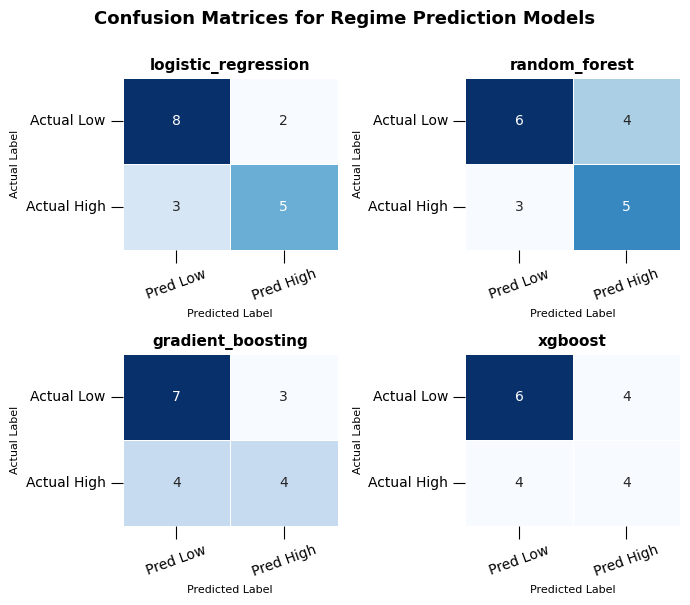

In [985]:
# ============================================================
# PLOT CONFUSION MATRICES FOR ALL MODELS IN ONE FIGURE
# ============================================================

model_names = regime_prediction_eval["Model_Name"].unique()

n_models = len(model_names)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7, 3 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, model_name in enumerate(model_names):

    ax = axes[i]

    valid_group = regime_prediction_eval[
        regime_prediction_eval["Model_Name"] == model_name
    ].dropna(
        subset=["Actual_Label", "Predicted_Label"]
    ).copy()

    y_true = valid_group["Actual_Label"].astype(int)
    y_pred = valid_group["Predicted_Label"].astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

    cm_df = pd.DataFrame(
        cm,
        index=["Actual Low", "Actual High"],
        columns=["Pred Low", "Pred High"]
    )

    sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        ax=ax
    )

    ax.set_title(
        f"{model_name}",
        fontsize=11,
        weight="bold",
        color="black"
    )

    ax.set_xlabel("Predicted Label", color="black", size=8)
    ax.set_ylabel("Actual Label", color="black", size=8)
    ax.tick_params(axis="x", colors="black", rotation=20, size=9)
    ax.tick_params(axis="y", colors="black", rotation=0, size=9)

# Remove empty subplots if number of models is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Confusion Matrices for Regime Prediction Models",
    fontsize=13,
    weight="bold",
    color="black",
    y=1
)

plt.tight_layout()
plt.show()

#### 8.11 Select final model for portfolio backtest

In [1033]:
# ============================================================
# SELECT FINAL REGIME MODEL
# ============================================================

BEST_MODEL_NAME = "logistic_regression"

print(f"Best model based on regime classification accuracy: {BEST_MODEL_NAME}")

regime_prediction_df = (
    regime_prediction_eval[
        regime_prediction_eval["Model_Name"] == BEST_MODEL_NAME
    ]
    .copy()
    .reset_index(drop=True)
)

display(regime_prediction_df.head())

Best model based on regime classification accuracy: logistic_regression


,Rebalance_Date,Model_Name,Predicted_Label,Predicted_Regime,High_Risk_Probability,Training_Quarters,Vol_Threshold,Status,Next_Period_Market_Vol,Actual_Label,Actual_Regime
0,2015-01-01,logistic_regression,0,Low_Risk,0.131697,16,0.129998,OK,0.140751,1.0,High_Risk
1,2015-04-01,logistic_regression,0,Low_Risk,0.411412,17,0.132550,OK,0.099169,0.0,Low_Risk
2,2015-07-01,logistic_regression,1,High_Risk,0.605714,18,0.129998,OK,0.204252,1.0,High_Risk
3,2015-10-01,logistic_regression,1,High_Risk,0.524155,19,0.132550,OK,0.151324,1.0,High_Risk
4,2016-01-01,logistic_regression,1,High_Risk,0.669039,20,0.134431,OK,0.207237,1.0,High_Risk


#### 8.12 Check final prediction distribution

In [987]:
# ============================================================
# CHECK FINAL MODEL PREDICTIONS
# ============================================================

print("Final selected model:", BEST_MODEL_NAME)

print("\nPredicted regime distribution:")
display(regime_prediction_df["Predicted_Regime"].value_counts())

print("\nPrediction status:")
display(regime_prediction_df["Status"].value_counts())

print("\nHigh-risk probability summary:")
display(regime_prediction_df["High_Risk_Probability"].describe())

Final selected model: logistic_regression

Predicted regime distribution:


Predicted_Regime
Low_Risk     11
High_Risk     7
Name: count, dtype: int64


Prediction status:


Status
OK    18
Name: count, dtype: int64


High-risk probability summary:


count    18.000000
mean      0.402500
std       0.241520
min       0.073936
25%       0.210725
50%       0.338256
75%       0.585324
max       0.841423
Name: High_Risk_Probability, dtype: float64

### **9. Portfolio Optimisation**

Select an optimization method based on the predicted regime and calculate weights.

- Calculate the expected return; 
- Estimate the covariance matrix; 
- High-risk → Minimum Variance; 
- Low-risk → Constrained Max Sharpe; 
- If optimization fails → Equal Weight fallback.

#### 9.1 Estimate expected returns

In [988]:
def estimate_expected_returns(return_window, trading_days=TRADING_DAYS):
    """
    Estimate annualised expected returns from daily returns.

    Parameters
    ----------
    return_window : pd.DataFrame
        Lookback daily returns of selected stocks.
    trading_days : int
        Number of trading days per year.

    Returns
    -------
    expected_returns : pd.Series
        Annualised expected return for each stock.
    """

    expected_returns = return_window.apply(
        calculate_annualised_return,
        trading_days=trading_days
    )

    return expected_returns

In [989]:
def estimate_robust_expected_returns(
    return_window,
    trading_days=TRADING_DAYS,
    shrinkage_strength=0.50
):
    """
    Estimate robust annualised expected returns.

    Logic
    -----
    1. Calculate historical annualised return for each stock.
    2. Shrink each stock's return toward the cross-sectional median.
    3. This reduces the effect of extreme historical winners/losers.

    Parameters
    ----------
    return_window : pd.DataFrame
        Daily return data for selected stocks.
    trading_days : int
        Number of trading days per year.
    shrinkage_strength : float
        Shrinkage intensity between 0 and 1.
        0 = no shrinkage.
        1 = all returns shrink to the median.

    Returns
    -------
    robust_expected_returns : pd.Series
        Robust annualised expected returns indexed by stock.
    """

    # Remove stocks with all missing returns
    return_window = return_window.dropna(axis=1, how="all")

    if return_window.shape[1] == 0:
        return pd.Series(dtype=float)

    # Historical annualised return
    historical_returns = return_window.mean(skipna=True) * trading_days

    # Cross-sectional median return
    median_return = historical_returns.median()

    # Shrink returns toward median
    robust_expected_returns = (
        (1 - shrinkage_strength) * historical_returns
        + shrinkage_strength * median_return
    )

    return robust_expected_returns

#### 9.2 Estimate covariance matrix
 
Use Ledoit-Wolf shrinkage covariance

In [990]:
def estimate_covariance_matrix(return_window, method="ledoit_wolf", trading_days=TRADING_DAYS):
    """
    Estimate annualised covariance matrix.

    Parameters
    ----------
    return_window : pd.DataFrame
        Lookback daily returns of selected stocks.
    method : str
        Covariance estimation method: "ledoit_wolf" or "sample".
    trading_days : int
        Number of trading days per year.

    Returns
    -------
    covariance_matrix : pd.DataFrame
        Annualised covariance matrix.
    """

    clean_returns = return_window.dropna(axis=0, how="any")

    if clean_returns.empty:
        return pd.DataFrame(
            np.eye(return_window.shape[1]) * 1e-6,
            index=return_window.columns,
            columns=return_window.columns
        )

    if method == "ledoit_wolf":
        lw = LedoitWolf()
        cov = lw.fit(clean_returns).covariance_

        covariance_matrix = pd.DataFrame(
            cov * trading_days,
            index=return_window.columns,
            columns=return_window.columns
        )

    elif method == "sample":
        covariance_matrix = clean_returns.cov() * trading_days

    else:
        raise ValueError("method must be either 'ledoit_wolf' or 'sample'.")

    return covariance_matrix

#### 9.3 Equal-weight fallback

In [991]:
def equal_weight_weights(n_assets):
    """
    Generate equal weights.

    Parameters
    ----------
    n_assets : int
        Number of assets.

    Returns
    -------
    weights : np.ndarray
        Equal-weight portfolio weights.
    """

    if n_assets == 0:
        return np.array([])

    return np.repeat(1 / n_assets, n_assets)

#### 9.4 Minimum variance weights

In [992]:
def min_variance_weights(covariance_matrix, max_weight=MAX_WEIGHT):
    """
    Calculate long-only constrained minimum variance portfolio weights.

    Parameters
    ----------
    covariance_matrix : pd.DataFrame
        Annualised covariance matrix.
    max_weight : float
        Maximum weight per stock.

    Returns
    -------
    weights : np.ndarray
        Optimised portfolio weights.
    """

    cov = covariance_matrix.values
    n_assets = cov.shape[0]

    if n_assets == 0:
        return np.array([])

    # If max_weight is infeasible, relax it to equal-weight level
    if max_weight * n_assets < 1:
        max_weight = 1 / n_assets

    def portfolio_variance(weights):
        return weights.T @ cov @ weights

    constraints = (
        {
            "type": "eq",
            "fun": lambda weights: np.sum(weights) - 1
        },
    )

    bounds = tuple((0, max_weight) for _ in range(n_assets))

    initial_weights = equal_weight_weights(n_assets)

    result = minimize(
        portfolio_variance,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if not result.success:
        return initial_weights

    return result.x

#### 9.5 Max Sharpe weights

In [993]:
def max_sharpe_weights(
    expected_returns,
    covariance_matrix,
    rf_rate=RF_DAILY,
    max_weight=MAX_WEIGHT
):
    """
    Calculate long-only constrained maximum Sharpe portfolio weights.

    Parameters
    ----------
    expected_returns : pd.Series
        Annualised expected returns.
    covariance_matrix : pd.DataFrame
        Annualised covariance matrix.
    rf_rate : float
        Annualised risk-free rate.
    max_weight : float
        Maximum weight per stock.

    Returns
    -------
    weights : np.ndarray
        Optimised portfolio weights.
    """

    mu = expected_returns.values
    cov = covariance_matrix.values
    n_assets = len(mu)

    if n_assets == 0:
        return np.array([])

    # If max_weight is infeasible, relax it to equal-weight level
    if max_weight * n_assets < 1:
        max_weight = 1 / n_assets

    def negative_sharpe(weights):
        portfolio_return = weights @ mu
        portfolio_vol = np.sqrt(weights.T @ cov @ weights)

        if portfolio_vol == 0 or np.isnan(portfolio_vol):
            return 1e6

        sharpe = (portfolio_return - rf_rate) / portfolio_vol

        return -sharpe

    constraints = (
        {
            "type": "eq",
            "fun": lambda weights: np.sum(weights) - 1
        },
    )

    bounds = tuple((0, max_weight) for _ in range(n_assets))

    initial_weights = equal_weight_weights(n_assets)

    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if not result.success:
        return initial_weights

    return result.x

robust max sharpe weights

In [994]:
def robust_max_sharpe_weights(
    return_window,
    rf_daily=RF_DAILY,
    max_weight=MAX_WEIGHT,
    covariance_method="ledoit_wolf",
    trading_days=TRADING_DAYS,
    shrinkage_strength=0.50
):
    """
    Calculate robust long-only constrained Max Sharpe weights.

    Robustness comes from:
    1. expected return shrinkage toward cross-sectional median;
    2. Ledoit-Wolf covariance shrinkage;
    3. long-only constraints;
    4. maximum weight constraint;
    5. equal-weight fallback if optimisation fails.
    """

    return_window = return_window.dropna(axis=1, how="all")

    stocks = return_window.columns.tolist()
    n_assets = len(stocks)

    if n_assets == 0:
        return np.array([])

    if n_assets == 1:
        return np.array([1.0])

    # If max_weight is infeasible, relax it to equal-weight level
    if max_weight * n_assets < 1:
        max_weight = 1 / n_assets

    expected_returns = estimate_robust_expected_returns(
        return_window=return_window,
        trading_days=trading_days,
        shrinkage_strength=shrinkage_strength
    )

    covariance_matrix = estimate_covariance_matrix(
        return_window=return_window,
        method=covariance_method,
        trading_days=trading_days
    )

    # Align expected returns and covariance matrix just in case
    common_stocks = expected_returns.index.intersection(covariance_matrix.index)

    expected_returns = expected_returns.loc[common_stocks]
    covariance_matrix = covariance_matrix.loc[common_stocks, common_stocks]

    mu = expected_returns.values
    cov = covariance_matrix.values

    n_assets = len(common_stocks)

    if n_assets == 0:
        return np.array([])

    if n_assets == 1:
        return np.array([1.0])

    initial_weights = equal_weight_weights(n_assets)

    rf_annual = (1 + rf_daily) ** trading_days - 1

    def negative_sharpe(weights):
        portfolio_return = weights @ mu
        portfolio_vol = np.sqrt(weights.T @ cov @ weights)

        if portfolio_vol <= 0 or np.isnan(portfolio_vol):
            return 1e6

        sharpe = (portfolio_return - rf_annual) / portfolio_vol

        return -sharpe

    constraints = (
        {
            "type": "eq",
            "fun": lambda weights: np.sum(weights) - 1
        },
    )

    bounds = tuple((0, max_weight) for _ in range(n_assets))

    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if not result.success:
        return initial_weights

    weights = result.x

    weights = np.clip(weights, 0, None)

    if weights.sum() > 0:
        weights = weights / weights.sum()
    else:
        weights = initial_weights

    return weights

#### 9.6 Main optimisation function by regime

In [995]:
HIGH_RISK_EQUITY_EXPOSURE = 0.85

def optimise_portfolio_by_regime(
    selected_return_window,
    predicted_regime,
    rf_daily=RF_DAILY,
    max_weight=MAX_WEIGHT,
    covariance_method="ledoit_wolf",
    trading_days=TRADING_DAYS,
    low_risk_ew_weight=0.50,
    high_risk_ew_weight=0.30,
    high_risk_equity_exposure=HIGH_RISK_EQUITY_EXPOSURE,
    shrinkage_strength=0.60
):
    """
    Optimise portfolio weights based on predicted market regime using a blended approach.

    Logic
    -----
    High_Risk:
        Blend Equal Weight with Minimum Variance, then reduce total equity exposure.
        Example: 75% equity exposure means 25% is held as cash.

    Low_Risk:
        Blend Equal Weight with Robust Max Sharpe and stay fully invested.

    Notes
    -----
    In High_Risk regimes, weights are intentionally allowed to sum to less than 1.
    The uninvested portion is treated as cash with zero return.
    """

    selected_return_window = selected_return_window.dropna(axis=1, how="all")

    stocks = selected_return_window.columns.tolist()
    n_assets = len(stocks)

    if n_assets == 0:
        return pd.Series(dtype=float), "No Assets", "Failed: no selected assets"

    covariance_matrix = estimate_covariance_matrix(
        selected_return_window,
        method=covariance_method,
        trading_days=trading_days
    )

    try:
        ew_weights = equal_weight_weights(n_assets)

        if predicted_regime == "High_Risk":
            opt_weights = min_variance_weights(
                covariance_matrix=covariance_matrix,
                max_weight=max_weight
            )

            # Stock-only allocation, still sums to 1 before exposure scaling
            stock_weight_array = (
                high_risk_ew_weight * ew_weights
                + (1 - high_risk_ew_weight) * opt_weights
            )

            # Reduce total equity exposure in high-risk regimes
            weight_array = stock_weight_array * high_risk_equity_exposure

            weighting_method = (
                f"Blended EW + MinVar "
                f"with {int(high_risk_equity_exposure * 100)}% Equity Exposure"
            )

        elif predicted_regime == "Low_Risk":
            opt_weights = robust_max_sharpe_weights(
                return_window=selected_return_window,
                rf_daily=rf_daily,
                max_weight=max_weight,
                covariance_method=covariance_method,
                trading_days=trading_days,
                shrinkage_strength=shrinkage_strength
            )

            weight_array = (
                low_risk_ew_weight * ew_weights
                + (1 - low_risk_ew_weight) * opt_weights
            )

            weighting_method = "Blended Equal Weight + Robust Max Sharpe"

        else:
            weight_array = ew_weights
            weighting_method = "Equal Weight"

        optimisation_status = "OK"

    except Exception as e:
        weight_array = equal_weight_weights(n_assets)
        weighting_method = "Equal Weight Fallback"
        optimisation_status = f"Fallback: {str(e)}"

    weights = pd.Series(
        weight_array,
        index=stocks,
        name="Weight"
    )

    weights = weights.clip(lower=0)
    weights[weights < 1e-10] = 0

    # ------------------------------------------------------------
    # Normalisation rule
    # ------------------------------------------------------------
    # Low_Risk and fallback portfolios should be fully invested.
    # High_Risk portfolios are allowed to sum to less than 1 because
    # the remaining allocation is treated as cash.
    # ------------------------------------------------------------
    if weights.sum() > 0:

        if predicted_regime == "High_Risk":
            # Do not normalise back to 1.
            # Keep the reduced equity exposure.
            current_sum = weights.sum()

            if current_sum > high_risk_equity_exposure:
                weights = weights / current_sum * high_risk_equity_exposure

        else:
            # Fully invested in Low_Risk and neutral cases
            weights = weights / weights.sum()

    else:
        weights = pd.Series(
            equal_weight_weights(n_assets),
            index=stocks,
            name="Weight"
        )

    return weights, weighting_method, optimisation_status

#### 9.7 Test Part 9 on one rebalance date

In [996]:
# ============================================================
# TEST PART 9 ON ONE REBALANCE DATE
# ============================================================

test_rebalance_date = rebalance_schedule.loc[0, "Rebalance_Date"]

# Get selected stocks for this date
test_selected_stocks = selected_stocks_history[
    selected_stocks_history["Rebalance_Date"] == test_rebalance_date
]["Stock"].tolist()

# Get lookback return window
eligible_stocks, price_window, return_window, eligibility_info = get_eligible_universe(
    price_df=df_price_full,
    return_df=df_return_full,
    rebalance_date=test_rebalance_date,
    lookback_days=LOOKBACK_DAYS,
    min_valid_ratio=MIN_VALID_RATIO,
    min_avg_price=MIN_AVG_PRICE
)

selected_return_window = return_window[test_selected_stocks].copy()

# Get predicted regime from selected best model
test_predicted_regime = regime_prediction_df[
    regime_prediction_df["Rebalance_Date"] == test_rebalance_date
]["Predicted_Regime"].iloc[0]

weights, weighting_method, optimisation_status = optimise_portfolio_by_regime(
    selected_return_window=selected_return_window,
    predicted_regime=test_predicted_regime,
    rf_daily=RF_DAILY,
    max_weight=MAX_WEIGHT,
    covariance_method="ledoit_wolf",
    trading_days=TRADING_DAYS
)

print("Test rebalance date:", test_rebalance_date.date())
print("Predicted regime    :", test_predicted_regime)
print("Weighting method    :", weighting_method)
print("Optimisation status :", optimisation_status)

display(
    weights.sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "Stock", "Weight": "Weight"})
)

Test rebalance date: 2015-01-01
Predicted regime    : Low_Risk
Weighting method    : Blended Equal Weight + Robust Max Sharpe
Optimisation status : OK


,Stock,Weight
0,FNMA US Equity,0.141667
1,MTW US Equity,0.141667
2,NBR US Equity,0.141667
3,FSLR US Equity,0.141667
4,NFLX US Equity,0.141667
5,ANF US Equity,0.041667
6,GME US Equity,0.041667
7,GNW US Equity,0.041667
8,RIG US Equity,0.041667
9,AMD US Equity,0.041667


In [997]:
# Check weight constraints

print("Weight sum:", weights.sum())
print("Max weight:", weights.max())
print("Min weight:", weights.min())
print("Number of stocks:", (weights > 0).sum())

Weight sum: 1.0
Max weight: 0.14166666666666658
Min weight: 0.041666666666666664
Number of stocks: 12


#### 9.8 Build dynamic weights for all rebalance dates

In [998]:
# ============================================================
# BUILD DYNAMIC PORTFOLIO WEIGHTS FOR ALL REBALANCE DATES
# ============================================================

weight_records = []
optimisation_log_records = []

for rebalance_date in rebalance_schedule["Rebalance_Date"]:

    # Selected stocks for current rebalance date
    selected_stocks = selected_stocks_history[
        selected_stocks_history["Rebalance_Date"] == rebalance_date
    ]["Stock"].tolist()

    if len(selected_stocks) == 0:
        continue

    # Get current lookback return window
    eligible_stocks, price_window, return_window, eligibility_info = get_eligible_universe(
        price_df=df_price_full,
        return_df=df_return_full,
        rebalance_date=rebalance_date,
        lookback_days=LOOKBACK_DAYS,
        min_valid_ratio=MIN_VALID_RATIO,
        min_avg_price=MIN_AVG_PRICE
    )

    selected_stocks = [
        stock for stock in selected_stocks
        if stock in return_window.columns
    ]

    selected_return_window = return_window[selected_stocks].copy()

    # Get predicted regime
    regime_row = regime_prediction_df[
        regime_prediction_df["Rebalance_Date"] == rebalance_date
    ]

    if regime_row.empty:
        predicted_regime = "Low_Risk"
        high_risk_probability = np.nan
        model_name = "Missing_Regime_Fallback"
    else:
        predicted_regime = regime_row["Predicted_Regime"].iloc[0]
        high_risk_probability = regime_row["High_Risk_Probability"].iloc[0]
        model_name = regime_row["Model_Name"].iloc[0]

    weights, weighting_method, optimisation_status = optimise_portfolio_by_regime(
        selected_return_window=selected_return_window,
        predicted_regime=predicted_regime,
        rf_daily=RF_DAILY,
        max_weight=MAX_WEIGHT,
        covariance_method="ledoit_wolf",
        trading_days=TRADING_DAYS
    )

    # Save weights
    for stock, weight in weights.items():
        weight_records.append({
            "Rebalance_Date": pd.to_datetime(rebalance_date),
            "Stock": stock,
            "Weight": weight,
            "Predicted_Regime": predicted_regime,
            "High_Risk_Probability": high_risk_probability,
            "Model_Name": model_name,
            "Weighting_Method": weighting_method
        })

    # Save optimisation log
    optimisation_log_records.append({
        "Rebalance_Date": pd.to_datetime(rebalance_date),
        "Predicted_Regime": predicted_regime,
        "High_Risk_Probability": high_risk_probability,
        "Model_Name": model_name,
        "Number_of_Selected_Stocks": len(selected_stocks),
        "Number_of_Weighted_Stocks": len(weights),
        "Weighting_Method": weighting_method,
        "Max_Weight": weights.max() if len(weights) > 0 else np.nan,
        "Min_Weight": weights.min() if len(weights) > 0 else np.nan,
        "Weight_Sum": weights.sum() if len(weights) > 0 else np.nan,
        "Optimisation_Status": optimisation_status
    })

dynamic_weights = pd.DataFrame(weight_records)
optimisation_log = pd.DataFrame(optimisation_log_records)

# Display-friendly rounded weight
dynamic_weights["Weight_Display"] = dynamic_weights["Weight"].round(6)

# Optional: display-friendly log columns
optimisation_log["Max_Weight_Display"] = optimisation_log["Max_Weight"].round(6)
optimisation_log["Min_Weight_Display"] = optimisation_log["Min_Weight"].round(6)
optimisation_log["Weight_Sum_Display"] = optimisation_log["Weight_Sum"].round(6)

print("Dynamic portfolio weights created.")
print(f"Dynamic weights shape   : {dynamic_weights.shape}")
print(f"Optimisation log shape  : {optimisation_log.shape}")

display(
    dynamic_weights[
        [
            "Rebalance_Date",
            "Stock",
            "Weight_Display",
            "Predicted_Regime",
            "High_Risk_Probability",
            "Model_Name",
            "Weighting_Method"
        ]
    ].head(15)
)

display(
    optimisation_log[
        [
            "Rebalance_Date",
            "Predicted_Regime",
            "Model_Name",
            "Number_of_Selected_Stocks",
            "Number_of_Weighted_Stocks",
            "Weighting_Method",
            "Max_Weight_Display",
            "Min_Weight_Display",
            "Weight_Sum_Display",
            "Optimisation_Status"
        ]
    ].head()
)

Dynamic portfolio weights created.
Dynamic weights shape   : (216, 8)
Optimisation log shape  : (18, 14)


,Rebalance_Date,Stock,Weight_Display,Predicted_Regime,High_Risk_Probability,Model_Name,Weighting_Method
0,2015-01-01,GNW US Equity,0.041667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
1,2015-01-01,FNMA US Equity,0.141667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
2,2015-01-01,MTW US Equity,0.141667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
3,2015-01-01,RIG US Equity,0.041667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
4,2015-01-01,NBR US Equity,0.141667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
5,2015-01-01,ANF US Equity,0.041667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
6,2015-01-01,AMD US Equity,0.041667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
7,2015-01-01,CLF US Equity,0.041667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
8,2015-01-01,FSLR US Equity,0.141667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
9,2015-01-01,GME US Equity,0.041667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe


,Rebalance_Date,Predicted_Regime,Model_Name,Number_of_Selected_Stocks,Number_of_Weighted_Stocks,Weighting_Method,Max_Weight_Display,Min_Weight_Display,Weight_Sum_Display,Optimisation_Status
0,2015-01-01,Low_Risk,logistic_regression,12,12,Blended Equal Weight + Robust Max Sharpe,0.141667,0.041667,1.00,OK
1,2015-04-01,Low_Risk,logistic_regression,12,12,Blended Equal Weight + Robust Max Sharpe,0.141667,0.041667,1.00,OK
2,2015-07-01,High_Risk,logistic_regression,12,12,Blended EW + MinVar with 85% Equity Exposure,0.124913,0.021250,0.85,OK
3,2015-10-01,High_Risk,logistic_regression,12,12,Blended EW + MinVar with 85% Equity Exposure,0.140250,0.021250,0.85,OK
4,2016-01-01,High_Risk,logistic_regression,12,12,Blended EW + MinVar with 85% Equity Exposure,0.133435,0.021250,0.85,OK


#### 9.9 Check optimisation results

In [999]:
# ============================================================
# CHECK OPTIMISATION RESULTS
# ============================================================

print("Optimisation status distribution:")
display(optimisation_log["Optimisation_Status"].value_counts())

print("\nWeighting method distribution:")
display(optimisation_log["Weighting_Method"].value_counts())

print("\nWeight summary:")
display(
    optimisation_log[
        ["Number_of_Weighted_Stocks", "Max_Weight_Display", "Min_Weight_Display", "Weight_Sum_Display"]
    ].describe()
)

Optimisation status distribution:


Optimisation_Status
OK    18
Name: count, dtype: int64


Weighting method distribution:


Weighting_Method
Blended Equal Weight + Robust Max Sharpe        11
Blended EW + MinVar with 85% Equity Exposure     7
Name: count, dtype: int64


Weight summary:


,Number_of_Weighted_Stocks,Max_Weight_Display,Min_Weight_Display,Weight_Sum_Display
count,18.0,18.000000,18.000000,18.000000
mean,12.0,0.138840,0.033727,0.941667
std,0.0,0.006048,0.010242,0.075245
min,12.0,0.121437,0.021250,0.850000
25%,12.0,0.140250,0.021250,0.850000
50%,12.0,0.141667,0.041667,1.000000
75%,12.0,0.141667,0.041667,1.000000
max,12.0,0.141667,0.041667,1.000000


#### 9.10 View weights as matrix

In [1000]:
# ============================================================
# WEIGHT MATRIX
# ============================================================

weight_matrix = dynamic_weights.pivot(
    index="Rebalance_Date",
    columns="Stock",
    values="Weight"
).fillna(0)

display(weight_matrix.head())

print("Weight matrix shape:", weight_matrix.shape)

Stock,AA US Equity,ABX US Equity,ADNT US Equity,AKAM US Equity,ALGN US Equity,AMD US Equity,ANF US Equity,ATI US Equity,BIIB US Equity,CAR US Equity,...,TRIP US Equity,TSCO US Equity,UA US Equity,UAA US Equity,UIS US Equity,VREX US Equity,WDC US Equity,WMB US Equity,WOR US Equity,WYNN US Equity
Rebalance_Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,0.0,0.041667,0.0,0.0,0.0,0.041667,0.041667,0.000000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000,0.000000,0.000000
2015-04-01,0.0,0.000000,0.0,0.0,0.0,0.141667,0.041667,0.000000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000,0.041667,0.000000
2015-07-01,0.0,0.000000,0.0,0.0,0.0,0.060583,0.074379,0.000000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.086096,0.0,0.0,0.00000,0.000000,0.113171
2015-10-01,0.0,0.000000,0.0,0.0,0.0,0.081235,0.000000,0.048883,0.14025,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.00000,0.000000,0.128633
2016-01-01,0.0,0.083522,0.0,0.0,0.0,0.000000,0.000000,0.030045,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.03226,0.000000,0.000000


Weight matrix shape: (18, 72)


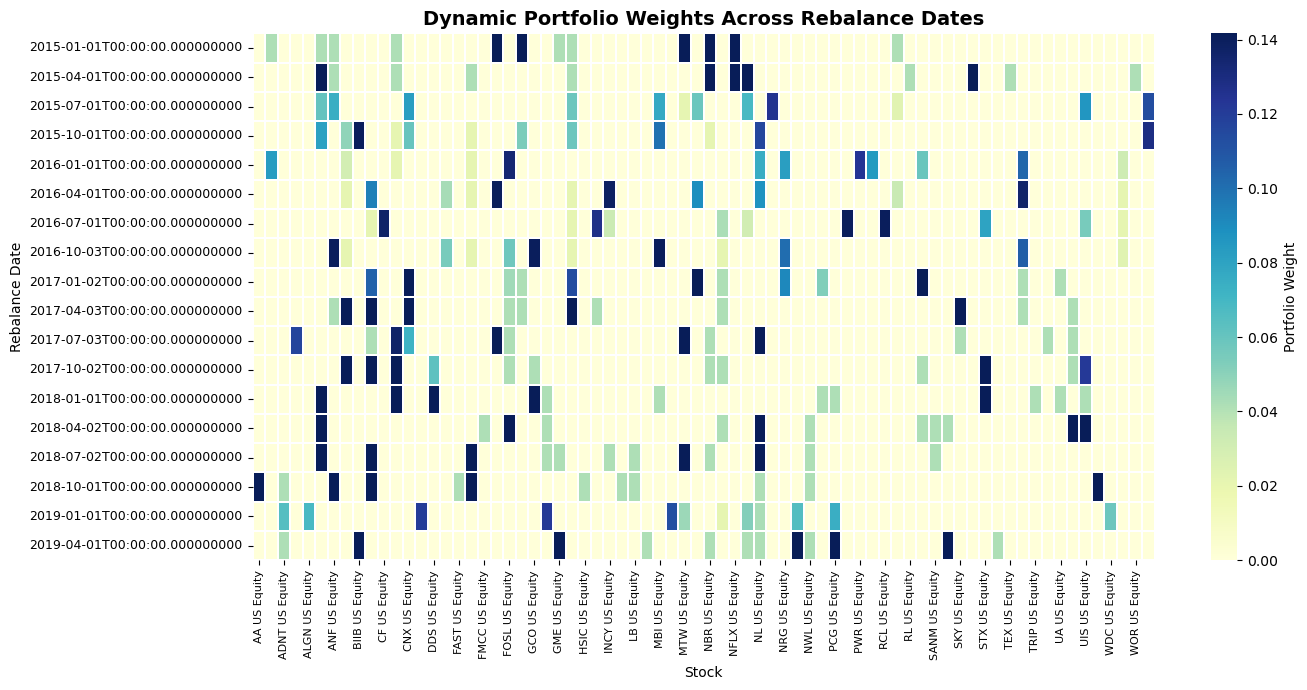

In [1001]:
# Quick weight heatmap
plt.figure(figsize=(14, 7))

sns.heatmap(
    weight_matrix,
    cmap="YlGnBu",
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "Portfolio Weight"}
)

plt.title(
    "Dynamic Portfolio Weights Across Rebalance Dates",
    fontsize=14,
    weight="bold",
    color="black"
)

plt.xlabel("Stock", color="black")
plt.ylabel("Rebalance Date", color="black")

plt.xticks(rotation=90, fontsize=8, color="black")
plt.yticks(rotation=0, fontsize=9, color="black")

plt.tight_layout()
plt.show()

In [1002]:
# ============================================================
# QUICK CHECK — ONE REBALANCE DATE RESULT
# ============================================================

# Choose one rebalance date to inspect
check_date = optimisation_log["Rebalance_Date"].iloc[0]

print("=" * 70)
print(f"Quick check for rebalance date: {check_date.date()}")
print("=" * 70)

# Regime and optimisation summary
check_log = optimisation_log[
    optimisation_log["Rebalance_Date"] == check_date
]

display(check_log)

# Selected stocks and weights
check_weights = dynamic_weights[
    dynamic_weights["Rebalance_Date"] == check_date
].copy()

check_weights = check_weights.sort_values("Weight", ascending=False)

# Use display-friendly weight if available
if "Weight_Display" not in check_weights.columns:
    check_weights["Weight_Display"] = check_weights["Weight"].where(
        check_weights["Weight"].abs() >= 1e-8,
        0
    ).round(6)

display(
    check_weights[
        [
            "Stock",
            "Weight_Display",
            "Predicted_Regime",
            "High_Risk_Probability",
            "Model_Name",
            "Weighting_Method"
        ]
    ]
)

print("\nWeight checks:")
print(f"Number of weighted stocks : {len(check_weights)}")
print(f"Weight sum                : {check_weights['Weight'].sum():.6f}")
print(f"Max weight                : {check_weights['Weight'].max():.6f}")
print(f"Min weight                : {check_weights['Weight'].min():.6f}")

Quick check for rebalance date: 2015-01-01


,Rebalance_Date,Predicted_Regime,High_Risk_Probability,Model_Name,Number_of_Selected_Stocks,Number_of_Weighted_Stocks,Weighting_Method,Max_Weight,Min_Weight,Weight_Sum,Optimisation_Status,Max_Weight_Display,Min_Weight_Display,Weight_Sum_Display
0,2015-01-01,Low_Risk,0.131697,logistic_regression,12,12,Blended Equal Weight + Robust Max Sharpe,0.141667,0.041667,1.0,OK,0.141667,0.041667,1.0


,Stock,Weight_Display,Predicted_Regime,High_Risk_Probability,Model_Name,Weighting_Method
1,FNMA US Equity,0.141667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
2,MTW US Equity,0.141667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
4,NBR US Equity,0.141667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
8,FSLR US Equity,0.141667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
11,NFLX US Equity,0.141667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
5,ANF US Equity,0.041667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
9,GME US Equity,0.041667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
0,GNW US Equity,0.041667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
3,RIG US Equity,0.041667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe
6,AMD US Equity,0.041667,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe



Weight checks:
Number of weighted stocks : 12
Weight sum                : 1.000000
Max weight                : 0.141667
Min weight                : 0.041667


### **10. Dynamic Backtesting, Turnover & Evaluation**

For each rebalance date:

- Retrieve lookback window;
- Find eligible universe;
- Generate regime features;
- Calculate stock features;
- Stock selection;
- Model prediction;
- Portfolio optimization;
- Calculate turnover;
- Deduct transaction cost;
- Record holding period return;
- Save logs.

#### 10.1 Calculate holding-period portfolio returns

In [1003]:
def calculate_holding_period_portfolio_returns(holding_returns, weights):
    """
    Calculate daily portfolio returns during one holding period.

    Parameters
    ----------
    holding_returns : pd.DataFrame
        Daily returns of portfolio stocks during the holding period.
    weights : pd.Series
        Portfolio weights indexed by stock.
    
    Missing daily returns are filled with 0, assuming no price change
    on days where a stock return is missing.

    Returns
    -------
    portfolio_returns : pd.Series
        Daily portfolio returns.
    """

    # Keep only stocks that exist in both holding returns and weights
    common_stocks = [
        stock for stock in weights.index
        if stock in holding_returns.columns
    ]

    if len(common_stocks) == 0:
        return pd.Series(dtype=float)

    holding_returns = holding_returns[common_stocks].copy()
    weights = weights[common_stocks].copy()

    # Re-normalise in case some stocks are missing in holding period
    weights = weights / weights.sum()

    holding_returns = holding_returns.fillna(0)

    portfolio_returns = holding_returns.dot(weights)

    return portfolio_returns

#### 10.2 Calculate drifted weights

In [1004]:
def calculate_drifted_weights(previous_weights, holding_returns):
    """
    Calculate drifted portfolio weights after market movement.

    Parameters
    ----------
    previous_weights : pd.Series
        Portfolio weights at the beginning of the holding period.
    holding_returns : pd.DataFrame
        Daily stock returns during the holding period.
    Missing daily returns are filled with 0.

    Returns
    -------
    drifted_weights : pd.Series
        Portfolio weights at the end of the holding period before rebalancing.
    """

    if previous_weights is None or len(previous_weights) == 0:
        return pd.Series(dtype=float)

    common_stocks = [
        stock for stock in previous_weights.index
        if stock in holding_returns.columns
    ]

    if len(common_stocks) == 0:
        return pd.Series(dtype=float)

    weights = previous_weights[common_stocks].copy()
    returns = holding_returns[common_stocks].copy().fillna(0)

    # Cumulative return for each stock during holding period
    stock_growth = (1 + returns).prod(axis=0)

    # End-of-period value weight
    end_values = weights * stock_growth

    if end_values.sum() == 0:
        return weights / weights.sum()

    drifted_weights = end_values / end_values.sum()

    return drifted_weights

#### 10.3 Calculate turnover

In [1005]:
def calculate_turnover(new_weights, drifted_old_weights):
    """
    Calculate single-sided portfolio turnover.

    Parameters
    ----------
    new_weights : pd.Series
        New target portfolio weights.
    drifted_old_weights : pd.Series
        Previous portfolio weights after market drift.

    Returns
    -------
    turnover : float
        Single-sided turnover.
    """

    if drifted_old_weights is None or len(drifted_old_weights) == 0:
        # First rebalance: assume starting from cash
        return 1.0

    all_stocks = sorted(
        list(set(new_weights.index) | set(drifted_old_weights.index))
    )

    new_aligned = new_weights.reindex(all_stocks).fillna(0)
    old_aligned = drifted_old_weights.reindex(all_stocks).fillna(0)

    turnover = 0.5 * np.abs(new_aligned - old_aligned).sum()

    return turnover

#### 10.4 Apply transaction cost

In [1006]:
def apply_transaction_cost(portfolio_returns, turnover, cost_rate=TRANSACTION_COST_RATE):
    """
    Deduct transaction cost from the first day of holding-period returns.

    Parameters
    ----------
    portfolio_returns : pd.Series
        Gross daily portfolio returns.
    turnover : float
        Single-sided turnover.
    cost_rate : float
        Transaction cost rate.

    Returns
    -------
    net_returns : pd.Series
        Net daily portfolio returns after transaction cost.
    transaction_cost : float
        Transaction cost deducted.
    """

    net_returns = portfolio_returns.copy()

    transaction_cost = turnover * cost_rate

    if len(net_returns) > 0:
        net_returns.iloc[0] = net_returns.iloc[0] - transaction_cost

    return net_returns, transaction_cost

#### 10.5 Main dynamic backtest function

In [1007]:
def run_dynamic_backtest(
    return_df,
    rebalance_schedule,
    dynamic_weights,
    transaction_cost_rate=TRANSACTION_COST_RATE
):
    """
    Run dynamic portfolio backtest using pre-computed weights.

    Parameters
    ----------
    return_df : pd.DataFrame
        Full daily return data.
    rebalance_schedule : pd.DataFrame
        Rebalance schedule with holding start and end dates.
    dynamic_weights : pd.DataFrame
        Portfolio weights for each rebalance date.
    transaction_cost_rate : float
        Transaction cost rate.

    Returns
    -------
    dynamic_returns : pd.Series
        Gross daily portfolio returns.
    dynamic_net_returns : pd.Series
        Net daily portfolio returns after transaction cost.
    backtest_log : pd.DataFrame
        Backtest period-level log.
    turnover_log : pd.DataFrame
        Turnover and transaction cost log.
    """

    all_gross_returns = []
    all_net_returns = []

    backtest_log_records = []
    turnover_log_records = []

    previous_weights = None
    previous_holding_returns = None

    for _, row in rebalance_schedule.iterrows():

        rebalance_date = pd.to_datetime(row["Rebalance_Date"])
        holding_start = pd.to_datetime(row["Holding_Start_Date"])
        holding_end = pd.to_datetime(row["Holding_End_Date"])

        # Get weights for current rebalance date
        current_weight_df = dynamic_weights[
            dynamic_weights["Rebalance_Date"] == rebalance_date
        ].copy()

        if current_weight_df.empty:
            continue

        current_weights = current_weight_df.set_index("Stock")["Weight"]
        current_weights = current_weights[current_weights > 0]

        current_weights = current_weights / current_weights.sum()

        selected_stocks = current_weights.index.tolist()

        # Holding-period returns
        holding_returns = return_df.loc[
            (return_df.index >= holding_start) &
            (return_df.index <= holding_end),
            selected_stocks
        ].copy()

        if holding_returns.empty:
            continue

        # Calculate gross returns
        gross_portfolio_returns = calculate_holding_period_portfolio_returns(
            holding_returns=holding_returns,
            weights=current_weights
        )

        # Calculate drifted old weights
        if previous_weights is None or previous_holding_returns is None:
            drifted_old_weights = pd.Series(dtype=float)
        else:
            drifted_old_weights = calculate_drifted_weights(
                previous_weights=previous_weights,
                holding_returns=previous_holding_returns
            )

        # Calculate turnover
        turnover = calculate_turnover(
            new_weights=current_weights,
            drifted_old_weights=drifted_old_weights
        )

        # Apply transaction cost
        net_portfolio_returns, transaction_cost = apply_transaction_cost(
            portfolio_returns=gross_portfolio_returns,
            turnover=turnover,
            cost_rate=transaction_cost_rate
        )

        # Store daily returns
        all_gross_returns.append(gross_portfolio_returns)
        all_net_returns.append(net_portfolio_returns)

        # Period return
        gross_period_return = (1 + gross_portfolio_returns).prod() - 1
        net_period_return = (1 + net_portfolio_returns).prod() - 1

        # Get metadata
        predicted_regime = current_weight_df["Predicted_Regime"].iloc[0]
        weighting_method = current_weight_df["Weighting_Method"].iloc[0]
        model_name = current_weight_df["Model_Name"].iloc[0]
        high_risk_probability = current_weight_df["High_Risk_Probability"].iloc[0]

        backtest_log_records.append({
            "Rebalance_Date": rebalance_date,
            "Holding_Start_Date": holding_start,
            "Holding_End_Date": holding_end,
            "Predicted_Regime": predicted_regime,
            "High_Risk_Probability": high_risk_probability,
            "Model_Name": model_name,
            "Weighting_Method": weighting_method,
            "Number_of_Stocks": len(current_weights),
            "Gross_Period_Return": gross_period_return,
            "Net_Period_Return": net_period_return
        })

        turnover_log_records.append({
            "Rebalance_Date": rebalance_date,
            "Holding_Start_Date": holding_start,
            "Holding_End_Date": holding_end,
            "Turnover": turnover,
            "Transaction_Cost": transaction_cost,
            "Transaction_Cost_Rate": transaction_cost_rate
        })

        # Update previous weights and returns for next period turnover calculation
        previous_weights = current_weights.copy()
        previous_holding_returns = holding_returns.copy()

    dynamic_returns = pd.concat(all_gross_returns).sort_index()
    dynamic_net_returns = pd.concat(all_net_returns).sort_index()

    backtest_log = pd.DataFrame(backtest_log_records)
    turnover_log = pd.DataFrame(turnover_log_records)

    return dynamic_returns, dynamic_net_returns, backtest_log, turnover_log

#### 10.6 Run dynamic backtest

In [1008]:
# ============================================================
# RUN DYNAMIC BACKTEST
# ============================================================

dynamic_returns, dynamic_net_returns, backtest_log, turnover_log = run_dynamic_backtest(
    return_df=df_return_full,
    rebalance_schedule=rebalance_schedule,
    dynamic_weights=dynamic_weights,
    transaction_cost_rate=TRANSACTION_COST_RATE
)

print("Dynamic backtest completed.")
print(f"Gross return series length: {len(dynamic_returns)}")
print(f"Net return series length  : {len(dynamic_net_returns)}")

display(backtest_log.head())
display(turnover_log.head())

Dynamic backtest completed.
Gross return series length: 1154
Net return series length  : 1154


,Rebalance_Date,Holding_Start_Date,Holding_End_Date,Predicted_Regime,High_Risk_Probability,Model_Name,Weighting_Method,Number_of_Stocks,Gross_Period_Return,Net_Period_Return
0,2015-01-01,2015-01-02,2015-03-31,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe,12,0.086394,0.085312
1,2015-04-01,2015-04-02,2015-06-30,Low_Risk,0.411412,logistic_regression,Blended Equal Weight + Robust Max Sharpe,12,0.076159,0.075526
2,2015-07-01,2015-07-02,2015-09-30,High_Risk,0.605714,logistic_regression,Blended EW + MinVar with 85% Equity Exposure,12,-0.267094,-0.267655
3,2015-10-01,2015-10-02,2015-12-31,High_Risk,0.524155,logistic_regression,Blended EW + MinVar with 85% Equity Exposure,12,0.118576,0.117950
4,2016-01-01,2016-01-04,2016-03-31,High_Risk,0.669039,logistic_regression,Blended EW + MinVar with 85% Equity Exposure,12,0.188131,0.187116


,Rebalance_Date,Holding_Start_Date,Holding_End_Date,Turnover,Transaction_Cost,Transaction_Cost_Rate
0,2015-01-01,2015-01-02,2015-03-31,1.000000,0.001000,0.001
1,2015-04-01,2015-04-02,2015-06-30,0.590749,0.000591,0.001
2,2015-07-01,2015-07-02,2015-09-30,0.769756,0.000770,0.001
3,2015-10-01,2015-10-02,2015-12-31,0.602408,0.000602,0.001
4,2016-01-01,2016-01-04,2016-03-31,0.845663,0.000846,0.001


#### 10.7 Quick check

In [1009]:
# ============================================================
# QUICK CHECK — DYNAMIC RETURNS
# ============================================================

print("Gross dynamic returns:")
display(dynamic_returns.describe())

print("\nNet dynamic returns:")
display(dynamic_net_returns.describe())

print("\nDate range:")
print(f"Gross returns: {dynamic_returns.index.min().date()} to {dynamic_returns.index.max().date()}")
print(f"Net returns  : {dynamic_net_returns.index.min().date()} to {dynamic_net_returns.index.max().date()}")

Gross dynamic returns:


count    1154.000000
mean        0.001039
std         0.017924
min        -0.068741
25%        -0.009084
50%         0.000501
75%         0.011564
max         0.080767
dtype: float64


Net dynamic returns:


count    1154.000000
mean        0.001027
std         0.017921
min        -0.068741
25%        -0.009084
50%         0.000274
75%         0.011564
max         0.080767
dtype: float64


Date range:
Gross returns: 2015-01-02 to 2019-06-28
Net returns  : 2015-01-02 to 2019-06-28


In [1010]:
# ============================================================
# CHECK BACKTEST LOG
# ============================================================

display(backtest_log)

print("Backtest period return summary:")
display(
    backtest_log[
        [
            "Gross_Period_Return",
            "Net_Period_Return",
            "Number_of_Stocks"
        ]
    ].describe()
)

print("\nRegime distribution:")
display(backtest_log["Predicted_Regime"].value_counts())

print("\nWeighting method distribution:")
display(backtest_log["Weighting_Method"].value_counts())

,Rebalance_Date,Holding_Start_Date,Holding_End_Date,Predicted_Regime,High_Risk_Probability,Model_Name,Weighting_Method,Number_of_Stocks,Gross_Period_Return,Net_Period_Return
0,2015-01-01,2015-01-02,2015-03-31,Low_Risk,0.131697,logistic_regression,Blended Equal Weight + Robust Max Sharpe,12,0.086394,0.085312
1,2015-04-01,2015-04-02,2015-06-30,Low_Risk,0.411412,logistic_regression,Blended Equal Weight + Robust Max Sharpe,12,0.076159,0.075526
2,2015-07-01,2015-07-02,2015-09-30,High_Risk,0.605714,logistic_regression,Blended EW + MinVar with 85% Equity Exposure,12,-0.267094,-0.267655
3,2015-10-01,2015-10-02,2015-12-31,High_Risk,0.524155,logistic_regression,Blended EW + MinVar with 85% Equity Exposure,12,0.118576,0.117950
4,2016-01-01,2016-01-04,2016-03-31,High_Risk,0.669039,logistic_regression,Blended EW + MinVar with 85% Equity Exposure,12,0.188131,0.187116
5,2016-04-01,2016-04-04,2016-06-30,High_Risk,0.706689,logistic_regression,Blended EW + MinVar with 85% Equity Exposure,12,0.199139,0.198192
6,2016-07-01,2016-07-04,2016-09-30,High_Risk,0.782053,logistic_regression,Blended EW + MinVar with 85% Equity Exposure,12,0.179060,0.178011
7,2016-10-03,2016-10-04,2016-12-30,High_Risk,0.514408,logistic_regression,Blended EW + MinVar with 85% Equity Exposure,12,0.013655,0.012722
8,2017-01-02,2017-01-03,2017-03-31,Low_Risk,0.172696,logistic_regression,Blended Equal Weight + Robust Max Sharpe,12,0.011092,0.010308
9,2017-04-03,2017-04-04,2017-06-30,Low_Risk,0.314364,logistic_regression,Blended Equal Weight + Robust Max Sharpe,12,-0.070806,-0.071295


Backtest period return summary:


,Gross_Period_Return,Net_Period_Return,Number_of_Stocks
count,18.000000,18.000000,18.0
mean,0.071462,0.070652,12.0
std,0.171082,0.170912,0.0
min,-0.267094,-0.267655,12.0
25%,-0.001878,-0.002561,12.0
50%,0.081276,0.080419,12.0
75%,0.185863,0.184840,12.0
max,0.426981,0.425848,12.0



Regime distribution:


Predicted_Regime
Low_Risk     11
High_Risk     7
Name: count, dtype: int64


Weighting method distribution:


Weighting_Method
Blended Equal Weight + Robust Max Sharpe        11
Blended EW + MinVar with 85% Equity Exposure     7
Name: count, dtype: int64

In [1011]:
# ============================================================
# CHECK TURNOVER AND TRANSACTION COST
# ============================================================

display(turnover_log)

print("Turnover summary:")
display(turnover_log["Turnover"].describe())

print("\nTransaction cost summary:")
display(turnover_log["Transaction_Cost"].describe())

print("\nTotal transaction cost:")
print(turnover_log["Transaction_Cost"].sum())

,Rebalance_Date,Holding_Start_Date,Holding_End_Date,Turnover,Transaction_Cost,Transaction_Cost_Rate
0,2015-01-01,2015-01-02,2015-03-31,1.000000,0.001000,0.001
1,2015-04-01,2015-04-02,2015-06-30,0.590749,0.000591,0.001
2,2015-07-01,2015-07-02,2015-09-30,0.769756,0.000770,0.001
3,2015-10-01,2015-10-02,2015-12-31,0.602408,0.000602,0.001
4,2016-01-01,2016-01-04,2016-03-31,0.845663,0.000846,0.001
5,2016-04-01,2016-04-04,2016-06-30,0.774732,0.000775,0.001
6,2016-07-01,2016-07-04,2016-09-30,0.890324,0.000890,0.001
7,2016-10-03,2016-10-04,2016-12-30,0.921488,0.000921,0.001
8,2017-01-02,2017-01-03,2017-03-31,0.779088,0.000779,0.001
9,2017-04-03,2017-04-04,2017-06-30,0.521124,0.000521,0.001


Turnover summary:


count    18.000000
mean      0.754571
std       0.136932
min       0.521124
25%       0.650682
50%       0.772244
75%       0.835498
max       1.000000
Name: Turnover, dtype: float64


Transaction cost summary:


count    18.000000
mean      0.000755
std       0.000137
min       0.000521
25%       0.000651
50%       0.000772
75%       0.000835
max       0.001000
Name: Transaction_Cost, dtype: float64


Total transaction cost:
0.013582273735705435


#### 10.8 Build cumulative wealth

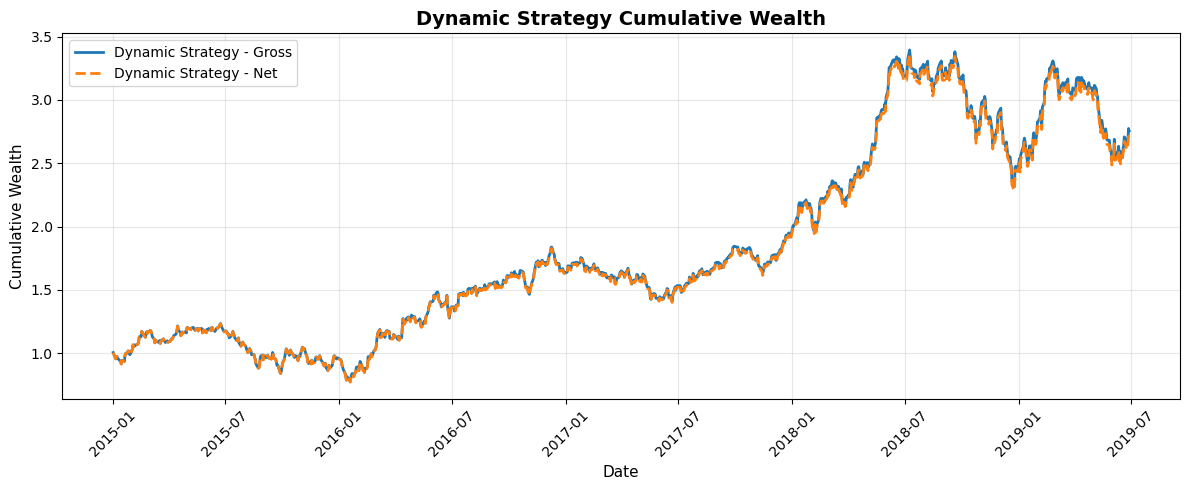

In [1012]:
# ============================================================
# CUMULATIVE WEALTH
# ============================================================

dynamic_cum_wealth = (1 + dynamic_returns).cumprod()
dynamic_net_cum_wealth = (1 + dynamic_net_returns).cumprod()

plt.figure(figsize=(12, 5))

plt.plot(
    dynamic_cum_wealth.index,
    dynamic_cum_wealth,
    linewidth=2,
    label="Dynamic Strategy - Gross"
)

plt.plot(
    dynamic_net_cum_wealth.index,
    dynamic_net_cum_wealth,
    linewidth=2,
    linestyle="--",
    label="Dynamic Strategy - Net"
)

plt.title(
    "Dynamic Strategy Cumulative Wealth",
    fontsize=14,
    weight="bold",
    color="black"
)

plt.xlabel("Date", fontsize=11, color="black")
plt.ylabel("Cumulative Wealth", fontsize=11, color="black")

plt.legend()
plt.grid(True, alpha=0.3)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, color="black")
plt.yticks(color="black")

plt.tight_layout()
plt.show()

In [1013]:
# Quick performance metrics
def calculate_performance_metrics(return_series, trading_days=252):
    """
    Calculate basic performance metrics for a daily return series.
    """

    return_series = return_series.dropna()

    if len(return_series) == 0:
        return {}

    cumulative_return = (1 + return_series).prod() - 1

    annualised_return = (1 + cumulative_return) ** (trading_days / len(return_series)) - 1

    annualised_volatility = return_series.std() * np.sqrt(trading_days)

    sharpe_ratio = (
        annualised_return / annualised_volatility
        if annualised_volatility != 0
        else np.nan
    )

    cumulative_wealth = (1 + return_series).cumprod()
    running_max = cumulative_wealth.cummax()
    drawdown = cumulative_wealth / running_max - 1
    max_drawdown = drawdown.min()

    return {
        "Cumulative_Return": cumulative_return,
        "Annualised_Return": annualised_return,
        "Annualised_Volatility": annualised_volatility,
        "Sharpe_Ratio": sharpe_ratio,
        "Max_Drawdown": max_drawdown
    }

# ============================================================
# QUICK PERFORMANCE SUMMARY
# ============================================================

dynamic_gross_metrics = calculate_performance_metrics(dynamic_returns)
dynamic_net_metrics = calculate_performance_metrics(dynamic_net_returns)

dynamic_performance_summary = pd.DataFrame([
    {
        "Strategy": "Dynamic Gross",
        **dynamic_gross_metrics
    },
    {
        "Strategy": "Dynamic Net",
        **dynamic_net_metrics
    }
])

display(dynamic_performance_summary)

,Strategy,Cumulative_Return,Annualised_Return,Annualised_Volatility,Sharpe_Ratio,Max_Drawdown
0,Dynamic Gross,1.755579,0.247756,0.284537,0.870733,-0.372275
1,Dynamic Net,1.718621,0.244082,0.284483,0.857987,-0.373643


The dynamic strategy produced a positive net cumulative return of approximately 58.6% over the backtest period, equivalent to an annualised return of around 11.1%. After transaction costs, the Sharpe ratio decreased slightly from 0.67 to 0.64, indicating that trading costs reduced but did not eliminate the strategy’s risk-adjusted performance. The maximum drawdown was approximately -21.0%, suggesting that the strategy still experienced meaningful downside risk during adverse market conditions. Therefore, benchmark comparison is required to assess whether the dynamic model-based approach provides improvement over simpler allocation methods.

In [1014]:
# ============================================================
# SANITY CHECKS
# ============================================================

print("Any missing returns?")
print("Gross:", dynamic_returns.isna().sum())
print("Net  :", dynamic_net_returns.isna().sum())

print("\nAny extreme daily returns?")
print("Gross max:", dynamic_returns.max())
print("Gross min:", dynamic_returns.min())
print("Net max  :", dynamic_net_returns.max())
print("Net min  :", dynamic_net_returns.min())

print("\nWeight sum by rebalance date:")
display(
    dynamic_weights
    .groupby("Rebalance_Date")["Weight"]
    .sum()
    .round(6)
    .reset_index(name="Weight_Sum")
)

Any missing returns?
Gross: 0
Net  : 0

Any extreme daily returns?
Gross max: 0.08076730954474444
Gross min: -0.06874100716820244
Net max  : 0.08076730954474444
Net min  : -0.06874100716820244

Weight sum by rebalance date:


,Rebalance_Date,Weight_Sum
0,2015-01-01,1.00
1,2015-04-01,1.00
2,2015-07-01,0.85
3,2015-10-01,0.85
4,2016-01-01,0.85
5,2016-04-01,0.85
6,2016-07-01,0.85
7,2016-10-03,0.85
8,2017-01-02,1.00
9,2017-04-03,1.00


### **11. (Optional) Benchmark Strategies**

#### 11.1 Equal-weight benchmark using same selected stocks

In [1015]:
def run_equal_weight_selected_benchmark(
    return_df,
    rebalance_schedule,
    selected_stocks_history,
    transaction_cost_rate=TRANSACTION_COST_RATE
):
    """
    Run an equal-weight benchmark using the same selected stocks
    as the dynamic strategy.

    This benchmark tests whether regime-based optimisation adds value
    beyond the stock selection step.
    """

    all_gross_returns = []
    all_net_returns = []

    benchmark_log_records = []
    turnover_log_records = []

    previous_weights = None
    previous_holding_returns = None

    for _, row in rebalance_schedule.iterrows():

        rebalance_date = pd.to_datetime(row["Rebalance_Date"])
        holding_start = pd.to_datetime(row["Holding_Start_Date"])
        holding_end = pd.to_datetime(row["Holding_End_Date"])

        selected_stocks = selected_stocks_history[
            selected_stocks_history["Rebalance_Date"] == rebalance_date
        ]["Stock"].tolist()

        selected_stocks = [
            stock for stock in selected_stocks
            if stock in return_df.columns
        ]

        if len(selected_stocks) == 0:
            continue

        # Equal weights
        current_weights = pd.Series(
            equal_weight_weights(len(selected_stocks)),
            index=selected_stocks
        )

        holding_returns = return_df.loc[
            (return_df.index >= holding_start) &
            (return_df.index <= holding_end),
            selected_stocks
        ].copy()

        if holding_returns.empty:
            continue

        gross_returns = calculate_holding_period_portfolio_returns(
            holding_returns=holding_returns,
            weights=current_weights
        )

        # Turnover
        if previous_weights is None or previous_holding_returns is None:
            drifted_old_weights = pd.Series(dtype=float)
        else:
            drifted_old_weights = calculate_drifted_weights(
                previous_weights=previous_weights,
                holding_returns=previous_holding_returns
            )

        turnover = calculate_turnover(
            new_weights=current_weights,
            drifted_old_weights=drifted_old_weights
        )

        net_returns, transaction_cost = apply_transaction_cost(
            portfolio_returns=gross_returns,
            turnover=turnover,
            cost_rate=transaction_cost_rate
        )

        all_gross_returns.append(gross_returns)
        all_net_returns.append(net_returns)

        gross_period_return = (1 + gross_returns).prod() - 1
        net_period_return = (1 + net_returns).prod() - 1

        benchmark_log_records.append({
            "Rebalance_Date": rebalance_date,
            "Holding_Start_Date": holding_start,
            "Holding_End_Date": holding_end,
            "Benchmark": "Equal Weight Selected Stocks",
            "Number_of_Stocks": len(current_weights),
            "Gross_Period_Return": gross_period_return,
            "Net_Period_Return": net_period_return
        })

        turnover_log_records.append({
            "Rebalance_Date": rebalance_date,
            "Benchmark": "Equal Weight Selected Stocks",
            "Turnover": turnover,
            "Transaction_Cost": transaction_cost
        })

        previous_weights = current_weights.copy()
        previous_holding_returns = holding_returns.copy()

    benchmark_returns = pd.concat(all_gross_returns).sort_index()
    benchmark_net_returns = pd.concat(all_net_returns).sort_index()

    benchmark_log = pd.DataFrame(benchmark_log_records)
    benchmark_turnover_log = pd.DataFrame(turnover_log_records)

    return benchmark_returns, benchmark_net_returns, benchmark_log, benchmark_turnover_log

#### 11.2 Run selected-stocks equal weight benchmark

In [1016]:
# ============================================================
# RUN EQUAL-WEIGHT SELECTED STOCKS BENCHMARK
# ============================================================

ew_selected_returns, ew_selected_net_returns, ew_selected_log, ew_selected_turnover_log = (
    run_equal_weight_selected_benchmark(
        return_df=df_return_full,
        rebalance_schedule=rebalance_schedule,
        selected_stocks_history=selected_stocks_history,
        transaction_cost_rate=TRANSACTION_COST_RATE
    )
)

print("Equal-weight selected stocks benchmark completed.")
print(f"Gross return series length: {len(ew_selected_returns)}")
print(f"Net return series length  : {len(ew_selected_net_returns)}")

display(ew_selected_log.head())
display(ew_selected_turnover_log.head())

Equal-weight selected stocks benchmark completed.
Gross return series length: 1154
Net return series length  : 1154


,Rebalance_Date,Holding_Start_Date,Holding_End_Date,Benchmark,Number_of_Stocks,Gross_Period_Return,Net_Period_Return
0,2015-01-01,2015-01-02,2015-03-31,Equal Weight Selected Stocks,12,0.012097,0.011087
1,2015-04-01,2015-04-02,2015-06-30,Equal Weight Selected Stocks,12,0.047752,0.047172
2,2015-07-01,2015-07-02,2015-09-30,Equal Weight Selected Stocks,12,-0.246480,-0.246993
3,2015-10-01,2015-10-02,2015-12-31,Equal Weight Selected Stocks,12,0.031806,0.031169
4,2016-01-01,2016-01-04,2016-03-31,Equal Weight Selected Stocks,12,0.253813,0.252876


,Rebalance_Date,Benchmark,Turnover,Transaction_Cost
0,2015-01-01,Equal Weight Selected Stocks,1.000000,0.001000
1,2015-04-01,Equal Weight Selected Stocks,0.558160,0.000558
2,2015-07-01,Equal Weight Selected Stocks,0.684387,0.000684
3,2015-10-01,Equal Weight Selected Stocks,0.661246,0.000661
4,2016-01-01,Equal Weight Selected Stocks,0.747543,0.000748


#### 11.3 Market equal-weight benchmark

In [1017]:
def run_equal_weight_market_benchmark(
    return_df,
    price_df,
    rebalance_schedule,
    lookback_days=LOOKBACK_DAYS,
    min_valid_ratio=MIN_VALID_RATIO,
    min_avg_price=MIN_AVG_PRICE,
    transaction_cost_rate=TRANSACTION_COST_RATE
):
    """
    Run an equal-weight market benchmark using all eligible stocks
    at each rebalance date.

    This benchmark represents a broad investable market proxy.
    """

    all_gross_returns = []
    all_net_returns = []

    benchmark_log_records = []
    turnover_log_records = []

    previous_weights = None
    previous_holding_returns = None

    for _, row in rebalance_schedule.iterrows():

        rebalance_date = pd.to_datetime(row["Rebalance_Date"])
        holding_start = pd.to_datetime(row["Holding_Start_Date"])
        holding_end = pd.to_datetime(row["Holding_End_Date"])

        eligible_stocks, price_window, return_window, eligibility_info = get_eligible_universe(
            price_df=price_df,
            return_df=return_df,
            rebalance_date=rebalance_date,
            lookback_days=lookback_days,
            min_valid_ratio=min_valid_ratio,
            min_avg_price=min_avg_price
        )

        eligible_stocks = [
            stock for stock in eligible_stocks
            if stock in return_df.columns
        ]

        if len(eligible_stocks) == 0:
            continue

        current_weights = pd.Series(
            equal_weight_weights(len(eligible_stocks)),
            index=eligible_stocks
        )

        holding_returns = return_df.loc[
            (return_df.index >= holding_start) &
            (return_df.index <= holding_end),
            eligible_stocks
        ].copy()

        if holding_returns.empty:
            continue

        gross_returns = calculate_holding_period_portfolio_returns(
            holding_returns=holding_returns,
            weights=current_weights
        )

        if previous_weights is None or previous_holding_returns is None:
            drifted_old_weights = pd.Series(dtype=float)
        else:
            drifted_old_weights = calculate_drifted_weights(
                previous_weights=previous_weights,
                holding_returns=previous_holding_returns
            )

        turnover = calculate_turnover(
            new_weights=current_weights,
            drifted_old_weights=drifted_old_weights
        )

        net_returns, transaction_cost = apply_transaction_cost(
            portfolio_returns=gross_returns,
            turnover=turnover,
            cost_rate=transaction_cost_rate
        )

        all_gross_returns.append(gross_returns)
        all_net_returns.append(net_returns)

        gross_period_return = (1 + gross_returns).prod() - 1
        net_period_return = (1 + net_returns).prod() - 1

        benchmark_log_records.append({
            "Rebalance_Date": rebalance_date,
            "Holding_Start_Date": holding_start,
            "Holding_End_Date": holding_end,
            "Benchmark": "Equal Weight Eligible Market",
            "Number_of_Stocks": len(current_weights),
            "Gross_Period_Return": gross_period_return,
            "Net_Period_Return": net_period_return
        })

        turnover_log_records.append({
            "Rebalance_Date": rebalance_date,
            "Benchmark": "Equal Weight Eligible Market",
            "Turnover": turnover,
            "Transaction_Cost": transaction_cost
        })

        previous_weights = current_weights.copy()
        previous_holding_returns = holding_returns.copy()

    benchmark_returns = pd.concat(all_gross_returns).sort_index()
    benchmark_net_returns = pd.concat(all_net_returns).sort_index()

    benchmark_log = pd.DataFrame(benchmark_log_records)
    benchmark_turnover_log = pd.DataFrame(turnover_log_records)

    return benchmark_returns, benchmark_net_returns, benchmark_log, benchmark_turnover_log

#### 11.4 Run market benchmark

In [1018]:
# ============================================================
# RUN EQUAL-WEIGHT ELIGIBLE MARKET BENCHMARK
# ============================================================

ew_market_returns, ew_market_net_returns, ew_market_log, ew_market_turnover_log = (
    run_equal_weight_market_benchmark(
        return_df=df_return_full,
        price_df=df_price_full,
        rebalance_schedule=rebalance_schedule,
        lookback_days=LOOKBACK_DAYS,
        min_valid_ratio=MIN_VALID_RATIO,
        min_avg_price=MIN_AVG_PRICE,
        transaction_cost_rate=TRANSACTION_COST_RATE
    )
)

print("Equal-weight eligible market benchmark completed.")
print(f"Gross return series length: {len(ew_market_returns)}")
print(f"Net return series length  : {len(ew_market_net_returns)}")

display(ew_market_log.head())
display(ew_market_turnover_log.head())

Equal-weight eligible market benchmark completed.
Gross return series length: 1154
Net return series length  : 1154


,Rebalance_Date,Holding_Start_Date,Holding_End_Date,Benchmark,Number_of_Stocks,Gross_Period_Return,Net_Period_Return
0,2015-01-01,2015-01-02,2015-03-31,Equal Weight Eligible Market,478,0.026943,0.025916
1,2015-04-01,2015-04-02,2015-06-30,Equal Weight Eligible Market,481,-0.004446,-0.004490
2,2015-07-01,2015-07-02,2015-09-30,Equal Weight Eligible Market,482,-0.081081,-0.081116
3,2015-10-01,2015-10-02,2015-12-31,Equal Weight Eligible Market,483,0.050607,0.050550
4,2016-01-01,2016-01-04,2016-03-31,Equal Weight Eligible Market,484,0.045411,0.045363


,Rebalance_Date,Benchmark,Turnover,Transaction_Cost
0,2015-01-01,Equal Weight Eligible Market,1.000000,0.001000
1,2015-04-01,Equal Weight Eligible Market,0.044021,0.000044
2,2015-07-01,Equal Weight Eligible Market,0.038641,0.000039
3,2015-10-01,Equal Weight Eligible Market,0.054788,0.000055
4,2016-01-01,Equal Weight Eligible Market,0.045063,0.000045


#### 11.5 Combine all strategy returns

In [1019]:
# ============================================================
# COMBINE STRATEGY RETURNS
# ============================================================

strategy_returns = {
    "Dynamic Model-Based Net": dynamic_net_returns,
    "Equal Weight Selected Net": ew_selected_net_returns,
    "Equal Weight Market Net": ew_market_net_returns
}

strategy_returns_df = pd.concat(strategy_returns, axis=1)

# Remove rows where all strategies are missing
strategy_returns_df = strategy_returns_df.dropna(how="all")

display(strategy_returns_df.head())
display(strategy_returns_df.tail())

print("Combined strategy returns shape:", strategy_returns_df.shape)

,Dynamic Model-Based Net,Equal Weight Selected Net,Equal Weight Market Net
Date,,,
2015-01-02,0.003814,0.000961,-0.001302
2015-01-05,-0.035322,-0.030344,-0.017700
2015-01-06,-0.014467,-0.012232,-0.009872
2015-01-07,0.012387,0.008453,0.012434
2015-01-08,0.008353,0.010715,0.017520


,Dynamic Model-Based Net,Equal Weight Selected Net,Equal Weight Market Net
Date,,,
2019-06-24,-0.021836,-0.023104,-0.004966
2019-06-25,0.000898,0.001156,-0.007016
2019-06-26,0.018979,0.020652,-0.001040
2019-06-27,0.028601,0.024008,0.007678
2019-06-28,-0.006804,-0.001046,0.009772


Combined strategy returns shape: (1154, 3)


#### 11.6 Performance comparison

In [1020]:
# ============================================================
# PERFORMANCE COMPARISON
# ============================================================

performance_records = []

for strategy_name in strategy_returns_df.columns:

    metrics = calculate_performance_metrics(
        strategy_returns_df[strategy_name]
    )

    performance_records.append({
        "Strategy": strategy_name,
        **metrics
    })

performance_comparison = pd.DataFrame(performance_records)

display(performance_comparison)

,Strategy,Cumulative_Return,Annualised_Return,Annualised_Volatility,Sharpe_Ratio,Max_Drawdown
0,Dynamic Model-Based Net,1.718621,0.244082,0.284483,0.857987,-0.373643
1,Equal Weight Selected Net,1.108089,0.176868,0.296366,0.596790,-0.430310
2,Equal Weight Market Net,0.562135,0.102307,0.138389,0.739269,-0.220076


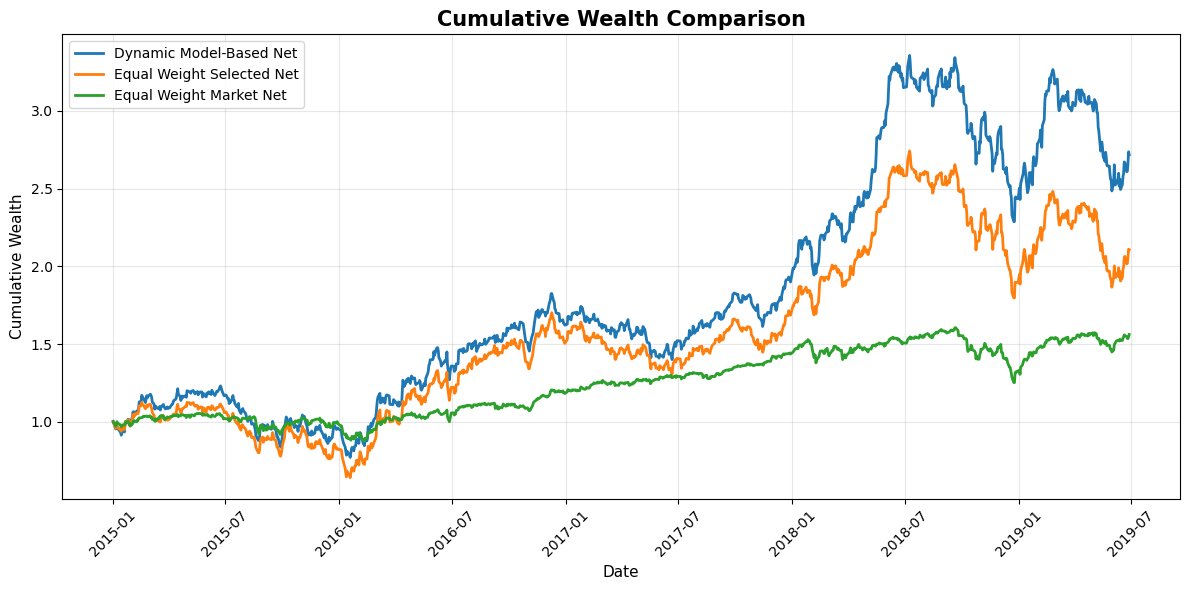

In [1021]:
# ============================================================
# CUMULATIVE WEALTH COMPARISON
# ============================================================

cumulative_wealth_df = (1 + strategy_returns_df.fillna(0)).cumprod()

plt.figure(figsize=(12, 6))

for strategy_name in cumulative_wealth_df.columns:
    plt.plot(
        cumulative_wealth_df.index,
        cumulative_wealth_df[strategy_name],
        linewidth=2,
        label=strategy_name
    )

plt.title(
    "Cumulative Wealth Comparison",
    fontsize=15,
    weight="bold",
    color="black"
)

plt.xlabel("Date", fontsize=11, color="black")
plt.ylabel("Cumulative Wealth", fontsize=11, color="black")

plt.legend()
plt.grid(True, alpha=0.3)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, color="black")
plt.yticks(color="black")

plt.tight_layout()
plt.show()

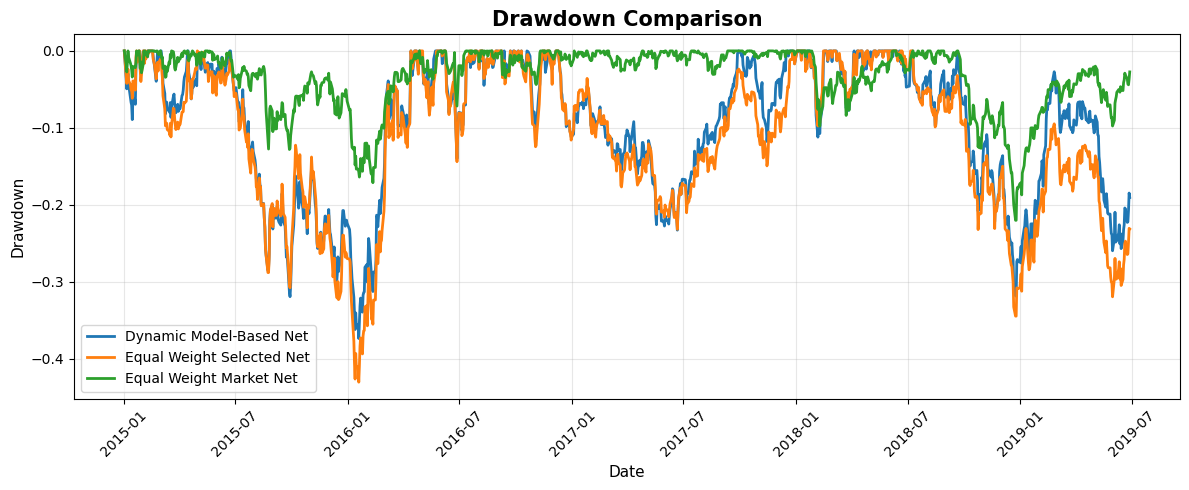

In [1022]:
# ============================================================
# DRAWDOWN COMPARISON
# ============================================================

def calculate_drawdown_series(return_series):
    """
    Calculate drawdown series from daily returns.
    """

    wealth = (1 + return_series.dropna()).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1

    return drawdown


drawdown_df = pd.DataFrame()

for strategy_name in strategy_returns_df.columns:
    drawdown_df[strategy_name] = calculate_drawdown_series(
        strategy_returns_df[strategy_name]
    )

plt.figure(figsize=(12, 5))

for strategy_name in drawdown_df.columns:
    plt.plot(
        drawdown_df.index,
        drawdown_df[strategy_name],
        linewidth=2,
        label=strategy_name
    )

plt.title(
    "Drawdown Comparison",
    fontsize=15,
    weight="bold",
    color="black"
)

plt.xlabel("Date", fontsize=11, color="black")
plt.ylabel("Drawdown", fontsize=11, color="black")

plt.legend()
plt.grid(True, alpha=0.3)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, color="black")
plt.yticks(color="black")

plt.tight_layout()
plt.show()

In [1023]:
# ============================================================
# TURNOVER COMPARISON — CLEAN VERSION
# ============================================================

dynamic_turnover_clean = turnover_log.copy()
dynamic_turnover_clean["Strategy"] = "Dynamic Model-Based"

ew_selected_turnover_clean = ew_selected_turnover_log.copy()
ew_selected_turnover_clean["Strategy"] = "Equal Weight Selected"

ew_market_turnover_clean = ew_market_turnover_log.copy()
ew_market_turnover_clean["Strategy"] = "Equal Weight Market"

turnover_comparison = pd.concat([
    dynamic_turnover_clean,
    ew_selected_turnover_clean,
    ew_market_turnover_clean
], ignore_index=True)

# Drop Benchmark column if it exists and causes confusion
if "Benchmark" in turnover_comparison.columns:
    turnover_comparison = turnover_comparison.drop(columns=["Benchmark"])

display(turnover_comparison.head())

turnover_summary = (
    turnover_comparison
    .groupby("Strategy")
    .agg(
        Average_Turnover=("Turnover", "mean"),
        Median_Turnover=("Turnover", "median"),
        Max_Turnover=("Turnover", "max"),
        Total_Transaction_Cost=("Transaction_Cost", "sum")
    )
    .reset_index()
)

display(turnover_summary)

,Rebalance_Date,Holding_Start_Date,Holding_End_Date,Turnover,Transaction_Cost,Transaction_Cost_Rate,Strategy
0,2015-01-01,2015-01-02,2015-03-31,1.000000,0.001000,0.001,Dynamic Model-Based
1,2015-04-01,2015-04-02,2015-06-30,0.590749,0.000591,0.001,Dynamic Model-Based
2,2015-07-01,2015-07-02,2015-09-30,0.769756,0.000770,0.001,Dynamic Model-Based
3,2015-10-01,2015-10-02,2015-12-31,0.602408,0.000602,0.001,Dynamic Model-Based
4,2016-01-01,2016-01-04,2016-03-31,0.845663,0.000846,0.001,Dynamic Model-Based


,Strategy,Average_Turnover,Median_Turnover,Max_Turnover,Total_Transaction_Cost
0,Dynamic Model-Based,0.754571,0.772244,1.0,0.013582
1,Equal Weight Market,0.100237,0.046224,1.0,0.001804
2,Equal Weight Selected,0.692256,0.663184,1.0,0.012461


### **12. Performance Evaluation & Visualisation**

#### 12.1 Final performance metrics function

In [1024]:
def calculate_performance_metrics(return_series, trading_days=TRADING_DAYS):
    """
    Calculate performance metrics for a daily return series.

    Metrics:
    - cumulative return
    - annualised return
    - annualised volatility
    - Sharpe ratio
    - maximum drawdown
    - Calmar ratio
    """

    return_series = return_series.dropna()

    if len(return_series) == 0:
        return {
            "Cumulative_Return": np.nan,
            "Annualised_Return": np.nan,
            "Annualised_Volatility": np.nan,
            "Sharpe_Ratio": np.nan,
            "Max_Drawdown": np.nan,
            "Calmar_Ratio": np.nan
        }

    cumulative_return = (1 + return_series).prod() - 1

    annualised_return = (
        (1 + cumulative_return) ** (trading_days / len(return_series)) - 1
    )

    annualised_volatility = return_series.std() * np.sqrt(trading_days)

    sharpe_ratio = (
        annualised_return / annualised_volatility
        if annualised_volatility != 0
        else np.nan
    )

    wealth = (1 + return_series).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1
    max_drawdown = drawdown.min()

    calmar_ratio = (
        annualised_return / abs(max_drawdown)
        if max_drawdown != 0
        else np.nan
    )

    return {
        "Cumulative_Return": cumulative_return,
        "Annualised_Return": annualised_return,
        "Annualised_Volatility": annualised_volatility,
        "Sharpe_Ratio": sharpe_ratio,
        "Max_Drawdown": max_drawdown,
        "Calmar_Ratio": calmar_ratio
    }

#### 12.2 Build final performance summary table

In [1025]:
# ============================================================
# FINAL PERFORMANCE SUMMARY
# ============================================================

strategy_returns = {
    "Dynamic Model-Based Net": dynamic_net_returns,
    "Equal Weight Selected Net": ew_selected_net_returns,
    "Equal Weight Market Net": ew_market_net_returns
}

strategy_returns_df = pd.concat(strategy_returns, axis=1)
strategy_returns_df = strategy_returns_df.dropna(how="all")

performance_records = []

for strategy_name in strategy_returns_df.columns:
    metrics = calculate_performance_metrics(
        strategy_returns_df[strategy_name],
        trading_days=TRADING_DAYS
    )

    performance_records.append({
        "Strategy": strategy_name,
        **metrics
    })

performance_summary = pd.DataFrame(performance_records)

performance_summary_display = performance_summary.copy()

percentage_cols = [
    "Cumulative_Return",
    "Annualised_Return",
    "Annualised_Volatility",
    "Max_Drawdown"
]

for col in percentage_cols:
    performance_summary_display[col] = (
        performance_summary_display[col] * 100
    ).round(2)

performance_summary_display["Sharpe_Ratio"] = (
    performance_summary_display["Sharpe_Ratio"].round(3)
)

performance_summary_display["Calmar_Ratio"] = (
    performance_summary_display["Calmar_Ratio"].round(3)
)

display(performance_summary_display)

,Strategy,Cumulative_Return,Annualised_Return,Annualised_Volatility,Sharpe_Ratio,Max_Drawdown,Calmar_Ratio
0,Dynamic Model-Based Net,171.86,24.41,28.45,0.858,-37.36,0.653
1,Equal Weight Selected Net,110.81,17.69,29.64,0.597,-43.03,0.411
2,Equal Weight Market Net,56.21,10.23,13.84,0.739,-22.01,0.465


#### Visualization

In [1026]:
# regime shading helper function
def add_regime_background(ax, regime_prediction_df, plot_end_date=None):
    """
    Add background shading based on predicted regimes.

    Parameters
    ----------
    ax : matplotlib axis
        Plot axis.
    regime_prediction_df : pd.DataFrame
        DataFrame with Rebalance_Date and Predicted_Regime.
    plot_end_date : datetime-like, optional
        End date for the final shaded regime block.
    """

    regime_df = regime_prediction_df.copy()
    regime_df = regime_df.sort_values("Rebalance_Date").reset_index(drop=True)

    if plot_end_date is None:
        plot_end_date = mdates.num2date(ax.get_xlim()[1]).replace(tzinfo=None)
    else:
        plot_end_date = pd.to_datetime(plot_end_date)

    high_label_added = False
    low_label_added = False

    for i in range(len(regime_df)):

        start_date = regime_df.loc[i, "Rebalance_Date"]

        if i < len(regime_df) - 1:
            end_date = regime_df.loc[i + 1, "Rebalance_Date"]
        else:
            end_date = plot_end_date

        regime = regime_df.loc[i, "Predicted_Regime"]

        if regime == "High_Risk":
            label = None if high_label_added else "Predicted High Risk"
            high_label_added = True

            ax.axvspan(
                start_date,
                end_date,
                alpha=0.16,
                color="lightcoral",
                label=label
            )

        elif regime == "Low_Risk":
            label = None if low_label_added else "Predicted Low Risk"
            low_label_added = True

            ax.axvspan(
                start_date,
                end_date,
                alpha=0.10,
                color="lightgreen",
                label=label
            )

#### 12.3 Cumulative wealth comparison

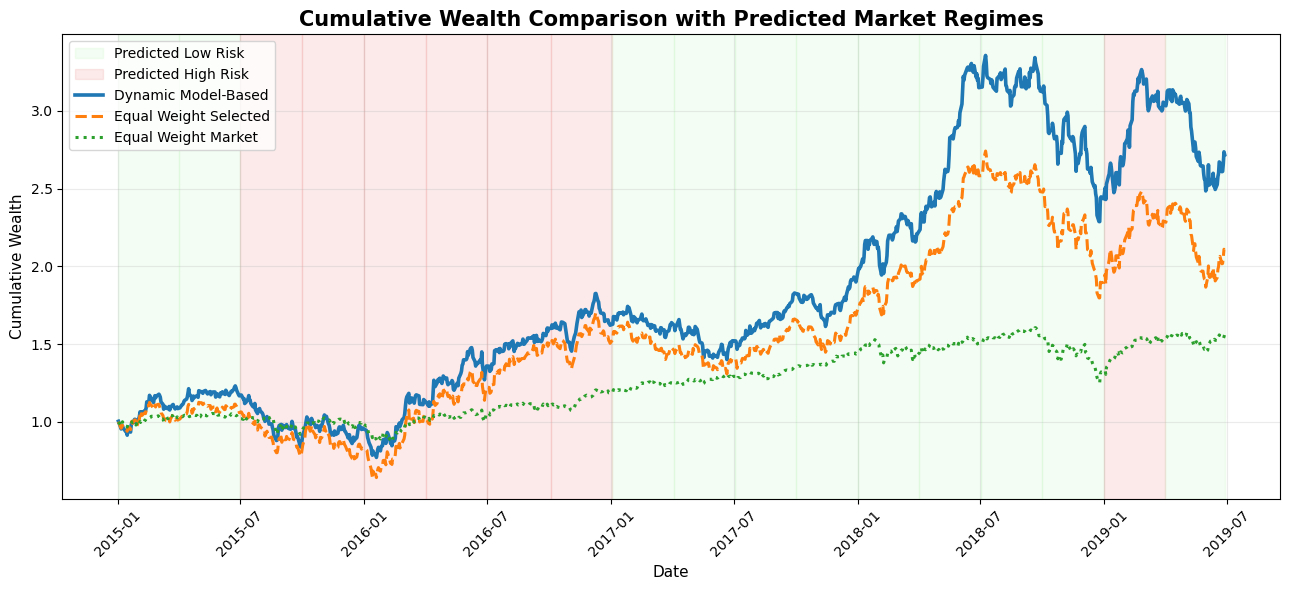

In [1027]:
# ============================================================
# FINAL PLOT — CUMULATIVE WEALTH WITH REGIME BACKGROUND
# ============================================================

cumulative_wealth_df = (1 + strategy_returns_df.fillna(0)).cumprod()

fig, ax = plt.subplots(figsize=(13, 6))

# Add regime background first
add_regime_background(
    ax=ax,
    regime_prediction_df=regime_prediction_df,
    plot_end_date=cumulative_wealth_df.index.max()
)

# Plot strategy lines
ax.plot(
    cumulative_wealth_df.index,
    cumulative_wealth_df["Dynamic Model-Based Net"],
    linewidth=2.6,
    label="Dynamic Model-Based"
)

ax.plot(
    cumulative_wealth_df.index,
    cumulative_wealth_df["Equal Weight Selected Net"],
    linewidth=2.2,
    linestyle="--",
    label="Equal Weight Selected"
)

ax.plot(
    cumulative_wealth_df.index,
    cumulative_wealth_df["Equal Weight Market Net"],
    linewidth=2.2,
    linestyle=":",
    label="Equal Weight Market"
)

ax.set_title(
    "Cumulative Wealth Comparison with Predicted Market Regimes",
    fontsize=15,
    weight="bold",
    color="black"
)

ax.set_xlabel("Date", fontsize=11, color="black")
ax.set_ylabel("Cumulative Wealth", fontsize=11, color="black")

ax.grid(True, alpha=0.25)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, color="black")
plt.yticks(color="black")

# Avoid duplicate legend labels
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), frameon=True)

plt.tight_layout()
plt.show()

Figure X. Cumulative wealth comparison between the dynamic model-based strategy and equal-weight benchmarks over the out-of-sample backtest period.

#### 12.4 Drawdown comparison

Figure X. Drawdown comparison showing downside risk across the dynamic strategy and benchmark portfolios.

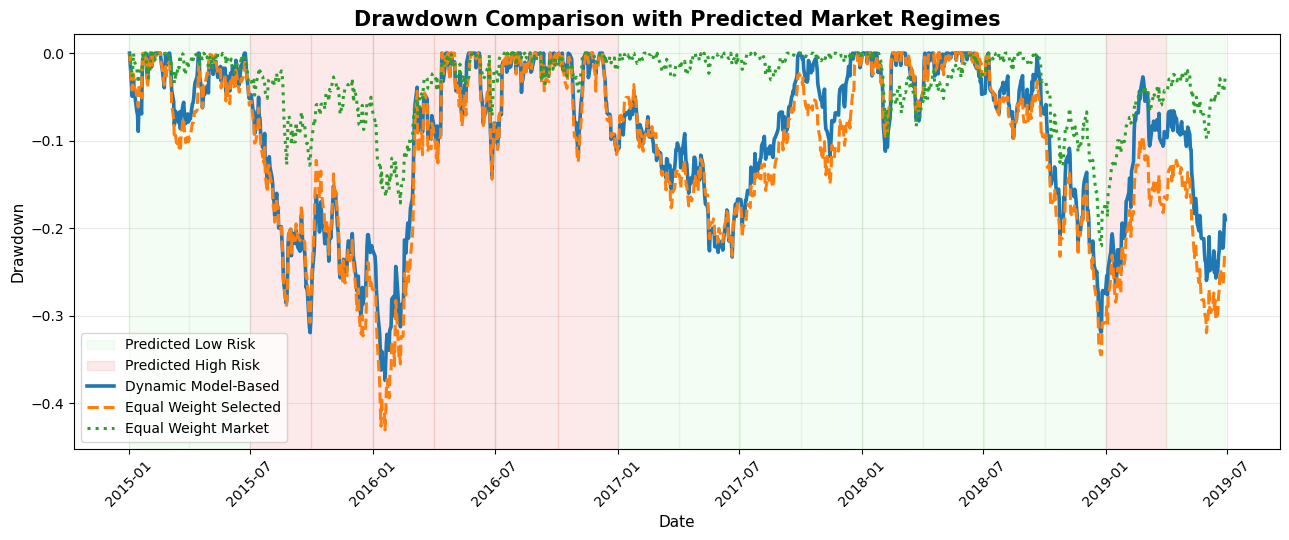

In [1028]:
# ============================================================
# FINAL PLOT — DRAWDOWN WITH REGIME BACKGROUND
# ============================================================

drawdown_df = pd.DataFrame()

for strategy_name in strategy_returns_df.columns:
    drawdown_df[strategy_name] = calculate_drawdown_series(
        strategy_returns_df[strategy_name]
    )

fig, ax = plt.subplots(figsize=(13, 5.5))

add_regime_background(
    ax=ax,
    regime_prediction_df=regime_prediction_df,
    plot_end_date=drawdown_df.index.max()
)

ax.plot(
    drawdown_df.index,
    drawdown_df["Dynamic Model-Based Net"],
    linewidth=2.6,
    label="Dynamic Model-Based"
)

ax.plot(
    drawdown_df.index,
    drawdown_df["Equal Weight Selected Net"],
    linewidth=2.2,
    linestyle="--",
    label="Equal Weight Selected"
)

ax.plot(
    drawdown_df.index,
    drawdown_df["Equal Weight Market Net"],
    linewidth=2.2,
    linestyle=":",
    label="Equal Weight Market"
)

ax.set_title(
    "Drawdown Comparison with Predicted Market Regimes",
    fontsize=15,
    weight="bold",
    color="black"
)

ax.set_xlabel("Date", fontsize=11, color="black")
ax.set_ylabel("Drawdown", fontsize=11, color="black")

ax.grid(True, alpha=0.25)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, color="black")
plt.yticks(color="black")

handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), frameon=True)

plt.tight_layout()
plt.show()

Sharpe ratio plot ???

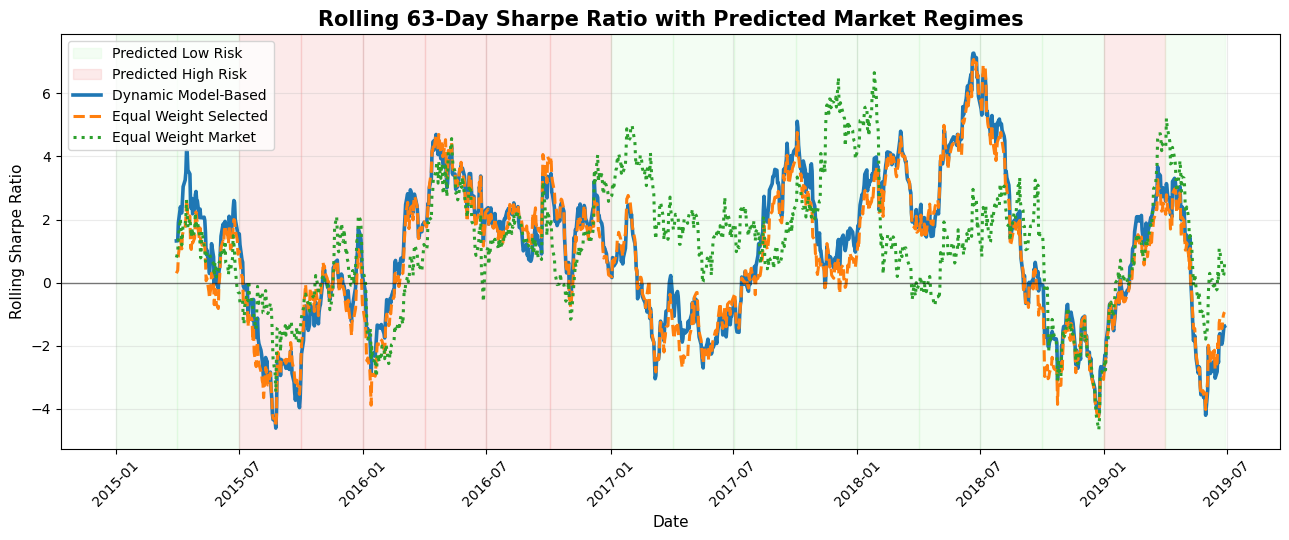

In [1041]:
# ============================================================
# FINAL PLOT — ROLLING SHARPE RATIO WITH REGIME BACKGROUND
# ============================================================

rolling_window = 63

rolling_sharpe_df = pd.DataFrame()

for strategy_name in strategy_returns_df.columns:
    rolling_mean = strategy_returns_df[strategy_name].rolling(rolling_window).mean()
    rolling_vol = strategy_returns_df[strategy_name].rolling(rolling_window).std()

    rolling_sharpe_df[strategy_name] = (
        rolling_mean / rolling_vol * np.sqrt(TRADING_DAYS)
    )

fig, ax = plt.subplots(figsize=(13, 5.5))

add_regime_background(
    ax=ax,
    regime_prediction_df=regime_prediction_df,
    plot_end_date=rolling_sharpe_df.index.max()
)

ax.plot(
    rolling_sharpe_df.index,
    rolling_sharpe_df["Dynamic Model-Based Net"],
    linewidth=2.6,
    label="Dynamic Model-Based"
)

ax.plot(
    rolling_sharpe_df.index,
    rolling_sharpe_df["Equal Weight Selected Net"],
    linewidth=2.2,
    linestyle="--",
    label="Equal Weight Selected"
)

ax.plot(
    rolling_sharpe_df.index,
    rolling_sharpe_df["Equal Weight Market Net"],
    linewidth=2.2,
    linestyle=":",
    label="Equal Weight Market"
)

ax.axhline(0, linewidth=1, color="black", alpha=0.5)

ax.set_title(
    "Rolling 63-Day Sharpe Ratio with Predicted Market Regimes",
    fontsize=15,
    weight="bold",
    color="black"
)

ax.set_xlabel("Date", fontsize=11, color="black")
ax.set_ylabel("Rolling Sharpe Ratio", fontsize=11, color="black")

ax.grid(True, alpha=0.25)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, color="black")
plt.yticks(color="black")

handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), frameon=True)

plt.tight_layout()
plt.show()

#### 12.6 High-risk probability plot

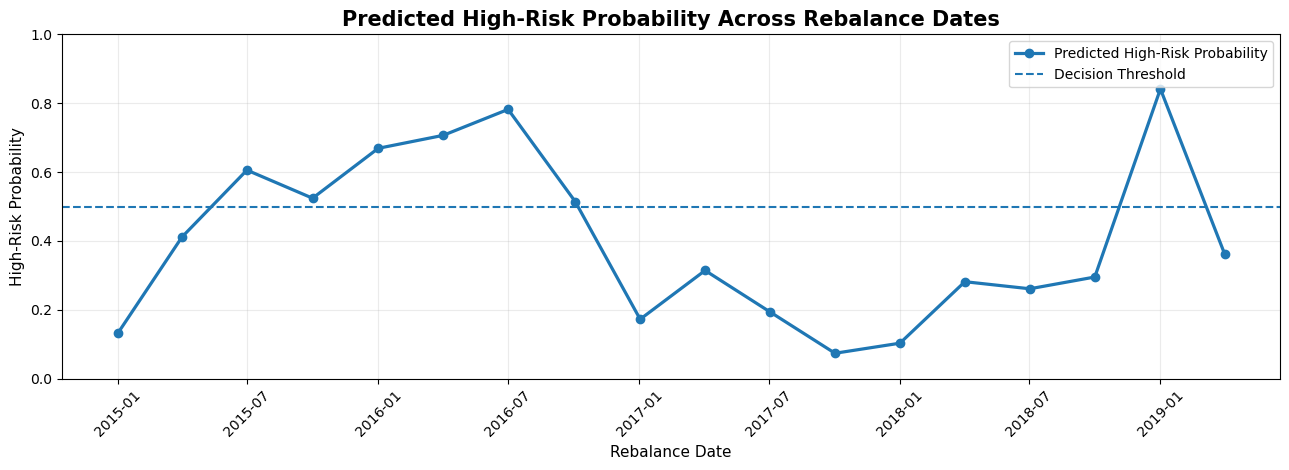

In [ ]:
# ============================================================
# FINAL PLOT — HIGH-RISK PROBABILITY
# ============================================================

plt.figure(figsize=(13, 4.8))

plt.plot(
    regime_prediction_df["Rebalance_Date"],
    regime_prediction_df["High_Risk_Probability"],
    marker="o",
    linewidth=2.3,
    label="Predicted High-Risk Probability"
)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    label="Decision Threshold"
)

plt.title(
    "Predicted High-Risk Probability Across Rebalance Dates",
    fontsize=15,
    weight="bold",
    color="black"
)

plt.xlabel("Rebalance Date", fontsize=11, color="black")
plt.ylabel("High-Risk Probability", fontsize=11, color="black")

plt.ylim(0, 1)
plt.legend(frameon=True)
plt.grid(True, alpha=0.25)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, color="black")
plt.yticks(color="black")

plt.tight_layout()
plt.show()

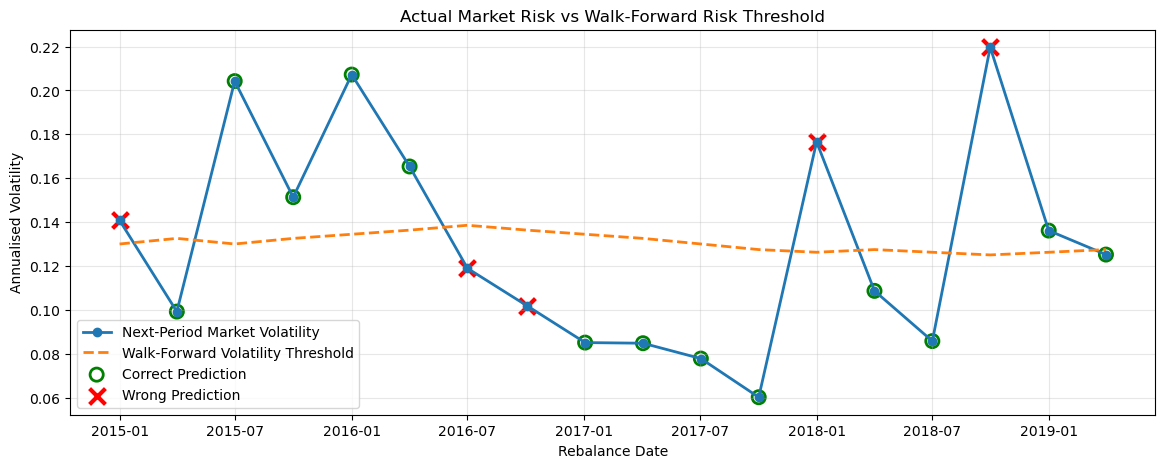

In [1037]:
# ============================================================
# ACTUAL NEXT-PERIOD VOLATILITY VS WALK-FORWARD THRESHOLD
# ============================================================

plot_regime_pred = regime_prediction_df.dropna(
    subset=[
        "Next_Period_Market_Vol",
        "Vol_Threshold",
        "Predicted_Label",
        "Actual_Label"
    ]
).copy()

plot_regime_pred["Rebalance_Date"] = pd.to_datetime(plot_regime_pred["Rebalance_Date"])

plot_regime_pred["Prediction_Correct"] = (
    plot_regime_pred["Predicted_Label"] == plot_regime_pred["Actual_Label"]
)

correct_df = plot_regime_pred[plot_regime_pred["Prediction_Correct"]]
wrong_df = plot_regime_pred[~plot_regime_pred["Prediction_Correct"]]

plt.figure(figsize=(14, 5))

plt.plot(
    plot_regime_pred["Rebalance_Date"],
    plot_regime_pred["Next_Period_Market_Vol"],
    marker="o",
    linewidth=2,
    label="Next-Period Market Volatility"
)

plt.plot(
    plot_regime_pred["Rebalance_Date"],
    plot_regime_pred["Vol_Threshold"],
    linestyle="--",
    linewidth=2,
    label="Walk-Forward Volatility Threshold"
)

plt.scatter(
    correct_df["Rebalance_Date"],
    correct_df["Next_Period_Market_Vol"],
    s=90,
    marker="o",
    facecolors="none",
    edgecolors="green",
    linewidths=2,
    label="Correct Prediction"
)

plt.scatter(
    wrong_df["Rebalance_Date"],
    wrong_df["Next_Period_Market_Vol"],
    s=130,
    marker="x",
    color="red",
    linewidths=3,
    label="Wrong Prediction"
)

plt.xlabel("Rebalance Date")
plt.ylabel("Annualised Volatility")
plt.title("Actual Market Risk vs Walk-Forward Risk Threshold")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

#### 12.7 Portfolio weights heatmap

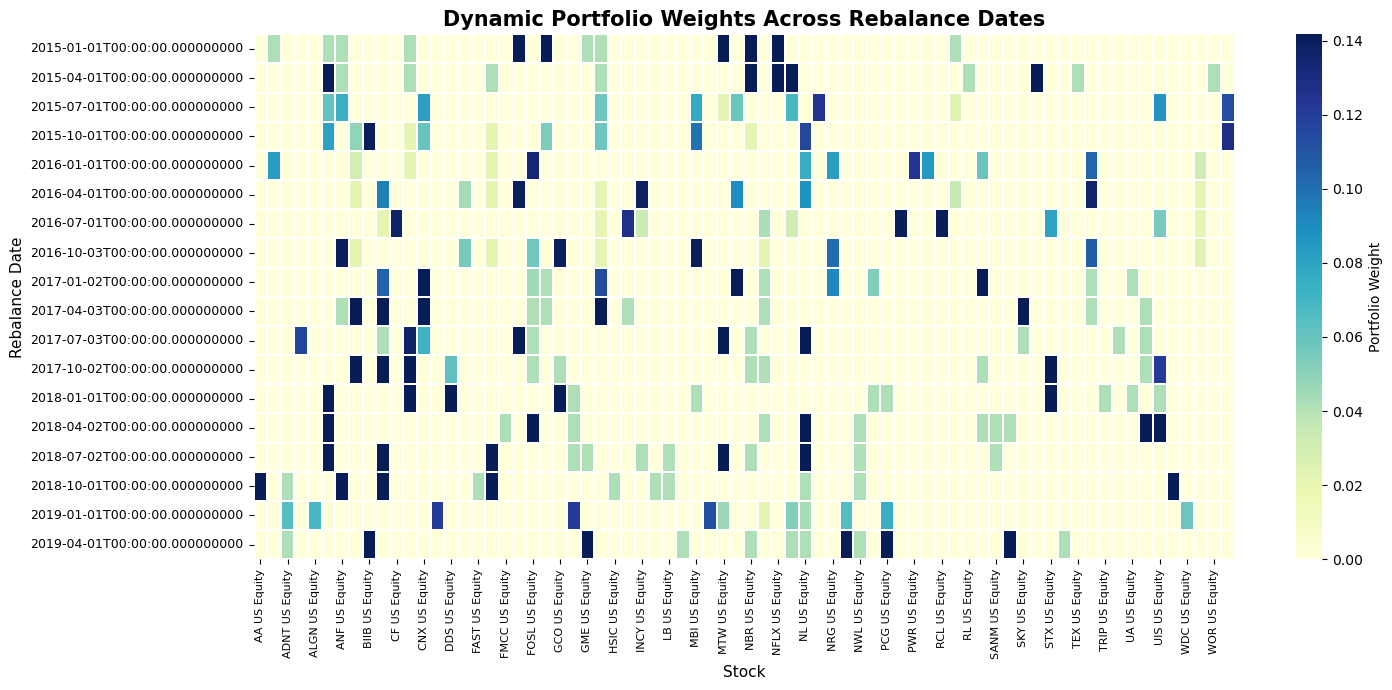

In [ ]:
# ============================================================
# FINAL PLOT — DYNAMIC PORTFOLIO WEIGHTS HEATMAP
# ============================================================

weight_matrix = dynamic_weights.pivot(
    index="Rebalance_Date",
    columns="Stock",
    values="Weight"
).fillna(0)

# Optional: only show stocks that ever received meaningful weight
active_stock_cols = weight_matrix.columns[
    (weight_matrix > 0.01).any(axis=0)
]

weight_matrix_active = weight_matrix[active_stock_cols]

plt.figure(figsize=(15, 7))

sns.heatmap(
    weight_matrix_active,
    cmap="YlGnBu",
    linewidths=0.25,
    linecolor="white",
    cbar_kws={"label": "Portfolio Weight"}
)

plt.title(
    "Dynamic Portfolio Weights Across Rebalance Dates",
    fontsize=15,
    weight="bold",
    color="black"
)

plt.xlabel("Stock", fontsize=11, color="black")
plt.ylabel("Rebalance Date", fontsize=11, color="black")

plt.xticks(rotation=90, fontsize=8, color="black")
plt.yticks(rotation=0, fontsize=9, color="black")

plt.tight_layout()
plt.show()

Figure X. Portfolio weight heatmap showing how the dynamic strategy reallocates capital across selected stocks over time.

#### 12.8 Turnover comparison summary

In [ ]:
# ============================================================
# FINAL TURNOVER SUMMARY
# ============================================================

dynamic_turnover_clean = turnover_log.copy()
dynamic_turnover_clean["Strategy"] = "Dynamic Model-Based"

ew_selected_turnover_clean = ew_selected_turnover_log.copy()
ew_selected_turnover_clean["Strategy"] = "Equal Weight Selected"

ew_market_turnover_clean = ew_market_turnover_log.copy()
ew_market_turnover_clean["Strategy"] = "Equal Weight Market"

turnover_comparison = pd.concat([
    dynamic_turnover_clean,
    ew_selected_turnover_clean,
    ew_market_turnover_clean
], ignore_index=True)

if "Benchmark" in turnover_comparison.columns:
    turnover_comparison = turnover_comparison.drop(columns=["Benchmark"])

turnover_summary = (
    turnover_comparison
    .groupby("Strategy")
    .agg(
        Average_Turnover=("Turnover", "mean"),
        Median_Turnover=("Turnover", "median"),
        Max_Turnover=("Turnover", "max"),
        Total_Transaction_Cost=("Transaction_Cost", "sum")
    )
    .reset_index()
)

turnover_summary_display = turnover_summary.copy()

for col in [
    "Average_Turnover",
    "Median_Turnover",
    "Max_Turnover",
    "Total_Transaction_Cost"
]:
    turnover_summary_display[col] = (
        turnover_summary_display[col] * 100
    ).round(2)

display(turnover_summary_display)

,Strategy,Average_Turnover,Median_Turnover,Max_Turnover,Total_Transaction_Cost
0,Dynamic Model-Based,75.46,77.22,100.0,1.36
1,Equal Weight Market,10.02,4.62,100.0,0.18
2,Equal Weight Selected,69.23,66.32,100.0,1.25


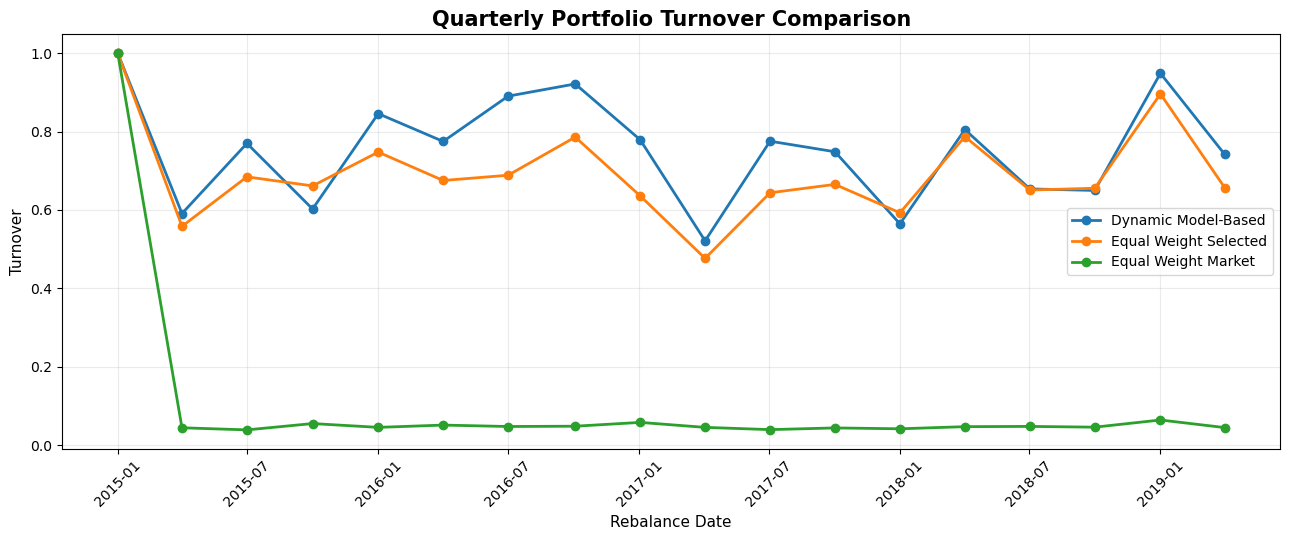

In [ ]:
# ============================================================
# FINAL PLOT — TURNOVER COMPARISON
# ============================================================

plt.figure(figsize=(13, 5.5))

for strategy_name in turnover_comparison["Strategy"].unique():

    plot_data = turnover_comparison[
        turnover_comparison["Strategy"] == strategy_name
    ]

    plt.plot(
        plot_data["Rebalance_Date"],
        plot_data["Turnover"],
        marker="o",
        linewidth=2,
        label=strategy_name
    )

plt.title(
    "Quarterly Portfolio Turnover Comparison",
    fontsize=15,
    weight="bold",
    color="black"
)

plt.xlabel("Rebalance Date", fontsize=11, color="black")
plt.ylabel("Turnover", fontsize=11, color="black")

plt.legend(frameon=True)
plt.grid(True, alpha=0.25)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, color="black")
plt.yticks(color="black")

plt.tight_layout()
plt.show()

#### 12.9 Final decision log

In [ ]:
# ============================================================
# FINAL STRATEGY DECISION LOG
# ============================================================

final_decision_log = backtest_log.merge(
    turnover_log[[
        "Rebalance_Date",
        "Turnover",
        "Transaction_Cost"
    ]],
    on="Rebalance_Date",
    how="left"
)

final_decision_log_display = final_decision_log.copy()

for col in [
    "High_Risk_Probability",
    "Gross_Period_Return",
    "Net_Period_Return",
    "Turnover",
    "Transaction_Cost"
]:
    final_decision_log_display[col] = final_decision_log_display[col].round(4)

display(final_decision_log_display)

,Rebalance_Date,Holding_Start_Date,Holding_End_Date,Predicted_Regime,High_Risk_Probability,Model_Name,Weighting_Method,Number_of_Stocks,Gross_Period_Return,Net_Period_Return,Turnover,Transaction_Cost
0,2015-01-01,2015-01-02,2015-03-31,Low_Risk,0.1317,logistic_regression,Blended Equal Weight + Robust Max Sharpe,12,0.0864,0.0853,1.0000,0.0010
1,2015-04-01,2015-04-02,2015-06-30,Low_Risk,0.4114,logistic_regression,Blended Equal Weight + Robust Max Sharpe,12,0.0762,0.0755,0.5907,0.0006
2,2015-07-01,2015-07-02,2015-09-30,High_Risk,0.6057,logistic_regression,Blended EW + MinVar with 85% Equity Exposure,12,-0.2671,-0.2677,0.7698,0.0008
3,2015-10-01,2015-10-02,2015-12-31,High_Risk,0.5242,logistic_regression,Blended EW + MinVar with 85% Equity Exposure,12,0.1186,0.1179,0.6024,0.0006
4,2016-01-01,2016-01-04,2016-03-31,High_Risk,0.6690,logistic_regression,Blended EW + MinVar with 85% Equity Exposure,12,0.1881,0.1871,0.8457,0.0008
5,2016-04-01,2016-04-04,2016-06-30,High_Risk,0.7067,logistic_regression,Blended EW + MinVar with 85% Equity Exposure,12,0.1991,0.1982,0.7747,0.0008
6,2016-07-01,2016-07-04,2016-09-30,High_Risk,0.7821,logistic_regression,Blended EW + MinVar with 85% Equity Exposure,12,0.1791,0.1780,0.8903,0.0009
7,2016-10-03,2016-10-04,2016-12-30,High_Risk,0.5144,logistic_regression,Blended EW + MinVar with 85% Equity Exposure,12,0.0137,0.0127,0.9215,0.0009
8,2017-01-02,2017-01-03,2017-03-31,Low_Risk,0.1727,logistic_regression,Blended Equal Weight + Robust Max Sharpe,12,0.0111,0.0103,0.7791,0.0008
9,2017-04-03,2017-04-04,2017-06-30,Low_Risk,0.3144,logistic_regression,Blended Equal Weight + Robust Max Sharpe,12,-0.0708,-0.0713,0.5211,0.0005


#### 12.10 Short result interpretation template

In [ ]:
# ============================================================
# TEXT SUMMARY FOR REPORT
# ============================================================

best_strategy = performance_summary.sort_values(
    "Sharpe_Ratio",
    ascending=False
).iloc[0]["Strategy"]

print("Best strategy by Sharpe Ratio:", best_strategy)

display(performance_summary_display)

Best strategy by Sharpe Ratio: Dynamic Model-Based Net


,Strategy,Cumulative_Return,Annualised_Return,Annualised_Volatility,Sharpe_Ratio,Max_Drawdown,Calmar_Ratio
0,Dynamic Model-Based Net,171.86,24.41,28.45,0.858,-37.36,0.653
1,Equal Weight Selected Net,110.81,17.69,29.64,0.597,-43.03,0.411
2,Equal Weight Market Net,56.21,10.23,13.84,0.739,-22.01,0.465


The final performance comparison shows that the dynamic model-based strategy generated positive returns over the out-of-sample period, but its effectiveness should be assessed relative to the equal-weight benchmarks. The equal-weight selected-stock benchmark isolates the value of the weighting model, while the equal-weight market benchmark represents a broader investable universe. The drawdown and turnover results provide additional evidence on downside risk and trading intensity.